In [1]:
import numpy as np
import matplotlib as mpl
#mpl.use('TkAgg')
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.colors import PowerNorm
from matplotlib.patches import Rectangle
from matplotlib.ticker import FormatStrFormatter
from skimage.draw import disk
from scipy.optimize import curve_fit
from scipy import signal
from scipy.fft import fft, fftshift
#from lmfit import Parameters, minimize, report_fit
from obspy.imaging.cm import viridis_white
import cmocean
import xarray as xr
from math import nan
import multiprocessing
import matplotlib.patheffects as pe
from sigfig import round
import csv

import sys, os
#sys.path.append(os.path.abspath("R:\Lawson\mpes-analysis"))  # or full path to project

from Loader import DataLoader
import main
# Original: from Main import main, but that didn't run because there was no module called "Main"
import PyQt5

from Manager import DataHandler, FigureHandler, PlotHandler, ValueHandler, SliderManager, EventHandler, CheckButtonManager, ClickButtonManager
import mpes
from mpes import cmap_LTL, cmap_LTL2
%load_ext autoreload
%autoreload 2

cmap_plot = 'viridis'

In [2]:
# Specify datapath, filename, and [Energy, Delay] offsets to load
data_path = r'/home/orion-eleanor-giehl/ARPES Data'

# Lists for Filenames, Offsets, Labels,and Measurement Times
Filenames = []
Offsets = [] #Offsets are [Energy, Time]
Labels = []
MeasurementTimes = []

def DeclareFile(filename, offset, label, time, include):
    if include:
        Filenames.append(filename)
        Offsets.append(offset)
        Labels.append(label)
        MeasurementTimes.append(time)

# NiI2 Temperature Scans with Static Delay
DeclareFile('Scan1076_24K_binned.h5', [0, 0], '24 K', 'Time Unknown', include=False)
DeclareFile('Scan1078_40K_binned.h5', [0, 0], '40 K', 'Time Unknown', include=False)
DeclareFile('Scan1078_40K_3Symmetry_binned.h5', [0, 0], '40 K, Different Momentum Correction', 'Time Unknown', include=False)
DeclareFile('Scan1079_45K_binned.h5', [0, 0], '45 K', 'Time Unknown', include=False)
DeclareFile('Scan1080_50K_binned.h5', [0, 0], '50 K', 'Time Unknown', include=False)
DeclareFile('Scan1081_55K_binned.h5', [0, 0], '55 K', 'Time Unknown', include=False)
DeclareFile('Scan1083_60K_binned.h5', [0, 0], '60 K', 'Time Unknown', include=False)
DeclareFile('Scan1084_65K_binned.h5', [0, 0], '65 K', 'Time Unknown', include=False)
DeclareFile('Scan1085_70K_binned.h5', [0, 0], '70 K', 'Time Unknown', include=False)
DeclareFile('Scan1086_75K_binned.h5', [0, 0], '40 K', 'Time Unknown', include=False)

# NiI2 Time-resolved s-Pol Scan, Room Temperature
DeclareFile('Scan1192_0_binned.h5', [0.208,0], 'Scan1192 (Hours 0-9)', '9 hours', include=False)
DeclareFile('Scan1192_1_binned.h5', [0,.064], 'Scan1192 (Hours 9-18)', '9 hours', include=False)
DeclareFile('Scan1192_2_binned.h5', [0,0], 'Scan1192 (Hours 18-27)', '9 hours', include=False)
DeclareFile('Scan1192_3_binned.h5', [0.208, 49], 'Scan1192 (Hours 27-36)', '9 hours', include=False)
DeclareFile('Scan1192_4_binned.h5', [0,0], 'Scan1192 (Hours 36-45)', '9 hours', include=False)
DeclareFile('Scan1192_5_binned.h5', [0,0], 'Scan1192 (Hours 45-54)', '9 hours', include=False)
DeclareFile('Scan1192_6_binned.h5', [0.208,0], 'Scan1192 (Hours 54-63)', '9 hours', include=False)
DeclareFile('Scan1192_7_binned.h5', [0,0], 'Scan1192 (Hours 63-72)', '9 hours', include=False)
DeclareFile('Scan1192_binned_full.h5', [0.208, 49], 'Scan1192, s-Pol Pump', '72 hours', include=False)
# Same Scan binned to have C-State in Focus
DeclareFile('Scan1192_NoMomentumCorrection.h5', [0.208, 49], 'Scan1192, s-Pol Pump', '72 hours', include=False)
# NiI2 Static Room Temp Scan, Pump blocked, p_pol Probe, Immediately after Scan1192
DeclareFile('Scan1194_binned.h5', [-0.135,0], 'Scan1194, Pump blocked after s-Pol', '0.2 hours', include=False)

# NiI2 Time-resolved s-Pol Scan, different sample from 1192, Room Temperature
DeclareFile('Scan1109_binned_0.h5', [-.043, 100], 'Scan1109 (Hours 0-9.8)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_1.h5', [-.043, 100], 'Scan1109 (Hours 9.8-19.6)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_2.h5', [-.043, 100], 'Scan1109 (Hours 19.6-29.4)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_3.h5', [-.043, 100], 'Scan1109 (Hours 29.4-39.2)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_4.h5', [-.043, 100], 'Scan1109 (Hours 39.2-49)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_5.h5', [-.043, 100], 'Scan1109 (Hours 48-58.8)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_6.h5', [-.043, 100], 'Scan1109 (Hours 58.8-68.6)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_7.h5', [-.043, 100], 'Scan1109 (Hours 68.6-78.4)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_8.h5', [-.043, 100], 'Scan1109 (Hours 78.4-88.2)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned_9.h5', [-.043, 100], 'Scan1109 (Hours 88.2-98)', '9.8 hours', include=False)
DeclareFile('Scan1109_binned.h5', [-.043, 100], 'Scan1109, s-Pol Pump', '98 hours', include=False)
# Same Scan binned for excited state
DeclareFile('Scan1109_binned_NoMomentumCorrection.h5', [-.043, 100], 'Scan1109, s-Pol Pump', '98 hours', include=False)
# Scan 1109 binned to 6.5 eV showing HHG apparitions
DeclareFile('Scan1109_binned_UpTo6p5eV.h5', [-.043, 100], 'Scan1109, s-Pol Pump', '98 hours', include=False)

# New Pump Energy, 1.45 eV
DeclareFile('Scan2693_binned_30files.h5', [0.55,0], 'Scan2693, 1.4 eV Pump', '0.83 hours', include=False)
# 1.45 eV with p-Polarized Pump
DeclareFile('Scan2703_binned.h5', [0.31,0], 'Scan2703, p-Pol Pump at 1.45 eV', '64 hours', include=False)
# 1.45 eV with s-Polarized Pump
DeclareFile('Scan2704_binned.h5', [0.265,0], 'Scan2704, s-Pol Pump at 1.45 eV', '45 hours', include=True)

# New Pump Energy, 1.55 eV
DeclareFile('Scan2705_binned.h5', [0.282,-2000], 'Scan2705, p-Pol Pump at 1.55 eV', '15 hours', include=False)
DeclareFile('Scan2707_binned.h5', [0.255,-2000], 'Scan2707, s-Pol Pump at 1.55 eV', '43 hours', include=True)

# NiI2 Static Room Temp Scan, p-Pol Pump, p-Pol Probe, Stattic Delay of -500fs
DeclareFile('Scan1093_binned.h5', [-0.004, 0], fr'Scan1093, $\Delta t=-0.5$ ps, p-Pol Pump', '0.68 hours', include=False)
# NiI2 Time-resolved p-Pol Scan, Room Temperature
DeclareFile('Scan1095_pPol_binned_fixed.h5', [0.082, -143], 'Scan1095, p-Pol Pump', '22 hours', include=False)
# Same scan with different Momentum Correction, also binned to fs instead of ps
DeclareFile('Scan1095_binned_NoMomentumCorrection.h5', [0.0487, -143], 'Scan1095, p-Pol Pump', '22 hours', include=True)
DeclareFile('Scan1095_binned_NoMomentumCorrection.h5', [0, 0], 'Scan1095, p-Pol Pump', '22 hours', include=False)

# NiI2 Time-resolved Scan with really bad charging
DeclareFile('Scan1226_binned_attempt1.h5', [0,0], 'Low Temperature, Bad Charging', 'Time Unknown', include=False)

# NiI2 Static Scans at Room Temperature with different set delays
DeclareFile('Scan1205_50fs_binned.h5', [.136, 0], r'$\Delta t$ = 50 fs', '1.64 hours', include=False)
DeclareFile('Scan1207_60fs_binned.h5', [.118, 0], r'Scan1207, $\Delta t$ = 60 fs, s-Pol Pump', '22.54 hours', include=False)
DeclareFile('Scan1206_75fs_binned.h5', [.218, 0], r'$\Delta t$ = 75 fs', '16.97 hours', include=False)
DeclareFile('Scan1209_200fs_binned.h5', [.101, 0], r'$\Delta t$ = 200 fs', '3.70 hours', include=False)
DeclareFile('Scan1208_NoPump_binnedTo5eV.h5', [.124, 0], 'Scan1208, Pump blocked after s-Pol', '2.80 hours', include=False)

DeclareFile('Scan1192_binned_full.h5', [0.208, 50.1], 'Scan1192', '72 hours', include=False)
DeclareFile('Scan1095_pPol_binned_fixed.h5', [0.082, -142.7], 'Scan1095', '22 hours', include=False)
#DeclareFile('Scan1192_binned_full.h5', [0.208, 0.049], 'Scan1192', '72 hours', include=False)
#DeclareFile('Scan1095_pPol_binned_fixed.h5', [.082, -0.143], 'Scan1095', '22 hours', include=False)



# 1.9 eV p-Pol Pump at 30 K. Delay 0 to 3000 fs with t0 expectedd around 900 fs
DeclareFile('Scan2709_binned.h5', [0.038,900], 'Scan2709, p-Pol Pump at 1.9 eV, 30 K', '2 hours', include=False)

# WSe2 time-resolved Scan at 300 K
DeclareFile('WSe2_300K_Seawoo.h5', [0,0], 'WSe2 300 K', '? hours', include=True)

# Load the Data
data_loader = [DataLoader(data_path + '//' + Filenames[i], offsets = Offsets[i]) for i in range(len(Filenames))]

I_list = [data_loader[i].load() for i in range(len(data_loader))]

The data shape is: (200, 200, 250, 65)
"/home/orion-eleanor-giehl/ARPES Data//Scan2704_binned.h5" has been loaded! Happy Analysis...
The data shape is: (200, 200, 250, 67)
"/home/orion-eleanor-giehl/ARPES Data//Scan2707_binned.h5" has been loaded! Happy Analysis...
The data shape is: (200, 200, 250, 60)
"/home/orion-eleanor-giehl/ARPES Data//Scan1095_binned_NoMomentumCorrection.h5" has been loaded! Happy Analysis...
The data shape is: (150, 150, 200, 75)
"/home/orion-eleanor-giehl/ARPES Data//WSe2_300K_Seawoo.h5" has been loaded! Happy Analysis...


In [3]:
# Create two empty lists to which the normalized and difference spectra will be written
I_res = []
I_diff = []

# Append a bunch of empty strings so that I_res and I_diff are the same length as I_list
for i in range(len(I_list)):
    I_res.append('')
    I_diff.append('')

# Write normalized and difference spectra into I_res and I_diff
for i in range(len(I_list)):
    if 'delay' in I_list[i].dims:
        I_res[i] = I_list[i][:, :, :, 1:-1]
        I_res[i] = I_res[i]/np.max(I_res[i])
        I_diff[i] = I_res[i] - I_res[i].loc[{'delay':slice(-250,-100)}].mean(dim='delay')
        I_diff[i] = I_diff[i]/np.max(I_diff[i])
        print('Delay')
    else:
        I_res[i] = I_list[i]/np.max(I_list[i])
        print('No Delay')

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

Delay
Delay
Delay
Delay


In [4]:
# sin(60deg) = sqrt(3)/2 ; cos(60deg) = 1/2
K_dist = 4*np.pi/(3*3.95)
vec_K1 = np.array([K_dist, 0])
vec_K2 = np.array([1/2, np.sqrt(3)/2]) * K_dist
vec_K3 = np.array([-1/2, np.sqrt(3)/2]) * K_dist
vec_K4 = np.array([-K_dist, 0])
vec_K5 = np.array([-1/2, -np.sqrt(3)/2]) * K_dist
vec_K6 = np.array([1/2, -np.sqrt(3)/2]) * K_dist

# sin(30deg) = 1/2 ; cos(30deg) = sqrt(3)/2
M_dist = 2*np.pi/(np.sqrt(3)*3.95)
vec_M = np.array([np.pi/(3.95), -np.pi/(np.sqrt(3)*3.95)])
vec_M1 = np.array([np.sqrt(3)/2, 1/2]) * M_dist
vec_M2 = np.array([0, M_dist])
vec_M3 = np.array([-np.sqrt(3)/2, 1/2]) * M_dist
vec_M4 = np.array([-np.sqrt(3)/2, -1/2]) * M_dist
vec_M5 = np.array([0, -M_dist])
vec_M6 = np.array([np.sqrt(3)/2, -1/2]) * M_dist

<unknown>:1055: SyntaxWarning: invalid escape sequence '\m'
<unknown>:1054: SyntaxWarning: invalid escape sequence '\m'


Scan1095, p-Pol Pump     : E_VBM = 0.052(2) eV


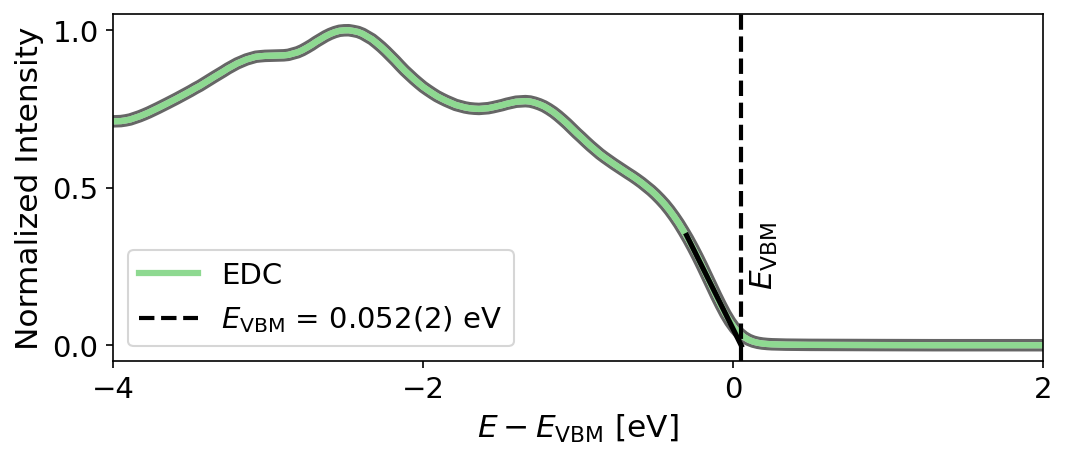

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(8,3)

colormap = mpl.colormaps['viridis']
fontsize=15

mpes.VBMfromRisingEdge([I_res[2].loc[{'E':slice(-4,2)}]], [Labels[2]], fig=fig, ax=ax, E_limits=(-5,2), colors=[colormap(0.75)], fit_limits=(-0.3,0.5), show_fit_lims=False)
ax.annotate(fr'$E_{{\mathrm{{VBM}}}}$', (0.1, 0.2), fontsize=fontsize, rotation=90)

ax.set_xlim(-4,2)
ax.set_yticks([0, 0.5, 1])
ax.set_xticks([-4, -2, 0, 2])

# Dummy plots for legend
dummy_line, = ax.plot(-10, 0, color=colormap(0.75), lw=3, alpha=0.7, label='EDC')
dummy_out = ax.axvline(-10, color='black', label=fr'$E_{{\mathrm{{VBM}}}}$ = 0.052(2) eV', ls='dashed', lw=2)
ax.legend(fontsize=fontsize-1, handles=[dummy_line, dummy_out])
#fig.savefig('./Figures/Thesis/Find_E_VBM.pdf', bbox_inches='tight')

Scan1095, p-Pol Pump     : t0 = -144.2(1.3) fs


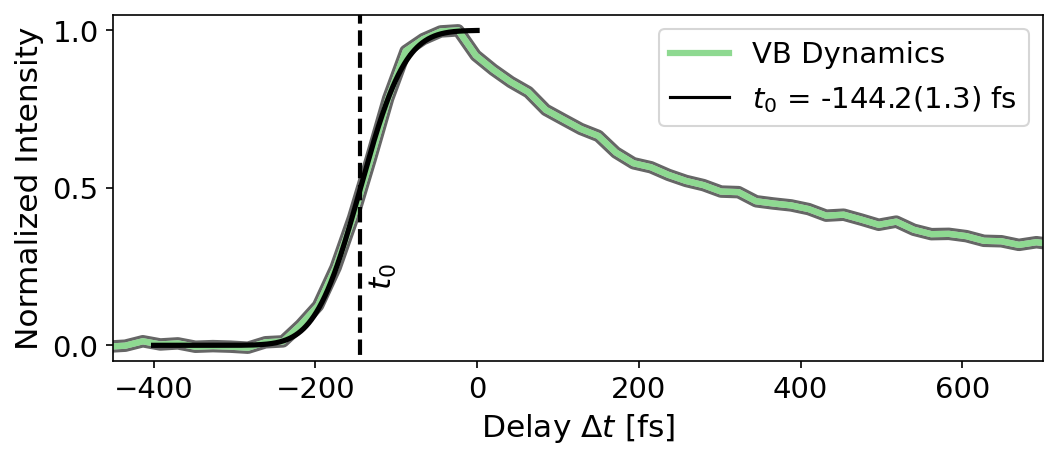

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(8,3)

fontsize = 15
colormap = mpl.colormaps['viridis']
# Energy integration goes from 0 to 0.2 eV, but this was run on a file where E_VBM wasn't applied as an offset yet so the numbers are 0.05 to 0.25 eV
mpes.t0_alt([I_res[2]], [Labels[2]], fig=fig, ax=ax, neg_delays=[(-400,-250)], xlims=(-450, 700), E_limits=(0.05, 0.25), delay_limits=[(-400,0)], colors=[colormap(0.75)])
ax.annotate(fr'$t_{0}$', (-135, 0.2), fontsize=fontsize, rotation=90)

# Dummy plots for legend
dummy_line, = ax.plot(-1000, 0, color=colormap(0.75), lw=3, alpha=0.7, label='VB Dynamics')
dummy_out = ax.axvline(-1000, color='black', label=fr'$t_{{0}}$ = -144.2(1.3) fs')
ax.legend(fontsize=fontsize-1, handles=[dummy_line, dummy_out])
ax.set_yticks([0, 0.5, 1])
#fig.savefig('./Figures/Thesis/Find_t0.pdf', bbox_inches='tight')

Renormalization Factor : 11259
E_1 = 0.672(4) eV, FWHM = 0.671(12) eV
E_2 = 1.583(5) eV, FWHM = 0.411(11) eV


Text(80.70833333333333, 0.5, '$E-E_{\\mathrm{VBM}}$ [eV]')

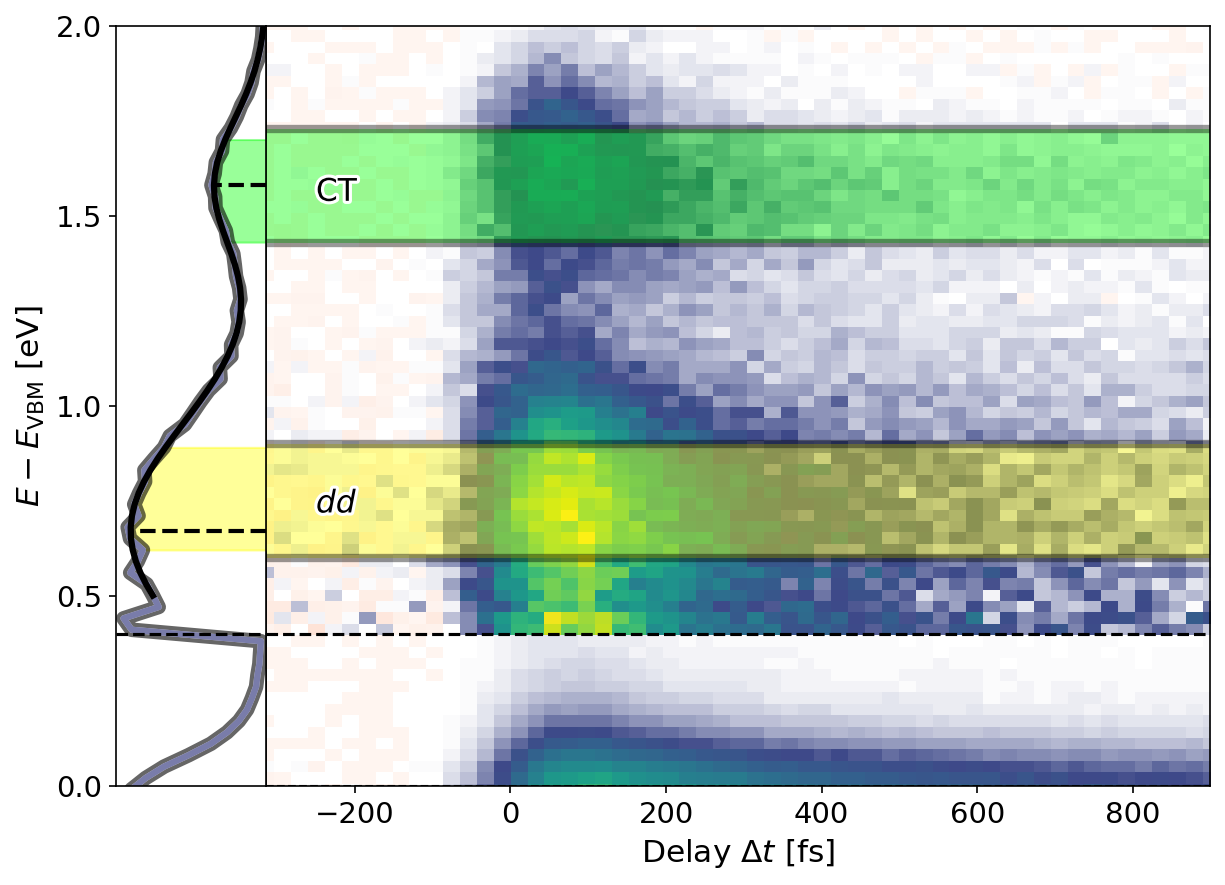

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots()
fig.set_size_inches(8,6)
colormap = mpl.colormaps['viridis']

# Add Axes Object for EDC on the left
divider = make_axes_locatable(ax)
ax_EDC = divider.append_axes('left', 1, pad=0, sharey=ax)

I_index = 2
fontsize = 15
neg_delays = [(-250, -100), (-250, -100), (-250, -100)]
mpes.plot_waterfall(I_res[I_index], kx=0, kx_int=4, ky=0, ky_int=4, fig=fig, ax=ax, E_enhance=0.4, energy_limits=(0,2), subtract_neg=True,
                    neg_delays=neg_delays[I_index], fontsize=fontsize)

mpes.add_rect(0, 2000, 1.58, 0.3, ax=ax, facecolor='lime', edgecolor='black', alpha=0.4, linewidth=4)
ax.text(x=-250, y=1.54, s=fr'CT', color='black',
        path_effects=[pe.Stroke(linewidth=3, foreground='white', alpha=1), pe.Normal()], size=15)
mpes.add_rect(0, 2000, 0.75, 0.3, ax=ax, facecolor='yellow', edgecolor='black', alpha=0.4, linewidth=4)
ax.text(x=-250, y=0.72, s=fr'$dd$', color='black',
        path_effects=[pe.Stroke(linewidth=3, foreground='white', alpha=1), pe.Normal()], size=15)

ax.tick_params(labelleft=False, left=False)

edc = mpes.get_edc(I_diff[2].loc[{'E':slice(-1,2.5)}], kx=0, ky=0, kx_int=4, ky_int=4, delay=0, delay_int=2000)
edc_lo = edc.loc[{'E':slice(-0.25,0.4)}]
edc_lo = edc_lo / np.max(edc_lo)
edc_hi = edc.loc[{'E':slice(0.4,2.5)}]
edc_hi = edc_hi / np.max(edc_hi)

edc_joined = xr.concat([edc_lo, edc_hi], dim='E')

def DoubleGauss(x,x0_a,FWHM_a,A_a,x0_b,FWHM_b,A_b):
    s_a = FWHM_a / 2.355
    s_b = FWHM_b / 2.355
    return A_a * np.exp(-(x-x0_a)**2 / (2 * s_a**2)) + A_b * np.exp(-(x-x0_b)**2 / (2 * s_b**2))

edc_fit = edc_hi.loc[{'E':slice(0.5,2.5)}]

optimal_params, covar_matrix = curve_fit(DoubleGauss, edc_fit.E.values, edc_fit.values, p0=[0.67, 0.6, 1, 1.6, 0.4, 0.5])
uncertainties = np.sqrt(np.diag(covar_matrix))
x0_a_str = round(optimal_params[0], uncertainties[0], cutoff=19, sep='external_brackets')
FWHM_a_str = round(optimal_params[1], uncertainties[1], cutoff=19, sep='external_brackets')
x0_b_str = round(optimal_params[3], uncertainties[3], cutoff=19, sep='external_brackets')
FWHM_b_str = round(optimal_params[4], uncertainties[4], cutoff=19, sep='external_brackets')
print(fr'E_1 = {x0_a_str} eV, FWHM = {FWHM_a_str} eV')
print(fr'E_2 = {x0_b_str} eV, FWHM = {FWHM_b_str} eV')

ax_EDC.plot(edc_joined.values, edc_joined.E.values, lw=3, color=colormap(0.2), alpha=0.7,
            path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=0.6), pe.Stroke(foreground='white', alpha=1), pe.Normal()])
ax_EDC.fill_betweenx(edc_joined.E.values, 0, edc_joined.values, where=((edc_joined.E.values > 1.43) & (edc_joined.E.values < 1.73)), color='lime', alpha=0.4)
ax_EDC.fill_betweenx(edc_joined.E.values, 0, edc_joined.values, where=((edc_joined.E.values > 0.6) & (edc_joined.E.values < 0.9)), color='yellow', alpha=0.4)
ax_EDC.plot(DoubleGauss(edc_fit.E.values, *optimal_params), edc_fit.E.values, color='black', lw=3)
ax_EDC.axhline(0.4, color='black', ls='dashed')
ax_EDC.hlines(optimal_params[0], xmin=0, xmax=optimal_params[2], lw=2, ls='dashed', color='black')
ax_EDC.hlines(optimal_params[3], xmin=0, xmax=optimal_params[5], lw=2, ls='dashed', color='black')
ax_EDC.set_xlim(0,1.05)
ax_EDC.invert_xaxis()
ax_EDC.set_yticks([0, 0.5, 1, 1.5, 2])
ax_EDC.tick_params(axis='both', labelsize=fontsize-1, labelbottom=False, bottom=False)
ax_EDC.set_ylabel(fr'$E-E_{{\mathrm{{VBM}}}}$ [eV]', fontsize = fontsize)

#fig.savefig('./Figures/Thesis/Waterfall.pdf', bbox_inches='tight')

Renormalization Factor : 12384


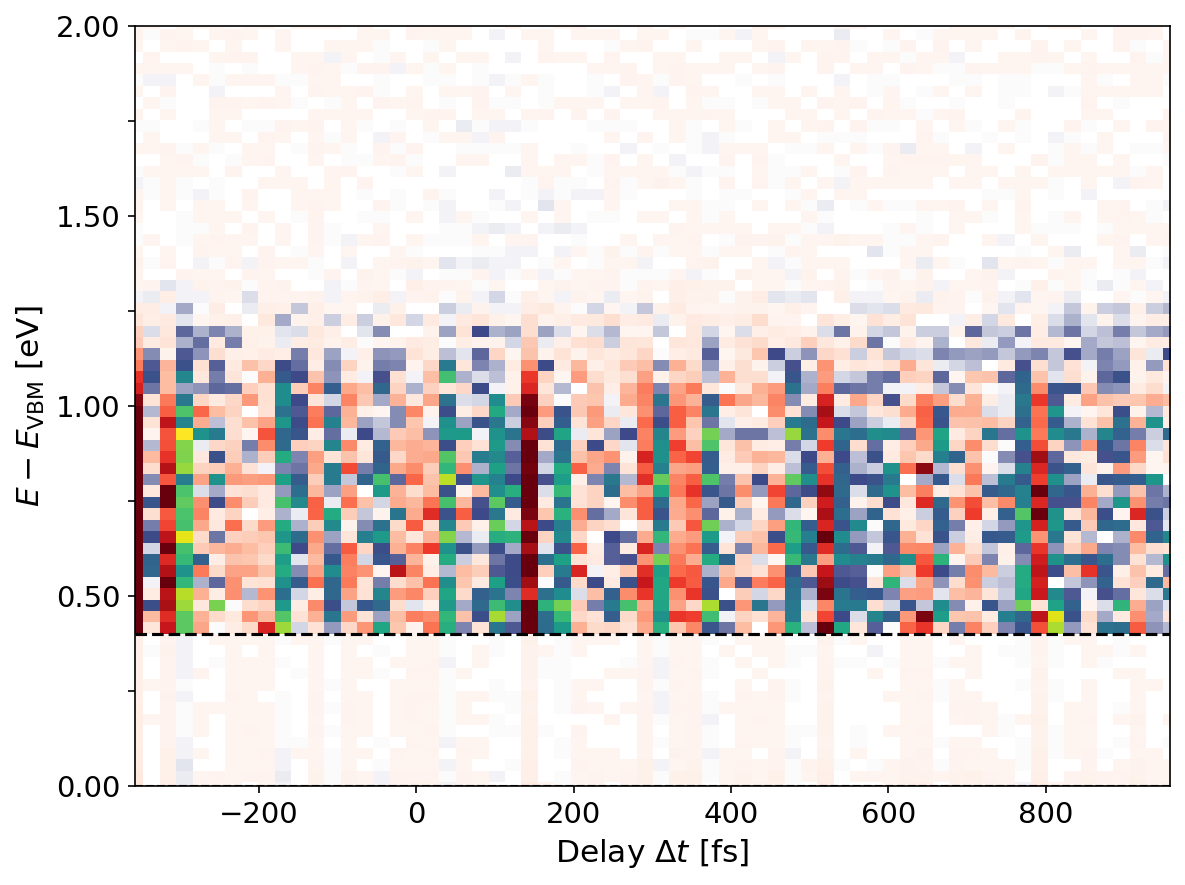

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots()
fig.set_size_inches(8,6)
colormap = mpl.colormaps['viridis']
fontsize = 15

index = 1
mpes.plot_waterfall(I_res[index], kx=0, kx_int=4, ky=0, ky_int=4, fig=fig, ax=ax, E_enhance=0.4, energy_limits=(0,2), subtract_neg=True,
                    neg_delays=(-250, -100), fontsize=fontsize)

Energy = [1.45, 1.55]
#fig.savefig(rf'./Figures/Thesis/Waterfall_{Energy[index]}eV.pdf', bbox_inches='tight')


Fit Results for model: monoexp_const
----------------------------------------
A          =       1.55 ±     0.02 (  1.50 %)
tau_decay1 =     158.15 ±     4.21 (  2.66 %)
c          =       0.09 ±     0.01 (  6.88 %)
----------------------------------------

Fit Results for model: monoexp_const
----------------------------------------
A          =       1.51 ±     0.02 (  1.30 %)
tau_decay1 =     162.54 ±     3.82 (  2.35 %)
c          =       0.12 ±     0.01 (  4.83 %)
----------------------------------------

Fit Results for model: monoexp_const
----------------------------------------
A          =      -2.18 ±     0.54 (-24.86 %)
tau_decay1 =     172.94 ±    81.39 ( 47.06 %)
c          =      -0.36 ±     0.17 (-48.34 %)
----------------------------------------

Fit Results for model: monoexp_const
----------------------------------------
A          =      -1.46 ±     0.50 (-34.38 %)
tau_decay1 =     179.58 ±   120.42 ( 67.05 %)
c          =      -0.55 ±     0.17 (-31.23 %)
---------

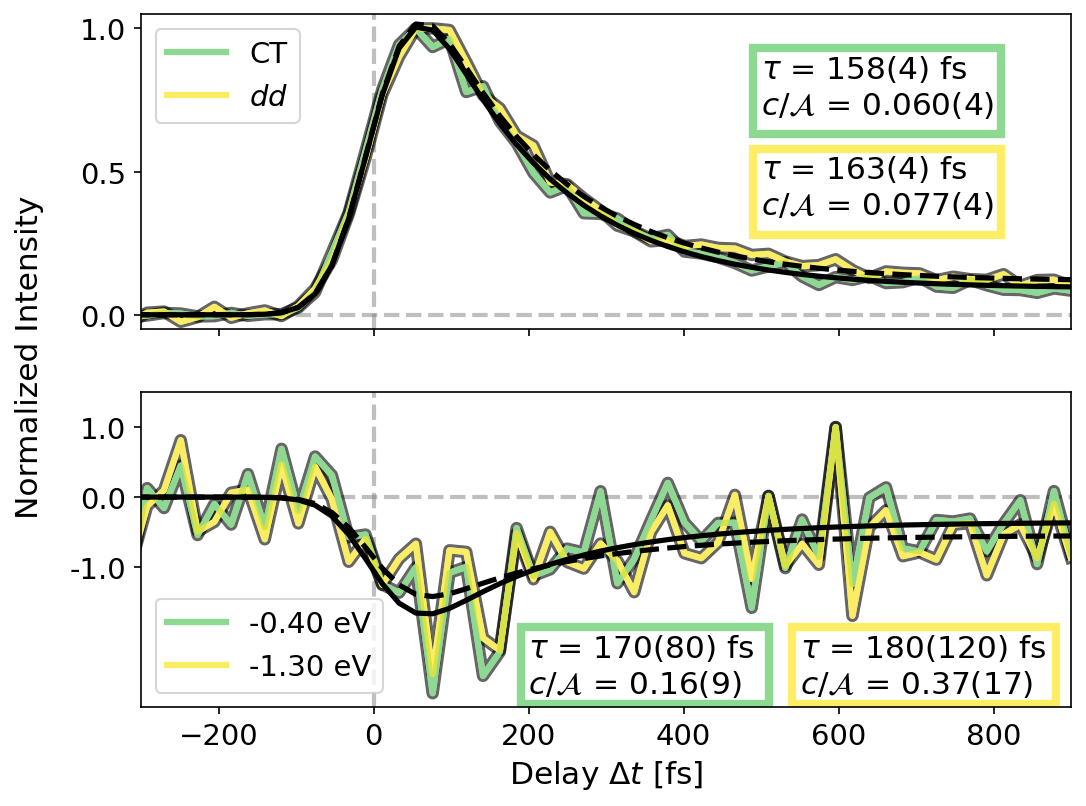

In [ ]:
from uncertainties import ufloat
fig, axs = plt.subplots(2,1, sharex=True)
fig.set_size_inches(8,6)
fontsize = 15

I_index = 2

E_CBM = 1.58
E_dd = 0.75
neg_delays = [(-250, -100), (-250, -100), (-250, -100)]

# Compute & Normalized Time Traces
trace_CBM = mpes.get_time_trace(I_res[I_index], E=E_CBM, E_int=0.3, k=(0,0), k_int=(4,4), subtract_neg=True, neg_delays=neg_delays[I_index])
trace_VBM = mpes.get_time_trace(I_res[I_index], E=-0.4, E_int=0.1, k=(0,0), k_int=(4,4), subtract_neg=True, neg_delays=neg_delays[I_index])
trace_CBM = trace_CBM / np.max(trace_CBM)
trace_VBM = trace_VBM / np.max(trace_VBM)

trace_dd = mpes.get_time_trace(I_res[I_index], E=E_dd, E_int=0.3, k=(0,0), k_int=(4,4), subtract_neg=True, neg_delays=neg_delays[I_index])
trace_m13 = mpes.get_time_trace(I_res[I_index], E=-1.3, E_int=0.1, k=(0,0), k_int=(4,4), subtract_neg=True, neg_delays=neg_delays[I_index])
trace_dd = trace_dd / np.max(trace_dd)
trace_m13 = trace_m13 / np.max(trace_m13)

# Axis Formatting
for ax in axs:
    ax.set_xlim(-300, 900)
    ax.axhline(0, color='grey', linestyle='dashed', alpha=0.5, linewidth=2)
    ax.axvline(0, color='grey', linestyle='dashed', alpha=0.5, linewidth=2)
    ax.tick_params(labelsize=fontsize-1)

# Axis Labels
axs[1].set_xlabel(fr'Delay $\Delta t$ [fs]', fontsize=fontsize)
fig.text(0.02, 0.5, 'Normalized Intensity', va='center', rotation='vertical', fontsize=fontsize)
# Axis Ticks + Limits
axs[0].set_ylim(-0.05, 1.05)
axs[0].set_yticks([0, 0.5, 1])
axs[1].set_ylim(-3, 1.5)
axs[1].set_yticks([-1.0, 0.0, 1.0])
axs[1].set_yticklabels(['-1.0', '0.0', '1.0'])

# Plot curves
colormap = mpl.colormaps['viridis']
colors = colormap(np.linspace(0.75,1,2))
color1 = ['black', 'white', colormap(0.75)]
color2 = ['black', 'white', colormap(0.99)]
alphas = [0.6, 1, 0.7]
linewidths = [6, 3, 3]

for i, (alpha, lw) in enumerate(zip(alphas, linewidths)):
    line_CBM, = axs[0].plot(trace_CBM.coords['delay'].values, trace_CBM.values, color=color1[i], alpha=alpha, lw=lw)
    line_dd, = axs[0].plot(trace_dd.coords['delay'].values, trace_dd.values, color=color2[i], alpha=alpha, lw=lw)
    line_VBM, = axs[1].plot(trace_VBM.coords['delay'].values, trace_VBM.values, color=color1[i], alpha=alpha, lw=lw)
    line_m13, = axs[1].plot(trace_m13.coords['delay'].values, trace_m13.values, color=color2[i], alpha=alpha, lw=lw)

# Fitting of delay curves
delay_limits = (-315, 1000)
delay_axis = I_res[I_index].delay.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
fwhm_IRF = 110 # 110 fs chosen based on VB dynamics
sigma_IRF= fwhm_IRF/2.355

# CT-Fit
CBM_values = trace_CBM.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
model = 'monoexp_const'
if model == 'biexp':
    initial_params = [1, 300, 1, 2000]
    lower_bounds, upper_bounds = (0.1, 50, 0.1, 50), (10, 20000, 10, 20000)
elif model == 'monoexp_const':
    initial_params = [1, 500, 0.2]
    lower_bounds, upper_bounds = (0.1, 50, 0.01), (10, 20000, 1)
popt_CBM, pcov_CBM, CBM_fit = mpes.fit_time_trace(model, delay_axis, CBM_values, initial_params, [lower_bounds, upper_bounds], convolve = True, sigma_IRF = sigma_IRF)
params_CBM, label_CBM = mpes.print_fit_results(model, popt_CBM, pcov_CBM)

# dd-Fit
dd_values = trace_dd.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
model = 'monoexp_const'
if model == 'biexp':
    initial_params = [1, 300, 1, 2000]
    lower_bounds, upper_bounds = (0.1, 50, 0.1, 50), (10, 20000, 10, 20000)
elif model == 'monoexp_const':
    initial_params = [1, 500, 0.2]
    lower_bounds, upper_bounds = (0.1, 50, 0.01), (10, 20000, 1)
popt_dd, pcov_dd, dd_fit = mpes.fit_time_trace(model, delay_axis, dd_values, initial_params, [lower_bounds, upper_bounds], convolve = True, sigma_IRF = sigma_IRF)
params_dd, label_dd = mpes.print_fit_results(model, popt_dd, pcov_dd)

# Plot Fits
line_CBM_fit, = axs[0].plot(delay_axis, CBM_fit, color='black', ls='solid', lw=2.5)
line_dd_fit, = axs[0].plot(delay_axis, dd_fit, color='black', ls='dashed', lw=2.5)

# Round optimal parameters and create labels to annotate Fits
if model == 'biexp':
    dd_label = fr'$\tau_{{\mathrm{{short}}}}$ = {round(params_dd['tau_decay1'], params_dd['errors']['tau_decay1'], cutoff=19, sep='external_brackets'):9}fs{'\n'}$\tau_{{\mathrm{{long}}}}${'':2}= {round(params_dd['tau_decay2']/1000, params_dd['errors']['tau_decay2']/1000, cutoff=19, sep='external_brackets'):9}ps'
    CBM_label = fr'$\tau_{{\mathrm{{short}}}}$ = {round(params_CBM['tau_decay1'], params_CBM['errors']['tau_decay1'], cutoff=19, sep='external_brackets'):8}fs{'\n'}$\tau_{{\mathrm{{long}}}}${'':2}= {round(params_CBM['tau_decay2']/1000, params_CBM['errors']['tau_decay2']/1000, cutoff=19, sep='external_brackets'):10}ps'
elif model == 'monoexp_const':
    A_dd = ufloat(params_dd['A'], params_dd['errors']['A'])
    c_dd = ufloat(params_dd['c'], params_dd['errors']['c'])
    ratio_dd = c_dd / A_dd
    tau_dd = round(params_dd['tau_decay1'], params_dd['errors']['tau_decay1'], cutoff=19, sep='external_brackets')
    Ac_dd = round(ratio_dd.n, ratio_dd.s, cutoff=19, sep='external_brackets')
    A_CT = ufloat(params_CBM['A'], params_CBM['errors']['A'])
    c_CT = ufloat(params_CBM['c'], params_CBM['errors']['c'])
    ratio_CT = c_CT / A_CT
    tau_CT = round(params_CBM['tau_decay1'], params_CBM['errors']['tau_decay1'], cutoff=19, sep='external_brackets')
    Ac_CT = round(ratio_CT.n, ratio_CT.s, cutoff=19, sep='external_brackets')
    dd_label = fr'$\tau$ = {tau_dd} fs{'\n'}$c/\mathcal{{A}}$ = {Ac_dd}'
    CBM_label = fr'$\tau$ = {tau_CT} fs{'\n'}$c/\mathcal{{A}}$ = {Ac_CT}'

# Legend and Annotations for excited states
line_CBM.set_label(fr'CT')
line_dd.set_label(fr'$dd$')
axs[0].legend(fontsize=fontsize-1, loc='upper left', handles=[line_CBM, line_dd])
axs[0].text(x=500, y=0.7, s=CBM_label, color='black', size=fontsize)
mpes.add_rect(650, 320, 0.78, 0.3, ax=axs[0], facecolor='white', edgecolor=colors[0], alpha=0.7, linewidth=4)
axs[0].text(x=500, y=0.35, s=dd_label, color='black', size=fontsize)
mpes.add_rect(650, 320, 0.43, 0.3, ax=axs[0], facecolor='white', edgecolor=colors[1], alpha=0.7, linewidth=4)

# Fits of depopulation signals
if True:
    # Fit -0.4 eV
    VBM_values = trace_VBM.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
    initial_params = [-1, 200, -0.2]
    lower_bounds, upper_bounds = (-10, 50, -1), (-0.1, 20000, -0.01)
    popt_VB, pcov_VB, VB_fit = mpes.fit_time_trace(model, delay_axis, VBM_values, initial_params, [lower_bounds, upper_bounds], convolve = True, sigma_IRF = sigma_IRF)
    params_VB, label_VB = mpes.print_fit_results(model, popt_VB, pcov_VB)
    line_VB_fit, = axs[1].plot(delay_axis, VB_fit, color='black', ls='solid', lw=2.5)
    # Round parameters and create annotation
    A_VB = ufloat(params_VB['A'], params_VB['errors']['A'])
    c_VB = ufloat(params_VB['c'], params_VB['errors']['c'])
    ratio_VB = c_VB / A_VB
    tau_VB = round(params_VB['tau_decay1'], params_VB['errors']['tau_decay1'], cutoff=19, sep='external_brackets')
    Ac_VB = round(ratio_VB.n, ratio_VB.s, cutoff=19, sep='external_brackets')
    VB_label = fr'$\tau$ = {tau_VB} fs{'\n'}$c/\mathcal{{A}}$ = {Ac_VB}'

    # Fit -1.3 eV
    m13_values = trace_m13.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
    initial_params = [-1, 200, -0.2]
    lower_bounds, upper_bounds = (-10, 50, -1), (-0.1, 20000, -0.01)
    popt_m13, pcov_m13, m13_fit = mpes.fit_time_trace(model, delay_axis, m13_values, initial_params, [lower_bounds, upper_bounds], convolve = True, sigma_IRF = sigma_IRF)
    params_m13, label_m13 = mpes.print_fit_results(model, popt_m13, pcov_m13)
    line_m13_fit, = axs[1].plot(delay_axis, m13_fit, color='black', ls='dashed', lw=2.5)
    # Round parameters and create annotation
    A_m13 = ufloat(params_m13['A'], params_m13['errors']['A'])
    c_m13 = ufloat(params_m13['c'], params_m13['errors']['c'])
    ratio_m13 = c_m13 / A_m13
    tau_m13 = round(params_m13['tau_decay1'], params_m13['errors']['tau_decay1'], cutoff=19, sep='external_brackets')
    Ac_m13 = round(ratio_m13.n, ratio_m13.s, cutoff=19, sep='external_brackets')
    m13_label = fr'$\tau$ = {tau_m13} fs{'\n'}$c/\mathcal{{A}}$ = {Ac_m13}'

    # Annotate optimal parameters
    axs[1].text(x=200, y=-2.8, s=VB_label, color='black', size=fontsize)
    mpes.add_rect(350, 320, -2.4, 1.1, ax=axs[1], facecolor='white', edgecolor=colors[0], alpha=0.7, linewidth=4)
    axs[1].text(x=550, y=-2.8, s=m13_label, color='black', size=fontsize)
    mpes.add_rect(710, 340, -2.4, 1.1, ax=axs[1], facecolor='white', edgecolor=colors[1], alpha=0.7, linewidth=4)

# Legend for depopulation signals
line_VBM.set_label(fr'-0.40 eV')
line_m13.set_label(fr'-1.30 eV')
axs[1].legend(fontsize=fontsize-1, loc='lower left')

#fig.savefig('./Figures/Thesis/Traces_DepopulationFit.pdf', bbox_inches='tight')


Fit Results for model: monoexp_const
----------------------------------------
A          =       1.02 ±     0.01 (  1.40 %)
tau_decay1 =     327.78 ±    15.75 (  4.81 %)
c          =       0.22 ±     0.02 (  6.87 %)
----------------------------------------


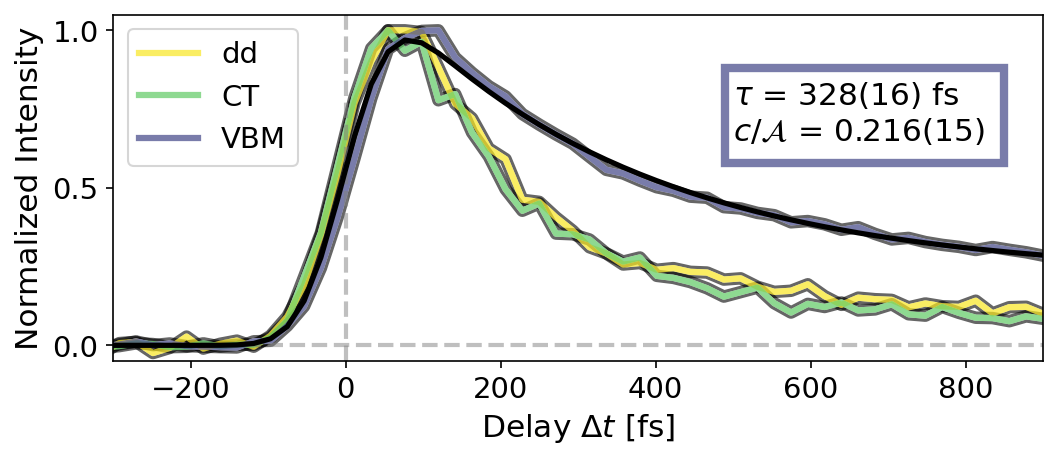

In [ ]:
from uncertainties import ufloat
fig, ax = plt.subplots()
fig.set_size_inches(8,3)
fontsize = 15

E_CBM = 1.58
E_dd = 0.75
neg_delays = (-250, -100)

# Compute & Normalize Time Traces
trace_CBM = mpes.get_time_trace(I_res[2], E=E_CBM, E_int=0.3, k=(0,0), k_int=(4,4), subtract_neg=True, neg_delays=neg_delays)
trace_CBM = trace_CBM / np.max(trace_CBM)

trace_dd = mpes.get_time_trace(I_res[2], E=E_dd, E_int=0.3, k=(0,0), k_int=(4,4), subtract_neg=True, neg_delays=neg_delays)
trace_dd = trace_dd / np.max(trace_dd)

trace_VBB = mpes.get_time_trace(I_res[2], E=0.1, E_int=0.2, k=(0,0), k_int=(4,4), subtract_neg=True, neg_delays=neg_delays)
trace_VBB = trace_VBB / np.max(trace_VBB)

# Plot Time Traces
traces = [trace_dd, trace_CBM, trace_VBB]
labels = [fr'dd', fr'CT', fr'VBM']
colormap = mpl.colormaps['viridis']
colors = [colormap(0.99), colormap(0.75), colormap(0.2)]

for trace in traces:
    ax.plot(trace.delay.values, trace.values, color='black', alpha=0.6, lw=6)
    ax.plot(trace.delay.values, trace.values, color='white', alpha=1, lw=3)
for trace, color, label in zip(traces, colors, labels):
    ax.plot(trace.delay.values, trace.values, color=color, alpha=0.7, lw=3, label=label)

# Fit Valence Band
delay_limits = (-315, 1000)
delay_axis = I_res[2].delay.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
fwhm_IRF = 110 #Checking VBM dynamics, it looks like 110 fs is the best value for 1095, excited state fits also work well with this
sigma_IRF= fwhm_IRF/2.355

I_values = trace_VBB.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
model = 'monoexp_const'
if model == 'biexp':
    initial_params = [1, 300, 1, 2000]
    lower_bounds, upper_bounds = (0.1, 50, 0.1, 50), (10, 20000, 10, 20000)
elif model == 'monoexp_const':
    initial_params = [1, 500, 0.2]
    lower_bounds, upper_bounds = (0.1, 50, 0.01), (10, 20000, 1)
popt, pcov, fit = mpes.fit_time_trace(model, delay_axis, I_values, initial_params, [lower_bounds, upper_bounds], convolve = True, sigma_IRF = sigma_IRF)
params, label = mpes.print_fit_results(model, popt, pcov)

# Annotate Plot with decay constants
if model == 'biexp':
    tau_short = params['tau_decay1']
    tau_short_err = params['errors']['tau_decay1']
    tau_label = fr'$\tau_{{\mathrm{{short}}}}$ = {round(tau_short, tau_short_err, cutoff=19, sep='external_brackets'):8}fs{'\n'}$\tau_{{\mathrm{{long}}}}${'':2}> 20{'':9}ps'
elif model == 'monoexp_const':
    tau = params['tau_decay1']
    tau_err = params['errors']['tau_decay1']
    A = ufloat(params['A'], params['errors']['A'])
    c = ufloat(params['c'], params['errors']['c'])
    ratio = c / A
    ratio_label = round(ratio.n, ratio.s, cutoff=19, sep='external_brackets')
    tau_label = fr'$\tau$ = {round(tau, tau_err, cutoff=19, sep='external_brackets')} fs{'\n'}$c/\mathcal{{A}}$ = {ratio_label}'

ax.text(x=500, y=0.65, s=tau_label, color='black', size=fontsize)
mpes.add_rect(670, 360, 0.73, 0.3, ax=ax, facecolor='white', edgecolor=colors[2], alpha=0.7, linewidth=4)

ax.axhline(0, color='grey', linestyle='dashed', alpha=0.5, linewidth=2)
ax.axvline(0, color='grey', linestyle='dashed', alpha=0.5, linewidth=2)

ax.plot(delay_axis, fit, color='black', lw=2.5)
ax.legend(fontsize=fontsize-1, loc='upper left')
ax.set_xlim(-300,900)
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel(fr'Delay $\Delta t$ [fs]', fontsize=fontsize)
ax.set_ylabel(fr'Normalized Intensity', fontsize=fontsize)
ax.tick_params(labelsize=fontsize-1)
##fig.savefig('./Figures/Thesis/VB_Dynamics_Fit.pdf', bbox_inches='tight')

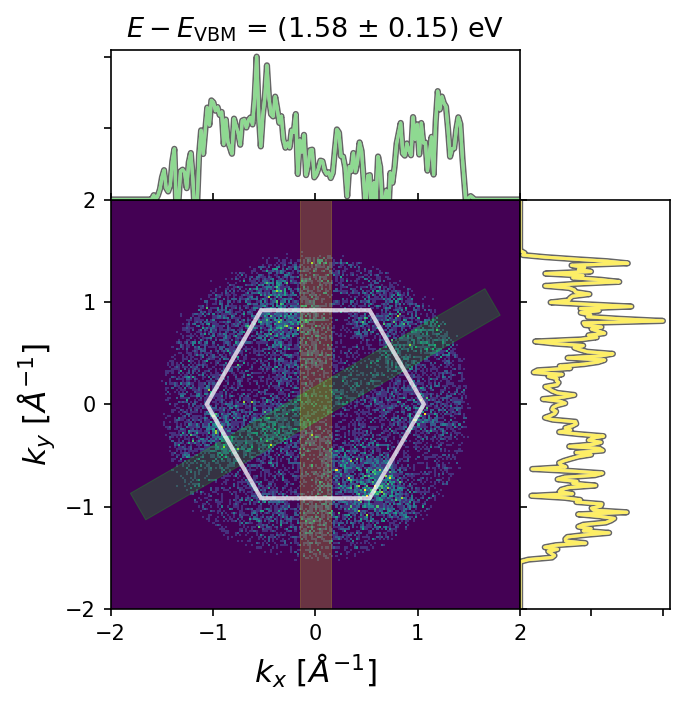

In [ ]:
# Not a figure in Thesis.
# I used this to get the MDCs and then save them to .csv-Files so I can load them later rather than having to recompute them every time
fig, ax = plt.subplots()

Energy = 1.58
map = mpes.get_momentum_map(I_diff[2], E=Energy, E_int=0.3, delay=0, delay_int=2000)

k_zero_x = [0, 0]
k_zero_y = [0, 0]
x_angle = 30
y_angle = 0
width = 0.3

ax_mdc_x, mdc_x, ax_mdc_y, mdc_y = mpes.plot_mdcs(map, fig=fig, ax=ax,
                                                  k_zero_x=k_zero_x, k_zero_y=k_zero_y, angle_xaxis=x_angle, angle_yaxis=y_angle,
                                                  mdc_x_width = width, mdc_y_width = width)
mpes.overlay_bz('hexagonal', a=3.95, b=3.95, ax=ax, color='white', rotation_deg=30)

In [ ]:
# Save MDCs to .csv-Files
def SaveMDC(mdc, csv_file):
    mdc = [mdc.k.values, mdc.values]
    with open(csv_file, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerows(mdc)

#SaveMDC(mdc_x, './MDCs_CT/M4_G_M1_Diff.csv')
#SaveMDC(mdc_y, './MDCs_CT/M5_G_M2_Diff.csv')

#SaveMDC(mdc_x, './MDCs_VBM/M3_G_M6.csv')
#SaveMDC(mdc_y, './MDCs_VBM/M5_G_M2.csv')

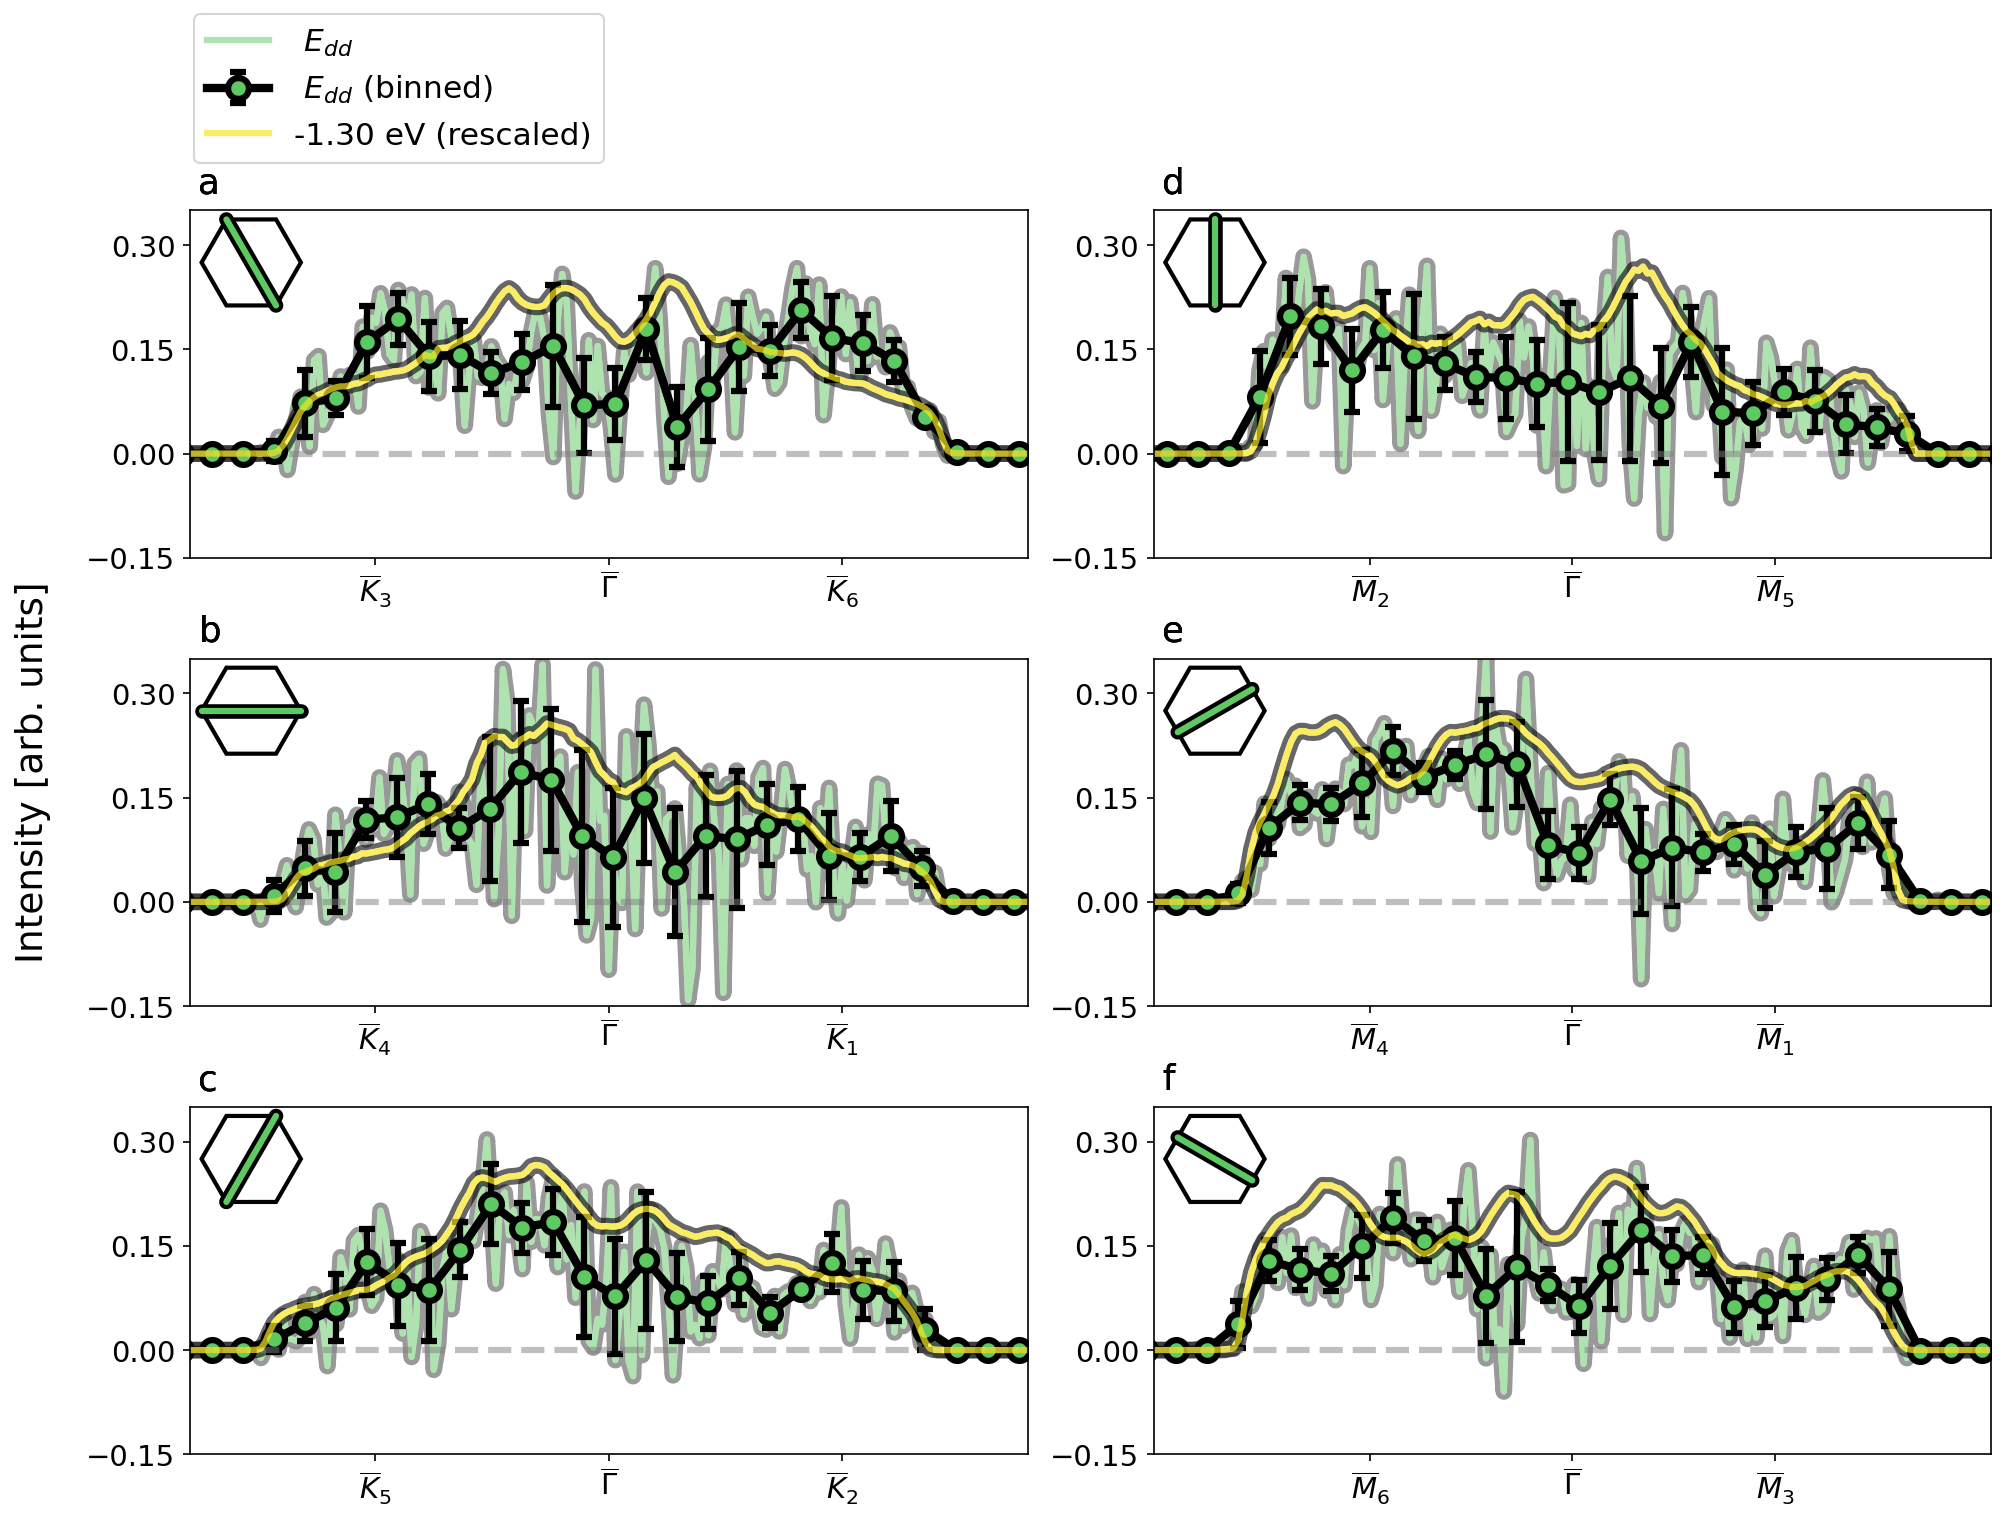

In [16]:
from matplotlib.patches import RegularPolygon
fig, axs = plt.subplots(3,2)
axs = axs.flatten()
fig.set_size_inches(13,10)
fontsize = 15

def bin_mdc(mdc, bins):
    N = len(mdc[0])
    binned_k = []
    binned_I = []
    binned_I_err = []
    for i in range(int(np.floor(N/bins))):
        k_chunks = []
        I_chunks = []
        for j in range(bins):
            k_chunks.append(mdc[0][(bins*i)+j])
            I_chunks.append(mdc[1][(bins*i)+j])
    
        binned_k.append(np.mean(k_chunks))
        binned_I.append(np.mean(I_chunks))
        binned_I_err.append(np.std(I_chunks))
    
    return np.array([binned_k, binned_I, binned_I_err])

# Load MDCs from .csv-Files
mdc_K4GK1_diff = np.genfromtxt('./MDCs_dd/K4_G_K1_Diff.csv', delimiter=',')
mdc_M5GM2_diff = np.genfromtxt('./MDCs_dd/M5_G_M2_Diff.csv', delimiter=',')
mdc_K3GK6_diff = np.genfromtxt('./MDCs_dd/K3_G_K6_Diff.csv', delimiter=',')
mdc_M4GM1_diff = np.genfromtxt('./MDCs_dd/M4_G_M1_Diff.csv', delimiter=',')
mdc_K5GK2_diff = np.genfromtxt('./MDCs_dd/K5_G_K2_Diff.csv', delimiter=',')
mdc_M6GM3_diff = np.genfromtxt('./MDCs_dd/M3_G_M6_Diff.csv', delimiter=',') #Order of M-Points in filename is mixed up due to typo
mdc_K4GK1_m13 = np.genfromtxt('./MDCs_m1p3/K4_G_K1.csv', delimiter=',')
mdc_M5GM2_m13 = np.genfromtxt('./MDCs_m1p3/M5_G_M2.csv', delimiter=',')
mdc_K3GK6_m13 = np.genfromtxt('./MDCs_m1p3/K3_G_K6.csv', delimiter=',')
mdc_M4GM1_m13 = np.genfromtxt('./MDCs_m1p3/M4_G_M1.csv', delimiter=',')
mdc_K5GK2_m13 = np.genfromtxt('./MDCs_m1p3/K5_G_K2.csv', delimiter=',')
mdc_M6GM3_m13 = np.genfromtxt('./MDCs_m1p3/M3_G_M6.csv', delimiter=',') #Order of M-Points in filename is mixed up due to typo

ax_labels = [[fr'$\overline{{K}}_{{3}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{K}}_{{6}}$'],
             [fr'$\overline{{M}}_{{5}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{M}}_{{2}}$'],
             [fr'$\overline{{K}}_{{4}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{K}}_{{1}}$'],
             [fr'$\overline{{M}}_{{4}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{M}}_{{1}}$'],
             [fr'$\overline{{K}}_{{5}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{K}}_{{2}}$'],
             [fr'$\overline{{M}}_{{6}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{M}}_{{3}}$']]

diff_mdcs = [mdc_K3GK6_diff, mdc_M5GM2_diff, mdc_K4GK1_diff, mdc_M4GM1_diff, mdc_K5GK2_diff, mdc_M6GM3_diff]
VB_mdcs = [mdc_K3GK6_m13, mdc_M5GM2_m13, mdc_K4GK1_m13, mdc_M4GM1_m13, mdc_K5GK2_m13, mdc_M6GM3_m13]

colormap = mpl.colormaps['viridis']
colors = ['black', 'white', colormap(0.75)]
colors_2 = ['black', 'white', colormap(0.99)]
alphas = [0.4, 1, 0.5]
alphas_2 = [0.6, 1, 0.7]
linewidths = [8, 3, 3]

# Format Axes
for i, ax in enumerate(axs):
    ax.axhline(0, lw=3, color='grey', linestyle='dashed', alpha=0.5)
    ax.set_xlim(-1.9,1.9)
    ax.set_ylim(-0.15,0.35)
    ax.set_yticks([-0.15, 0, 0.15, 0.3])
    ax.tick_params(labelsize=fontsize-1)
    ax.set_aspect(abs((1.9+1.9)/(0.35+0.15))*0.415)
    if i%2 == 0:
        ax.set_xticks([-K_dist, 0, K_dist], labels=ax_labels[i])
    else:
        ax.set_xticks([-M_dist, 0, M_dist], labels=ax_labels[i])

bins = 7
panel_labels = ['a', 'd', 'b', 'e', 'c', 'f']

# Plot MDCs
for i, (alpha, alpha_2, lw) in enumerate(zip(alphas, alphas_2, linewidths)):
    for j, (diff_mdc, vb_mdc) in enumerate(zip(diff_mdcs, VB_mdcs)):
        axs[j].plot(diff_mdc[0], diff_mdc[1], color=colors[i], alpha=alpha, lw=lw, zorder=0)
        axs[j].annotate(panel_labels[j],(0.01, 1.05), xycoords='axes fraction', fontsize=fontsize+2)
        if i == 2:
            binned_mdc = bin_mdc(diff_mdc, bins=bins)
            axs[j].errorbar(x=binned_mdc[0], y=binned_mdc[1], yerr=binned_mdc[2], fmt='o', lw=lw+1, ls='solid', ecolor='black', mec='black', mfc=colors[2], mew=lw,
                            color='black', capsize=lw+1, elinewidth=lw, ms=10, zorder=1)
            axs[j].plot(vb_mdc[0], 0.35*vb_mdc[1], color=colors_2[i], alpha=alpha_2, lw=lw, zorder=2)
        else:
            axs[j].plot(vb_mdc[0], 0.35*vb_mdc[1], color=colors_2[i], alpha=alpha_2, lw=lw, zorder=1)

axs[1].invert_xaxis() # Flip x-Axis on axs[1] for visual consistency (k should go even M-Point to Gamma to odd M-Point)

# Plot Brillouin Zone Patches with Line indicators for MDC-Direction
for i, ax in enumerate(axs):
    aspect = ax.get_aspect()
    ylim = ax.get_ylim()
    y_factor = (ylim[1]-ylim[0]) / (0.35)
    y_patch = ((ylim[1]-ylim[0]) * 0.85 + ylim[0]) / y_factor
    if i == 1:
        hexagon = RegularPolygon(xy=(0.36, y_patch), numVertices=6, radius=0.05, orientation=np.pi/6, edgecolor='black', fill=False, lw=2, zorder=1)
    else:
        hexagon = RegularPolygon(xy=(-0.36, y_patch), numVertices=6, radius=0.05, orientation=np.pi/6, edgecolor='black', fill=False, lw=2, zorder=1)
    verts = hexagon.get_verts()
    hexagon.set_transform(mpl.transforms.Affine2D().scale(sx=aspect*y_factor, sy=y_factor) + ax.transData)
    ax.add_patch(hexagon)
    if i%2 == 0:
        index = int(np.floor(i/2))
        x1 = verts[index][0]*aspect*y_factor
        x2 = verts[index+3][0]*aspect*y_factor
        y1 = verts[index][1]*y_factor
        y2 = verts[index+3][1]*y_factor
    else:
        index = int(np.floor(i/2))
        # The M-G-M Lines turned out to be a mess. Very bad code, do not touch
        if i == 5:
            x1 = (verts[4][0]*aspect*y_factor + verts[3][0]*aspect*y_factor) / 2
            x2 = (verts[6][0]*aspect*y_factor + verts[1][0]*aspect*y_factor) / 2
            y1 = (verts[4][1]*y_factor + verts[3][1]*y_factor) / 2
            y2 = (verts[6][1]*y_factor + verts[1][1]*y_factor) / 2
        elif i == 1:
            x1 = (verts[2][0]*aspect*y_factor + verts[3][0]*aspect*y_factor) / 2
            x2 = (verts[0][0]*aspect*y_factor + verts[5][0]*aspect*y_factor) / 2
            y1 = (verts[2][1]*y_factor + verts[3][1]*y_factor) / 2
            y2 = (verts[0][1]*y_factor + verts[5][1]*y_factor) / 2
        else:
            x1 = (verts[index][0]*aspect*y_factor + verts[index+1][0]*aspect*y_factor) / 2
            x2 = (verts[index+3][0]*aspect*y_factor + verts[index+4][0]*aspect*y_factor) / 2
            y1 = (verts[index][1]*y_factor + verts[index+1][1]*y_factor) / 2
            y2 = (verts[index+3][1]*y_factor + verts[index+4][1]*y_factor) / 2
    ax.plot([x1, x2], [y1, y2], lw=3, zorder=1, color=colormap(0.75), solid_capstyle='round',
            path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=1), pe.Normal()])

# Dummy plots for legend
l1, = axs[0].plot(-100, -100, color=colors[2], alpha=alphas[2], lw=linewidths[2], label=fr' $E_{{dd}}$')
l2 = axs[0].errorbar(x=-100, y=-100, yerr=5, fmt='o', lw=linewidths[2]+1, ls='solid', ecolor='black', mec='black', mfc=colors[2], mew=linewidths[2],
                            color='black', capsize=linewidths[2]+1, elinewidth=linewidths[2], ms=10, label=fr' $E_{{dd}}$ (binned)')
l3, = axs[0].plot(-100, -100, color=colors_2[2], alpha=alphas_2[2], lw=linewidths[2], label=fr'-1.30 eV (rescaled)')
axs[0].legend(fontsize=fontsize, handles=[l1, l2, l3], bbox_to_anchor=(0.25,1.35), loc='center')


fig.text(-0.025, 0.5, 'Intensity [arb. units]', va='center', rotation='vertical', fontsize=fontsize+3)
fig.tight_layout()

#fig.savefig('./Figures/Thesis/MDC-Comparison-dd-through-Gamma-newLegend.pdf', bbox_inches='tight')

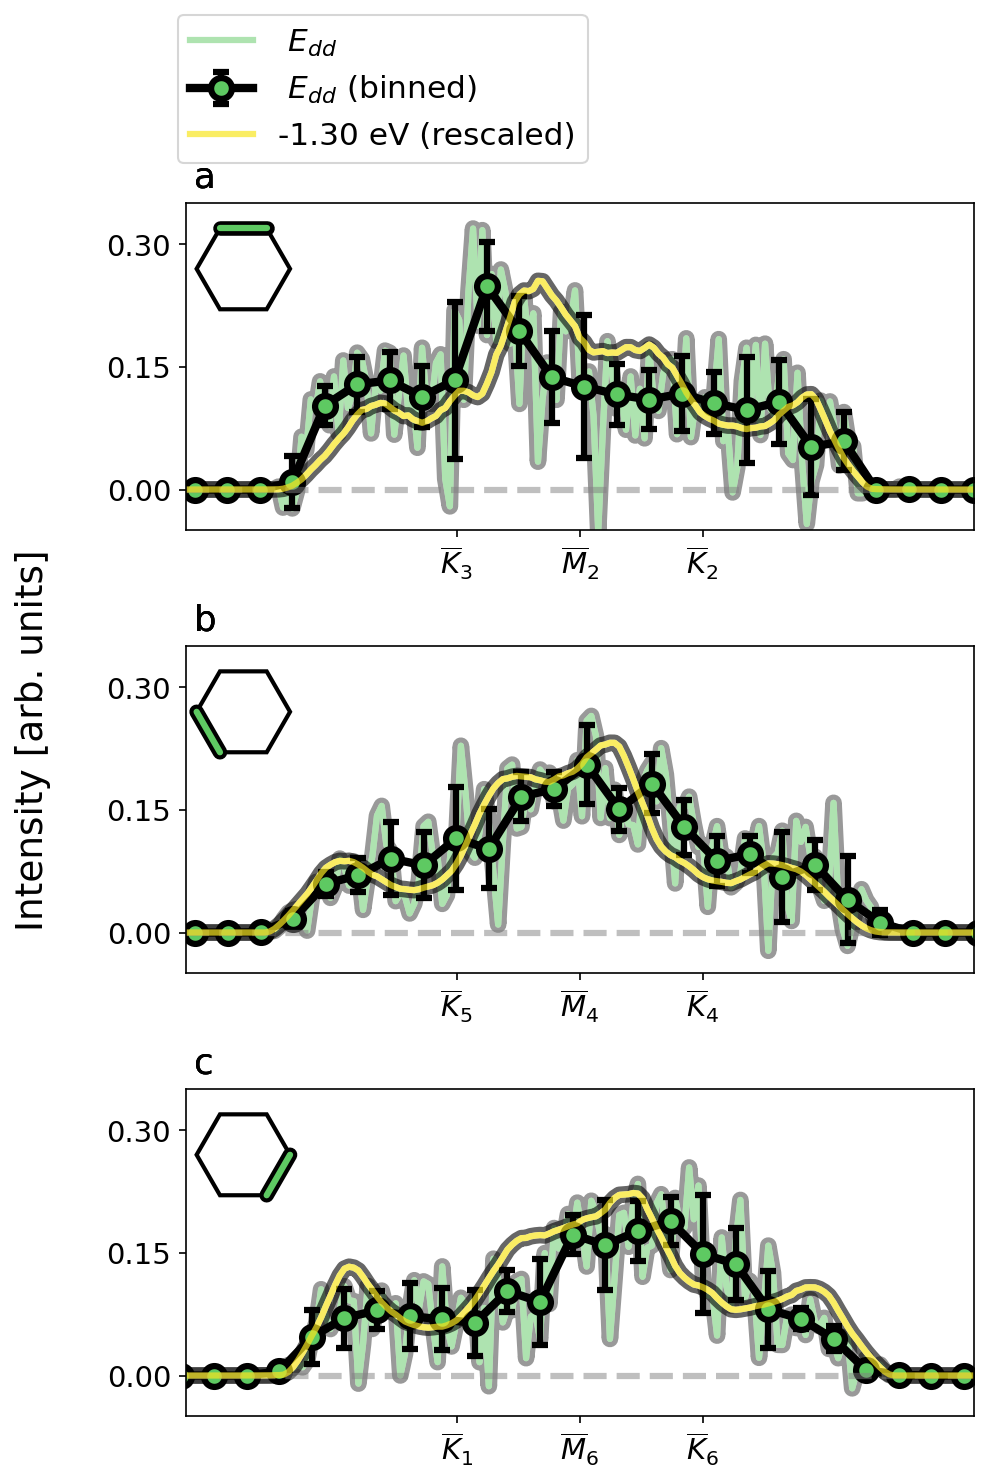

In [15]:
from matplotlib.patches import RegularPolygon
fig, axs = plt.subplots(3,1)
axs = axs.flatten()
fig.set_size_inches(7,10)
fontsize = 15

# Load MDCs
mdc_K3M2K2 = np.genfromtxt('./MDCs_dd/K3_M2_K2_Diff.csv', delimiter=',')
mdc_K5M4K4 = np.genfromtxt('./MDCs_dd/K5_M4_K4_Diff.csv', delimiter=',')
mdc_K6M6K1 = np.genfromtxt('./MDCs_dd/K6_M6_K1_Diff.csv', delimiter=',')
diff_mdcs = [mdc_K3M2K2, mdc_K5M4K4, mdc_K6M6K1]

mdc_VB_K3M2K2 = np.genfromtxt('./MDCs_m1p3/K3_M2_K2.csv', delimiter=',')
mdc_VB_K4M4K5 = np.genfromtxt('./MDCs_m1p3/K4_M4_K5.csv', delimiter=',')
mdc_VB_K6M6K1 = np.genfromtxt('./MDCs_m1p3/K6_M6_K1.csv', delimiter=',')
VB_mdcs = [mdc_VB_K3M2K2, mdc_VB_K4M4K5, mdc_VB_K6M6K1]

def bin_mdc(mdc, bins):
    N = len(mdc[0])
    binned_k = []
    binned_I = []
    binned_I_err = []
    for i in range(int(np.floor(N/bins))):
        k_chunks = []
        I_chunks = []
        for j in range(bins):
            k_chunks.append(mdc[0][(bins*i)+j])
            I_chunks.append(mdc[1][(bins*i)+j])
    
        binned_k.append(np.mean(k_chunks))
        binned_I.append(np.mean(I_chunks))
        binned_I_err.append(np.std(I_chunks))
    
    return np.array([binned_k, binned_I, binned_I_err])

ax_labels = [[fr'$\overline{{K}}_{{3}}$', fr'$\overline{{M}}_{{2}}$', fr'$\overline{{K}}_{{2}}$'],
             [fr'$\overline{{K}}_{{5}}$', fr'$\overline{{M}}_{{4}}$', fr'$\overline{{K}}_{{4}}$'],
             [fr'$\overline{{K}}_{{6}}$', fr'$\overline{{M}}_{{6}}$', fr'$\overline{{K}}_{{1}}$']]

# Axis Formatting
MK_dist = (2*np.pi) / (3*3.95)
for i, ax in enumerate(axs):
    ax.set_xticks([-MK_dist, 0, MK_dist], labels=ax_labels[i])
    ax.axhline(0, lw=3, color='grey', linestyle='dashed', alpha=0.5)
    ax.set_xlim(-1.7,1.7)
    ax.set_ylim(-0.05,0.35)
    ax.set_yticks([0, 0.15, 0.3])
    ax.tick_params(labelsize=fontsize-1)
    ax.set_aspect(abs((1.7+1.7)/(0.35+0.05))*0.415)

colormap = mpl.colormaps['viridis']
colors = ['black', 'white', colormap(0.75)]
colors_2 = ['black', 'white', colormap(0.99)]
alphas = [0.4, 1, 0.5]
alphas_2 = [0.6, 1, 0.7]
linewidths = [8, 3, 3]

bins = 7
panel_labels = ['a', 'b', 'c']

# Plot MDCs
for i, (alpha, alpha_2, lw) in enumerate(zip(alphas, alphas_2, linewidths)):
    for j, (diff_mdc, vb_mdc) in enumerate(zip(diff_mdcs, VB_mdcs)):
        axs[j].annotate(panel_labels[j],(0.01, 1.05), xycoords='axes fraction', fontsize=fontsize+2)
        axs[j].plot(diff_mdc[0], diff_mdc[1], color=colors[i], alpha=alpha, lw=lw, zorder=0)
        if i == 2:
            binned_mdc = bin_mdc(diff_mdc, bins=bins)
            axs[j].errorbar(x=binned_mdc[0], y=binned_mdc[1], yerr=binned_mdc[2], fmt='o', lw=lw+1, ls='solid', ecolor='black', mec='black', mfc=colors[2], mew=lw,
                            color='black', capsize=lw+1, elinewidth=lw, ms=10, zorder=1)
            axs[j].plot(vb_mdc[0], 0.35*vb_mdc[1], color=colors_2[i], alpha=alpha_2, lw=lw, zorder=2)
        else:
            axs[j].plot(vb_mdc[0], 0.35*vb_mdc[1], color=colors_2[i], alpha=alpha_2, lw=lw, zorder=1)

# Plot Brillouin Zone Patches with Line indicators for MDC-Direction
for i, ax in enumerate(axs):
    aspect = ax.get_aspect()
    ylim = ax.get_ylim()
    y_factor = (ylim[1]-ylim[0]) / (0.35)
    y_patch = ((ylim[1]-ylim[0]) * 0.8 + ylim[0]) / y_factor
    if i == 2:
        hexagon = RegularPolygon(xy=(0.36,y_patch), numVertices=6, radius=0.05, orientation=np.pi/6, edgecolor='black', fill=False, lw=2, zorder=1)
    else:
        hexagon = RegularPolygon(xy=(-0.36,y_patch), numVertices=6, radius=0.05, orientation=np.pi/6, edgecolor='black', fill=False, lw=2, zorder=1)
    verts = hexagon.get_verts()
    hexagon.set_transform(mpl.transforms.Affine2D().scale(sx=aspect*y_factor, sy=y_factor) + ax.transData)
    ax.add_patch(hexagon)
    if i == 2: # axs[2] needs to be done separately because the x-axis gets flipped later
        x1 = verts[1][0]*aspect*y_factor
        x2 = verts[2][0]*aspect*y_factor
        y1 = verts[1][1]*y_factor
        y2 = verts[2][1]*y_factor
    else:
        x1 = verts[2*i][0]*aspect*y_factor
        x2 = verts[(2*i+5)%6][0]*aspect*y_factor
        y1 = verts[2*i][1]*y_factor
        y2 = verts[(2*i+5)%6][1]*y_factor
    ax.plot([x1, x2], [y1, y2], lw=3, zorder=1, color=colormap(0.75), solid_capstyle='round',
            path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=1), pe.Normal()])

# Dummy plots for legend
l1, = axs[0].plot(-100, -100, color=colors[2], alpha=alphas[2], lw=linewidths[2], label=fr' $E_{{dd}}$')
l2 = axs[0].errorbar(x=-100, y=-100, yerr=5, fmt='o', lw=linewidths[2]+1, ls='solid', ecolor='black', mec='black', mfc=colors[2], mew=linewidths[2],
                            color='black', capsize=linewidths[2]+1, elinewidth=linewidths[2], ms=10, label=fr' $E_{{dd}}$ (binned)')
l3, = axs[0].plot(-100, -100, color=colors_2[2], alpha=alphas_2[2], lw=linewidths[2], label=fr'-1.30 eV (rescaled)')
axs[0].legend(fontsize=fontsize, handles=[l1, l2, l3], bbox_to_anchor=(0.25,1.35), loc='center')

axs[2].invert_xaxis() # Flip x-axis of axs[2] for visual consistency (k goes from odd K-Point to M to even K-Point)

fig.text(0, 0.5, 'Intensity [arb. units]', va='center', rotation='vertical', fontsize=fontsize+3)
fig.tight_layout()

#fig.savefig('./Figures/Thesis/MDC-Comparison-dd-KMK-newLegend.pdf', bbox_inches='tight')

Projection of GK_min in 2BZ onto GK-Line: 1.20 1/angstrom
Projection of GM_min in 1BZ onto GK-Line: 0.33 1/angstrom
Projection of KM_min: 0.97 1/angstrom


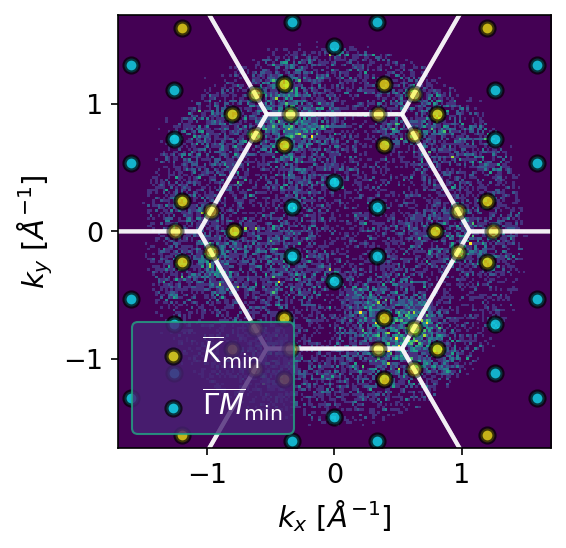

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(4,4)

CBM_Gamma_dist = K_dist * 0.74

mpes.plot_momentum_maps(I_res[2], E=1.58, E_int=0.3, fig=fig, ax=ax)
mpes.overlay_bz('hexagonal', a=3.95, b=3.95, ax=ax, color='white', rotation_deg=30, repeat=1)

CBM_color = 'yellow'
CBM_alpha = 0.7
lw = 2
edgecolor = 'black'
size = 45
# CBM of first Brillouin Zone
for i in range(6):
    angle = i*(np.pi/3)
    x = np.cos(angle) * CBM_Gamma_dist
    y = np.sin(angle) * CBM_Gamma_dist
    ax.scatter(x, y, color=CBM_color, alpha=CBM_alpha, edgecolor=edgecolor, lw=lw, s=size)

# Gamma-M Minimum of first Brillouin Zone
CBM_GM_dist = M_dist * 0.42
for i in range(6):
    angle = i*(np.pi/3) + (np.pi/6)
    x = np.cos(angle) * CBM_GM_dist
    y = np.sin(angle) * CBM_GM_dist
    ax.scatter(x, y, color='cyan', alpha=CBM_alpha, edgecolor=edgecolor, lw=lw, s=size)

# CBM of second Brillouin Zones
for j in range(6):
    gamma_angle = j*(np.pi/3) + (np.pi/6)
    new_Gamma = np.array([np.cos(gamma_angle), np.sin(gamma_angle)])
    new_Gamma = new_Gamma * 2 * M_dist
    for i in range(6):
        angle = i*(np.pi/3)
        x = (np.cos(angle) * CBM_Gamma_dist) + new_Gamma[0]
        y = (np.sin(angle) * CBM_Gamma_dist) + new_Gamma[1]
        ax.scatter(x, y, color=CBM_color, alpha=CBM_alpha, edgecolor=edgecolor, lw=lw, s=size)

# Gamma-M Minimum of second Brillouin Zones
for j in range(6):
    gamma_angle = j*(np.pi/3) + (np.pi/6)
    new_Gamma = np.array([np.cos(gamma_angle), np.sin(gamma_angle)])
    new_Gamma = new_Gamma * 2 * M_dist
    for i in range(6):
        angle = i*(np.pi/3) + (np.pi/6)
        x = (np.cos(angle) * CBM_GM_dist) + new_Gamma[0]
        y = (np.sin(angle) * CBM_GM_dist) + new_Gamma[1]
        ax.scatter(x, y, color='cyan', alpha=CBM_alpha, edgecolor=edgecolor, lw=lw, s=size)

# M-K-Minimum of first Brillouin Zone
MK_dist = (2*np.pi) / (3*3.95)
MK_min = 0.35 * MK_dist
for i in range(6):
    angle_K = i * np.pi/3
    vec_K = K_dist * np.array([np.cos(angle_K), np.sin(angle_K)])
    for j in range(3):
        angle = j*2*np.pi/3
        x = vec_K[0] + MK_min * np.cos(angle+angle_K)
        y = vec_K[1] + MK_min * np.sin(angle+angle_K)
        ax.scatter(x, y, color=CBM_color, alpha=CBM_alpha-0.2, edgecolor=edgecolor, lw=lw, s=size)

# I first tried doing all of the projections for the MDCs here so that I could also plot the projections once to check that everything works as it should
GK_min_2BZ = np.array([(np.cos(4*(np.pi/3)) * CBM_Gamma_dist) + (np.cos((np.pi/3)+(np.pi/6)) * 2 * M_dist),
                       (np.sin(4*(np.pi/3)) * CBM_Gamma_dist) + (np.sin((np.pi/3)+(np.pi/6)) * 2 * M_dist)])
normal = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])
GK_projection_2BZ = np.dot(GK_min_2BZ, normal)
print(fr'Projection of GK_min in 2BZ onto GK-Line: {GK_projection_2BZ:.2f} 1/angstrom')
normal_MGM = np.array([0,1])
GK_proj_2BZ_MGM = np.dot(GK_min_2BZ, normal_MGM)

GM_min_1BZ = np.array([(np.cos((np.pi/3) + (np.pi/6)) * CBM_GM_dist),
                      (np.sin((np.pi/3) + (np.pi/6)) * CBM_GM_dist)])

GK_min_1BZ = np.array([(np.cos(2*(np.pi/3)) * CBM_Gamma_dist), (np.sin(2*(np.pi/3)) * CBM_Gamma_dist)])
GK_proj_1BZ_MGM = np.dot(GK_min_1BZ, normal_MGM)

normal = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])
GM_projection_1BZ = np.dot(GM_min_1BZ, normal)
print(fr'Projection of GM_min in 1BZ onto GK-Line: {GM_projection_1BZ:.2f} 1/angstrom')

MK_min = np.array([(vec_K1[0] + MK_min * np.cos(2*np.pi/3)), (vec_K1[1] + MK_min * np.sin(2*np.pi/3))])
normal = np.array([1, 0])
MK_projection = np.dot(MK_min, normal)
print(fr'Projection of KM_min: {MK_projection:.2f} 1/angstrom')
normal_MGM2 = np.array([np.cos(np.pi/6), np.sin(np.pi/6)])
MK_proj_MGM = np.dot(MK_min, normal_MGM2)

ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)
ax.set_title('')



# Dummy plots for legend
cbm = ax.scatter(-100, -100, color=CBM_color, alpha=CBM_alpha, edgecolor=edgecolor, lw=lw, s=size, label=fr'$\overline{{K}}_{{\mathrm{{min}}}}$')
gamma_m = ax.scatter(-100, -100, color='cyan', alpha=CBM_alpha, edgecolor=edgecolor, lw=lw, s=size, label=fr'$\overline{{\Gamma M}}_{{\mathrm{{min}}}}$')

colormap = mpl.colormaps['viridis']
ax.legend(labelcolor='white', edgecolor=colormap(0.6), facecolor=colormap(0.1), loc='lower left', fontsize=14, handles=[cbm, gamma_m], handletextpad=0)

#fig.savefig('./Figures/Thesis/CBM-DFT-Points.pdf', bbox_inches='tight')


Fit Results for model: monoexp_const
----------------------------------------
A          =       1.54 ±     0.03 (  1.87 %)
tau_decay1 =     175.14 ±     6.26 (  3.58 %)
c          =       0.09 ±     0.01 ( 10.87 %)
----------------------------------------

Fit Results for model: monoexp_const
----------------------------------------
A          =       1.45 ±     0.05 (  3.67 %)
tau_decay1 =     139.05 ±     8.35 (  6.00 %)
c          =       0.08 ±     0.01 ( 15.25 %)
----------------------------------------


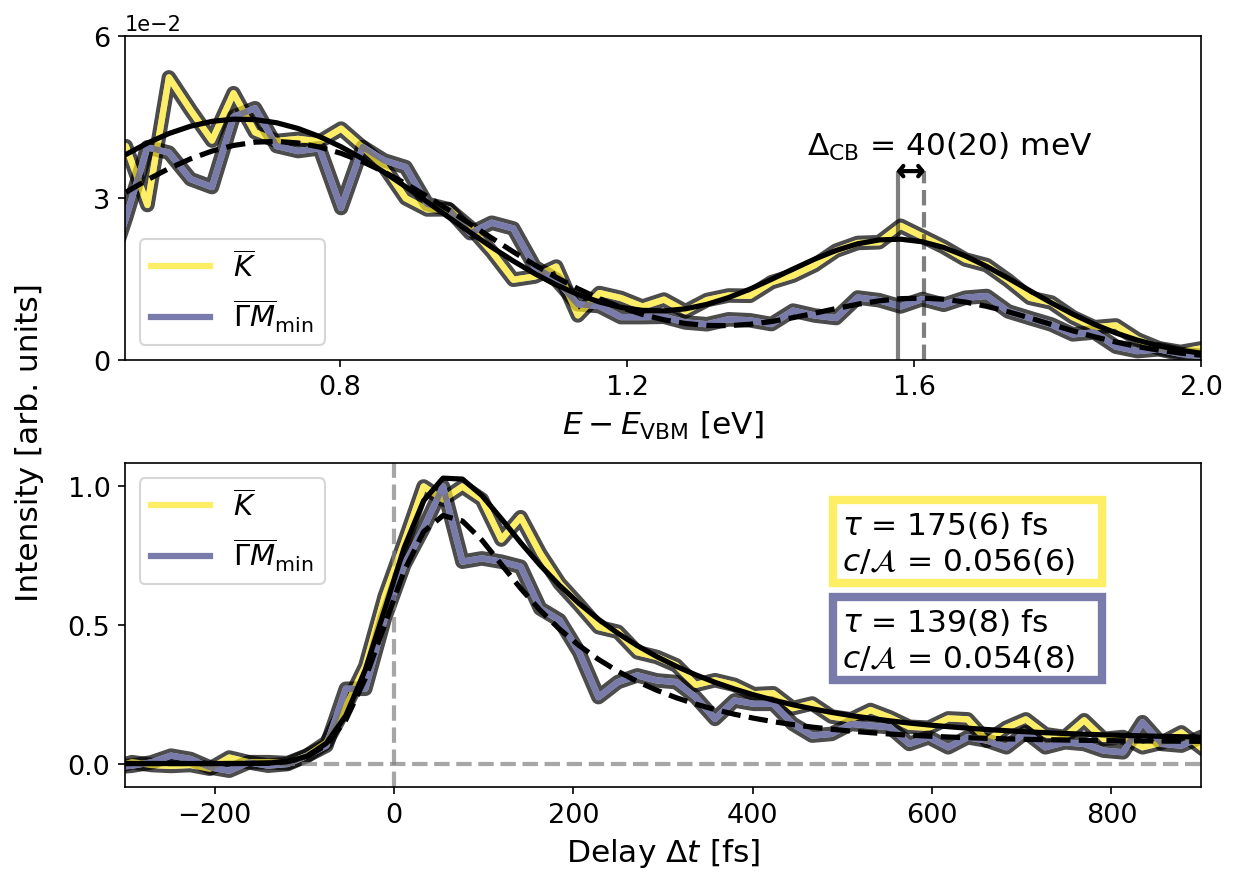

In [8]:
from uncertainties import ufloat
fig, axs = plt.subplots(2,1)
axs = axs.flatten()
fig.set_size_inches(8,6)
fontsize = 15

colormap = mpl.colormaps['viridis']
colors = colormap(np.linspace(0.2,1,num=2))

# Mask off just K-Points and just GammaM-minima
masked_K = mpes.CircleMasks(I_diff[2], k=vec_K1, radius=0.3, repeat=6)
masked_M = mpes.CircleMasks(I_diff[2], k=vec_M1*0.42, radius=0.3, repeat=6)

# Get and plot EDCs
edc_K = mpes.get_edc(masked_K.loc[{'E':slice(0,2.5)}], kx=0, ky=0, kx_int=4, ky_int=4, delay=0, delay_int=2000)
edc_K = edc_K / np.max(edc_K)
edc_M = mpes.get_edc(masked_M.loc[{'E':slice(0,2.5)}], kx=0, ky=0, kx_int=4, ky_int=4, delay=0, delay_int=2000)
edc_M = edc_M / np.max(edc_M)

edc_K.plot(ax=axs[0], color='white', lw=3, alpha=1,
        path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=0.7), pe.Normal()])
edc_M.plot(ax=axs[0], color='white', lw=3, alpha=1,
        path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=0.7), pe.Normal()])
edc_K.plot(ax=axs[0], color=colors[1], lw=3, alpha=0.7, label=fr'$\overline{{K}}$')
edc_M.plot(ax=axs[0], color=colors[0], lw=3, alpha=0.7, label=fr'$\overline{{\Gamma M}}_{{\mathrm{{min}}}}$')

# Fit EDCs and plot Fits
E_cutoff = 0.5
edc_K_fit = edc_K.loc[{'E':slice(E_cutoff, 2.5)}]
edc_M_fit = edc_M.loc[{'E':slice(E_cutoff, 2.5)}]

def DoubleGauss(x,x0_a, FWHM_a, A_a, x0_b, FWHM_b, A_b):
    s_a = FWHM_a / 2.355
    s_b = FWHM_b / 2.355
    return A_a * np.exp(-(x-x0_a)**2 / (2 * s_a**2)) + A_b * np.exp(-(x-x0_b)**2 / (2 * s_b**2))

optimal_params_K, covar_matrix_K = curve_fit(DoubleGauss, edc_K_fit.E.values, edc_K_fit.values, p0=[1.6, 0.4, 0.03, 0.7, 0.6, 0.04])
uncertainties_K = np.sqrt(np.diag(covar_matrix_K))
E0_K, Delta_K = optimal_params_K[0], uncertainties_K[0]
optimal_params_M, covar_matrix_M = curve_fit(DoubleGauss, edc_M_fit.E.values, edc_M_fit.values, p0=[1.6, 0.4, 0.03, 0.7, 0.6, 0.04])
uncertainties_M = np.sqrt(np.diag(covar_matrix_M))
E0_M, Delta_M = optimal_params_M[0], uncertainties_M[0]

axs[0].plot(edc_K_fit.E.values, DoubleGauss(edc_K_fit.E.values, *optimal_params_K), color='black', lw=2.5)
axs[0].plot(edc_M_fit.E.values, DoubleGauss(edc_M_fit.E.values, *optimal_params_M), color='black', ls='dashed', lw=2.5)
axs[0].vlines(E0_K, ymin=0, ymax=0.035, color='black', alpha=0.5, lw=2)
axs[0].vlines(E0_M, ymin=0, ymax=0.035, color='black', alpha=0.5, linestyle='dashed', lw=2)

# Calculate and annotate Difference in Gaussian positions
M = ufloat(E0_M, Delta_M)
K = ufloat(E0_K, Delta_K)
Diff = M - K
axs[0].annotate('', xy=(E0_M+0.01, 0.035), xytext=((E0_K-0.01, 0.035)), arrowprops=dict(arrowstyle = '<->', mutation_aspect=2.5, mutation_scale=5, linewidth=2))
axs[0].annotate(fr'$\Delta_{{\mathrm{{CB}}}}$ = {round(Diff.n*1000, Diff.s*1000, cutoff=19, sep='external_brackets')} meV', xy=((E0_K+E0_M)/2.2, 0.038), fontsize=fontsize)

# Formating of EDC plot
axs[0].set_xlim(0.5,2)
axs[0].set_ylim(0,0.06)
axs[0].set_xlabel(fr'$E-E_{{\mathrm{{VBM}}}}$ [eV]', fontsize=fontsize)
axs[0].set_xticks([0.8, 1.2, 1.6, 2.0])
axs[0].set_yticks([0, 0.03, 0.06])
axs[0].ticklabel_format(axis='y', style='scientific', scilimits=(0,1))

# Get and plot TimeTraces
trace_K = mpes.get_time_trace(masked_K, E=1.58, E_int=0.3, k=(0,0), k_int=(4,4), norm_trace=True, subtract_neg=True, neg_delays=(-250,-100))
trace_M = mpes.get_time_trace(masked_M, E=1.58, E_int=0.3, k=(0,0), k_int=(4,4), norm_trace=True, subtract_neg=True, neg_delays=(-250,-100))

axs[1].plot(trace_K.delay.values, trace_K.values, color='white', lw=3, alpha=1,
                path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=0.7), pe.Normal()], zorder=0)
axs[1].plot(trace_K.delay.values, trace_K.values, color=colors[1], lw=3, alpha=0.7, zorder=1, label=fr'$\overline{{K}}$')
axs[1].plot(trace_M.delay.values, trace_M.values, color='white', lw=3, alpha=1,
                path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=0.7),  pe.Normal()], zorder=0)
axs[1].plot(trace_M.delay.values, trace_M.values, color=colors[0], lw=3, alpha=0.7, zorder=1, label=fr'$\overline{{\Gamma M}}_{{\mathrm{{min}}}}$')

# Fit TimeTraces and plot Fits
delay_limits = (-315, 1000)
delay_axis = I_res[2].delay.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
fwhm_IRF = 110 # fs
sigma_IRF= fwhm_IRF/2.355

K_values = trace_K.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
model = 'monoexp_const'
if model == 'biexp':
    initial_params = [1, 300, 1, 2000]
    lower_bounds, upper_bounds = (0.1, 50, 0.1, 50), (10, 20000, 10, 20000)
elif model == 'monoexp_const':
    initial_params = [1, 500, 0.2]
    lower_bounds, upper_bounds = (0.1, 50, 0.01), (10, 20000, 1)
popt_K, pcov_K, K_fit = mpes.fit_time_trace(model, delay_axis, K_values, initial_params, [lower_bounds, upper_bounds], convolve = True, sigma_IRF = sigma_IRF)
params_K, label_K = mpes.print_fit_results(model, popt_K, pcov_K)

M_values = trace_M.loc[{'delay':slice(delay_limits[0], delay_limits[1])}].values
model = 'monoexp_const'
if model == 'biexp':
    initial_params = [1, 300, 1, 600]
    lower_bounds, upper_bounds = (0.1, 50, 0.1, 50), (10, 1000, 10, 20000)
elif model == 'monoexp_const':
    initial_params = [1, 500, 0.2]
    lower_bounds, upper_bounds = (0.1, 50, 0.01), (10, 20000, 1)
popt_M, pcov_M, M_fit = mpes.fit_time_trace(model, delay_axis, M_values, initial_params, [lower_bounds, upper_bounds], convolve = True, sigma_IRF = sigma_IRF)
params_M, label_M = mpes.print_fit_results(model, popt_M, pcov_M)

axs[1].plot(delay_axis, K_fit, color='black', ls='solid', zorder=2, lw=2.5)
axs[1].plot(delay_axis, M_fit, color='black', ls='dashed', zorder=2, lw=2.5)

# Get Decay Constants and annotate TimeTrace plot
if model == 'biexp':
    tau_K_short = round(params_K['tau_decay1'],params_K['errors']['tau_decay1'], cutoff=19, sep='external_brackets')
    tau_K_long = round(params_K['tau_decay2'],params_K['errors']['tau_decay2'], cutoff=19, sep='external_brackets')
    tau_M_short = round(params_M['tau_decay1'],params_M['errors']['tau_decay1'], cutoff=19, sep='external_brackets')
    tau_M_long = round(params_M['tau_decay2'],params_M['errors']['tau_decay2'], cutoff=19, sep='external_brackets')

    K_label = fr'$\tau_{{\mathrm{{short}}}}$ = {tau_K_short:9} fs {'\n'}$\tau_{{\mathrm{{long}}}}${'':2}= {tau_K_long:6} fs'
    M_label = fr'$\tau_{{\mathrm{{short}}}}$ = {tau_M_short:9} fs {'\n'}$\tau_{{\mathrm{{long}}}}${'':2}= {tau_M_long:6} fs'
elif model == 'monoexp_const':
    tau_K = round(params_K['tau_decay1'],params_K['errors']['tau_decay1'], cutoff=19, sep='external_brackets')
    A_K, c_K = ufloat(params_K['A'], params_K['errors']['A']), ufloat(params_K['c'], params_K['errors']['c'])
    ratio_K = c_K / A_K
    ratio_K_label = round(ratio_K.n, ratio_K.s, cutoff=19, sep='external_brackets')
    tau_M = round(params_M['tau_decay1'],params_M['errors']['tau_decay1'], cutoff=19, sep='external_brackets')
    A_M, c_M = ufloat(params_M['A'], params_M['errors']['A']), ufloat(params_M['c'], params_M['errors']['c'])
    ratio_M = c_M / A_M
    ratio_M_label = round(ratio_M.n, ratio_M.s, cutoff=19, sep='external_brackets')

    K_label = fr'$\tau$ = {tau_K} fs{'\n'}$c/\mathcal{{A}}$ = {ratio_K_label}'
    M_label = fr'$\tau$ = {tau_M} fs{'\n'}$c/\mathcal{{A}}$ = {ratio_M_label}'

axs[1].text(x=500, y=0.7, s=K_label, color='black', size=fontsize)
mpes.add_rect(640, 300, 0.8, 0.3, ax=axs[1], facecolor='white', edgecolor=colors[1], alpha=0.7, linewidth=4)
axs[1].text(x=500, y=0.35, s=M_label, color='black', size=fontsize)
mpes.add_rect(640, 300, 0.45, 0.3, ax=axs[1], facecolor='white', edgecolor=colors[0], alpha=0.7, linewidth=4)

# Formating of TimeTrace plot
axs[1].set_xlim(-300, 900)
axs[1].set_xlabel(fr'Delay $\Delta t$ [fs]', fontsize=fontsize)
axs[1].set_yticks([0,0.5,1])
axs[1].axvline(0, color='grey', lw=2, ls='dashed', alpha=0.7, zorder=0)
axs[1].axhline(0, color='grey', lw=2, ls='dashed', alpha=0.7, zorder=0)

for ax in axs:
        ax.tick_params(labelsize=fontsize-2)

axs[0].legend(fontsize=fontsize-1, loc='lower left')
axs[1].legend(fontsize=fontsize-1, loc='upper left')
fig.text(-0.025, 0.5, 'Intensity [arb. units]', va='center', rotation='vertical', fontsize=fontsize)

fig.tight_layout()
#fig.savefig('./Figures/Thesis/CB-KM-Analysis.pdf', bbox_inches='tight')

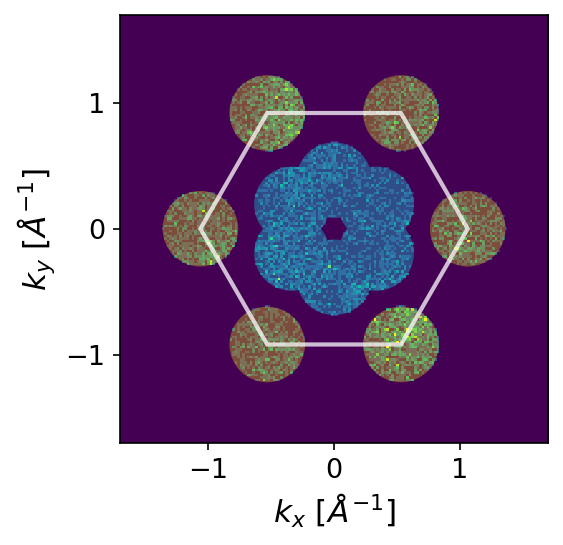

In [91]:
fig, ax = plt.subplots()
fig.set_size_inches(4,4)
fontsize = 15

# Mask off just K-Points and just GammaM-minima
masked_K = mpes.CircleMasks(I_res[2], k=vec_K1, radius=0.3, repeat=6)
masked_M = mpes.CircleMasks(I_res[2], k=vec_M1*0.42, radius=0.3, repeat=6)

# Plot both together
mask_total = masked_K + masked_M
mpes.plot_momentum_maps(mask_total, E=1.58, E_int=0.3, delays=0, delay_int=2000, fig=fig, ax=ax, fontsize=fontsize)

# Patch section
from matplotlib.patches import Circle, PathPatch
from matplotlib.path import Path

M_circles = []
K_circles = []
K_Points = [vec_K1, vec_K2, vec_K3, vec_K4, vec_K5, vec_K6]
M_Points = [vec_M1, vec_M2, vec_M3, vec_M4, vec_M5, vec_M6]
# Make one circle patch at every point
for vec_K, vec_M in zip(K_Points, M_Points):
    K_circles.append(Circle(xy=vec_K, radius=0.3, color='yellow', linewidth=0, alpha=0.3))
    M_circles.append(Circle(xy=vec_M*0.42, radius=0.3))

# Get transforms and paths for all M-Circle patches and add them together
transforms_M = []
vertices_M = []
transform_sum_M = []
path_sum_M = []
for i, circle in enumerate(M_circles):
    transforms_M.append(circle.get_patch_transform().transform)
    vertices_M.append(circle.get_path().vertices.copy())
    transform_sum_M += transforms_M[i](vertices_M[i]).tolist()
    path_sum_M += circle.get_path().codes.tolist()

# Combine the paths, create a PathPatch from the combined path
combined_path_M = Path(transform_sum_M, path_sum_M, )
combined_patch = PathPatch(combined_path_M, color='cyan', linewidth=0, alpha=0.3)
# Plot the combined M-Point patch
ax.add_patch(combined_patch)

# Plot every K-Point patch
for circle in K_circles:
    ax.add_patch(circle)

mpes.overlay_bz('hexagonal', a=3.95, b=3.95, ax=ax, color='white', rotation_deg=30)

ax.set_title('')
ax.set_xlim(-1.7,1.7)
ax.set_ylim(-1.7,1.7)
ax.tick_params(labelsize=fontsize-2)

#fig.savefig('./Figures/Thesis/CB-KM-Masks.pdf', bbox_inches='tight')

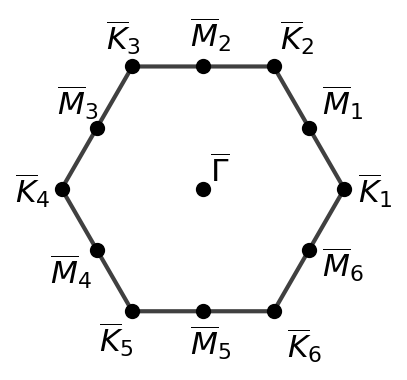

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(3,3)

lim = 1.3
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect(1)

mpes.overlay_bz('hexagonal', a=3.95, b=3.95, ax=ax, color='black', rotation_deg=30)

labels = [fr'$\overline{{\Gamma}}$', fr'$\overline{{K}}_{{1}}$', fr'$\overline{{M}}_{{1}}$', fr'$\overline{{K}}_{{2}}$', fr'$\overline{{M}}_{{2}}$'
          , fr'$\overline{{K}}_{{3}}$', fr'$\overline{{M}}_{{3}}$', fr'$\overline{{K}}_{{4}}$', fr'$\overline{{M}}_{{4}}$'
          , fr'$\overline{{K}}_{{5}}$', fr'$\overline{{M}}_{{5}}$', fr'$\overline{{K}}_{{6}}$', fr'$\overline{{M}}_{{6}}$']
offsets = [(0.05, 0.05),
           (0.1, -0.1), (0.1, 0.1),
           (0.05, 0.125), (-0.1, 0.15),
           (-0.2, 0.125), (-0.3, 0.1),
           (-0.35, -0.1), (-0.35, -0.25),
           (-0.25, -0.3), (-0.1, -0.325),
           (0.1, -0.35), (0.1, -0.2)]
for i, vec in enumerate([np.array([0,0]), vec_K1, vec_M1, vec_K2, vec_M2, vec_K3, vec_M3, vec_K4, vec_M4, vec_K5, vec_M5, vec_K6, vec_M6]):
    ax.scatter(vec[0], vec[1], color='black', s=40)
    ax.text(x=vec[0]+offsets[i][0], y=vec[1]+offsets[i][1], s=labels[i], size=15)

ax.axis('off')
#fig.savefig('./Figures/Thesis/BZ-Numbering.pdf', bbox_inches='tight')

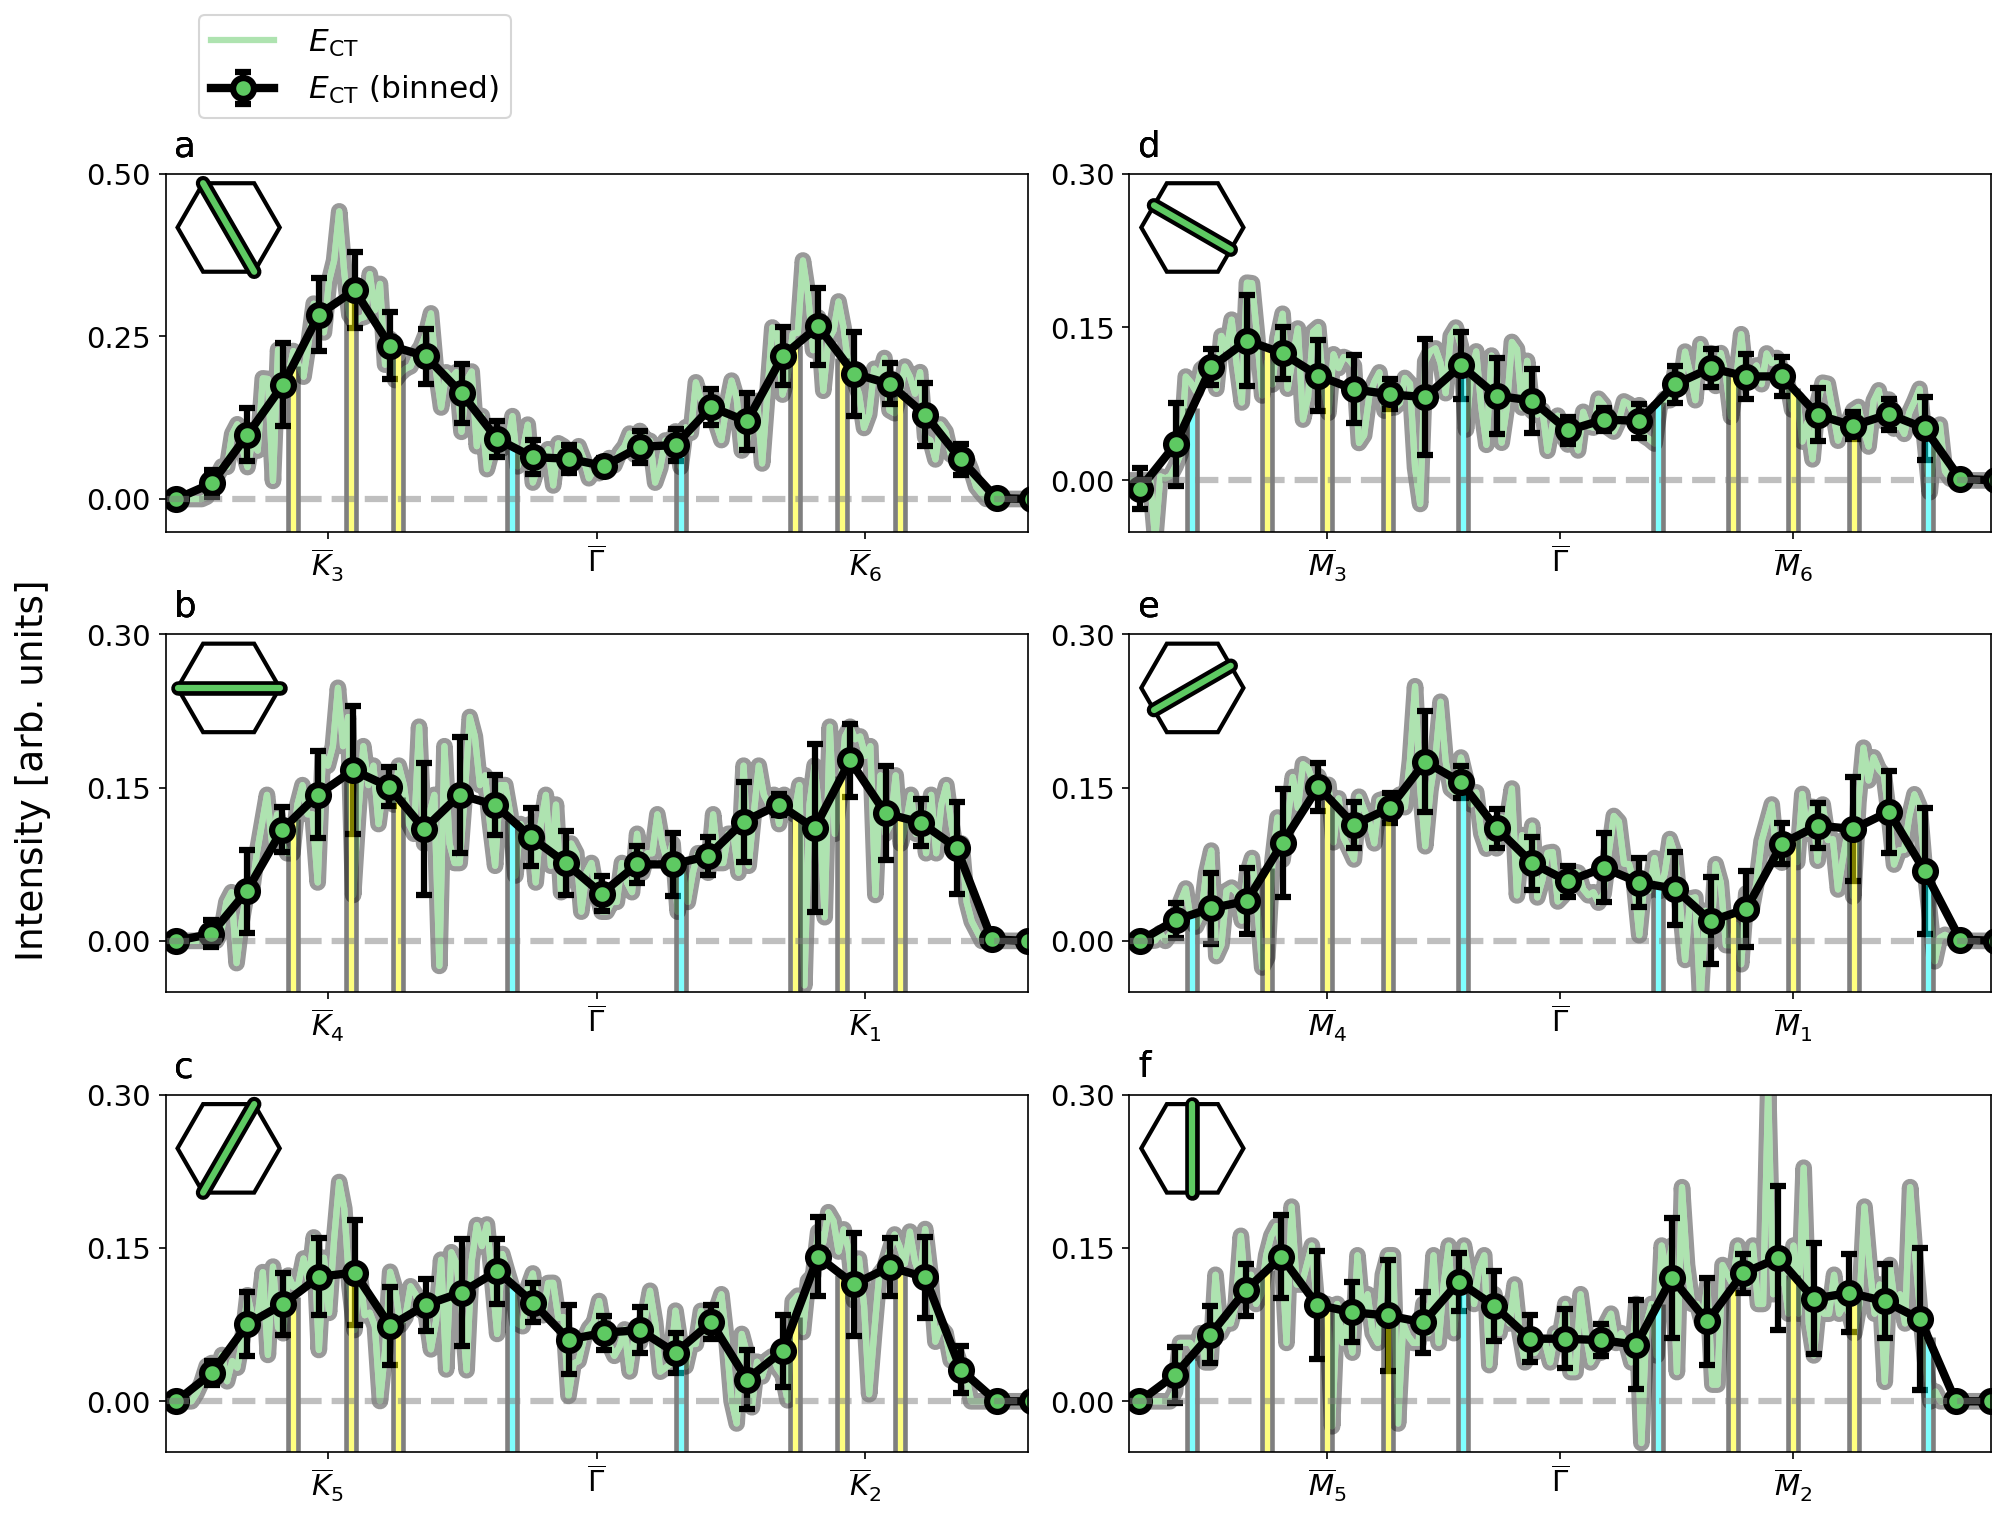

In [ ]:
from matplotlib.patches import RegularPolygon
fig, axs = plt.subplots(3,2)
axs = axs.flatten()
fig.set_size_inches(13,10)
fontsize = 15
colormap = mpl.colormaps['viridis']

# Load MDCs
mdc_K3GK6 = np.genfromtxt('./MDCs_CT/K3_G_K6_Diff.csv', delimiter=',')
mdc_M3GM6 = np.genfromtxt('./MDCs_CT/M3_G_M6_Diff.csv', delimiter=',')
mdc_K4GK1 = np.genfromtxt('./MDCs_CT/K4_G_K1_Diff.csv', delimiter=',')
mdc_M4GM1 = np.genfromtxt('./MDCs_CT/M4_G_M1_Diff.csv', delimiter=',')
mdc_K5GK2 = np.genfromtxt('./MDCs_CT/K5_G_K2_Diff.csv', delimiter=',')
mdc_M5GM2 = np.genfromtxt('./MDCs_CT/M5_G_M2_Diff.csv', delimiter=',')
diff_mdcs = [mdc_K3GK6, mdc_M3GM6, mdc_K4GK1, mdc_M4GM1, mdc_K5GK2, mdc_M5GM2]

# At one point I tried plotting VB MDCs as well to show they're very different, but that was too messy visually
mdc_VB_K3GK6 = np.genfromtxt('./MDCs_VBM/K3_G_K6.csv', delimiter=',')
mdc_VB_M3GM6 = np.genfromtxt('./MDCs_VBM/M3_G_M6.csv', delimiter=',')
mdc_VB_K4GK1 = np.genfromtxt('./MDCs_VBM/K4_G_K1.csv', delimiter=',')
mdc_VB_M4GM1 = np.genfromtxt('./MDCs_VBM/M4_G_M1.csv', delimiter=',')
mdc_VB_K5GK2 = np.genfromtxt('./MDCs_VBM/K5_G_K2.csv', delimiter=',')
mdc_VB_M5GM2 = np.genfromtxt('./MDCs_VBM/M5_G_M2.csv', delimiter=',')
VB_mdcs = [mdc_VB_K3GK6, mdc_VB_M3GM6, mdc_VB_K4GK1, mdc_VB_M4GM1, mdc_VB_K5GK2, mdc_VB_M5GM2]

# Projections of DFT Points onto MDC Directions
CBM_Gamma_dist = K_dist * 0.74
CBM_GM_dist = M_dist * 0.42
MK_dist = (2*np.pi) / (3*3.95)
MK_min = 0.35 * MK_dist

GK_min_2BZ = np.array([(np.cos(4*(np.pi/3)) * CBM_Gamma_dist) + (np.cos((np.pi/3)+(np.pi/6)) * 2 * M_dist),
                       (np.sin(4*(np.pi/3)) * CBM_Gamma_dist) + (np.sin((np.pi/3)+(np.pi/6)) * 2 * M_dist)])

normal = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])
GK_projection_2BZ = np.dot(GK_min_2BZ, normal)
normal_MGM = np.array([0,1])
GK_proj_2BZ_MGM = np.dot(GK_min_2BZ, normal_MGM)

GM_min_1BZ = np.array([(np.cos((np.pi/3) + (np.pi/6)) * CBM_GM_dist),
                      (np.sin((np.pi/3) + (np.pi/6)) * CBM_GM_dist)])

normal = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])
GM_projection_1BZ = np.dot(GM_min_1BZ, normal)

GK_min_1BZ = np.array([(np.cos(2*(np.pi/3)) * CBM_Gamma_dist), (np.sin(2*(np.pi/3)) * CBM_Gamma_dist)])
GK_proj_1BZ_MGM = np.dot(GK_min_1BZ, normal_MGM)

MK_min = np.array([(vec_K1[0] + MK_min * np.cos(2*np.pi/3)), (vec_K1[1] + MK_min * np.sin(2*np.pi/3))])
normal = np.array([1, 0])
MK_projection = np.dot(MK_min, normal)

normal_MGM2 = np.array([np.cos(np.pi/6), np.sin(np.pi/6)])
MK_proj_MGM = np.dot(MK_min, normal_MGM2)

vlines_GK = [-GK_projection_2BZ, -MK_projection, -CBM_Gamma_dist, -GM_projection_1BZ,
              GM_projection_1BZ, CBM_Gamma_dist, MK_projection, GK_projection_2BZ]
colors_GK = ['yellow', 'yellow', 'yellow', 'cyan', 'cyan', 'yellow', 'yellow', 'yellow']

CBM_GM_dist_2BZ = 2*M_dist - CBM_GM_dist
vlines_GM = [-CBM_GM_dist_2BZ, -GK_proj_2BZ_MGM, -MK_proj_MGM, -GK_proj_1BZ_MGM, -CBM_GM_dist,
              CBM_GM_dist, GK_proj_2BZ_MGM, MK_proj_MGM, GK_proj_1BZ_MGM, CBM_GM_dist_2BZ]
colors_GM = ['cyan', 'yellow', 'yellow', 'yellow', 'cyan', 'cyan', 'yellow', 'yellow', 'yellow', 'cyan']

def bin_mdc(mdc, bins):
    N = len(mdc[0])
    binned_k = []
    binned_I = []
    binned_I_err = []
    for i in range(int(np.floor(N/bins))):
        k_chunks = []
        I_chunks = []
        for j in range(bins):
            k_chunks.append(mdc[0][(bins*i)+j])
            I_chunks.append(mdc[1][(bins*i)+j])
    
        binned_k.append(np.mean(k_chunks))
        binned_I.append(np.mean(I_chunks))
        binned_I_err.append(np.std(I_chunks))
    
    return np.array([binned_k, binned_I, binned_I_err])

ax_labels = [[fr'$\overline{{K}}_{{3}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{K}}_{{6}}$'],
             [fr'$\overline{{M}}_{{3}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{M}}_{{6}}$'],
             [fr'$\overline{{K}}_{{4}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{K}}_{{1}}$'],
             [fr'$\overline{{M}}_{{4}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{M}}_{{1}}$'],
             [fr'$\overline{{K}}_{{5}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{K}}_{{2}}$'],
             [fr'$\overline{{M}}_{{5}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{M}}_{{2}}$']]

# Axis Formatting
xlim = (-1.7, 1.7)
ylims = [(-0.05, 0.5), (-0.05, 0.3), (-0.05, 0.3), (-0.05, 0.3), (-0.05, 0.3), (-0.05, 0.3)]
for i, ax in enumerate(axs):
    if i%2 == 0:
        ax.set_xticks([-K_dist, 0, K_dist], labels=ax_labels[i])
    else:
        ax.set_xticks([-M_dist, 0, M_dist], labels=ax_labels[i])
    ax.axhline(0, lw=3, color='grey', linestyle='dashed', alpha=0.5)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylims[i][0], ylims[i][1])
    if i == 0:
        ax.set_yticks([0, 0.25, 0.5])
    else:
        ax.set_yticks([0, 0.15, 0.3])
    ax.tick_params(labelsize=fontsize-1)
    ax.set_aspect(abs((xlim[1]-xlim[0])/(ylims[i][1]-ylims[i][0]))*0.415)


colors = ['black', 'white', colormap(0.75)]
colors_2 = ['black', 'white', colormap(0.99)]
alphas = [0.4, 1, 0.5]
alphas_2 = [0.6, 1, 0.7]
linewidths = [8, 3, 3]

bins = 7

panel_labels = ['a', 'd', 'b', 'e', 'c', 'f']

# Plot MDCs
for i, (alpha, alpha_2, lw) in enumerate(zip(alphas, alphas_2, linewidths)):
    for j, (diff_mdc, vb_mdc) in enumerate(zip(diff_mdcs, VB_mdcs)):
        axs[j].plot(diff_mdc[0], diff_mdc[1], color=colors[i], alpha=alpha, lw=lw, zorder=0)
        axs[j].annotate(panel_labels[j],(0.01,1.05), xycoords='axes fraction', fontsize=fontsize+2)
        if i == 2:
            binned_mdc = bin_mdc(diff_mdc, bins=bins)
            axs[j].errorbar(x=binned_mdc[0], y=binned_mdc[1], yerr=binned_mdc[2], fmt='o', lw=lw+1, ls='solid', ecolor='black', mec='black', mfc=colors[2], mew=lw,
                            color='black', capsize=lw+1, elinewidth=lw, ms=10, zorder=1)
            if j%2 == 0:
                for k, vline in enumerate(vlines_GK):
                    ymax = np.interp(vline, binned_mdc[0], binned_mdc[1])
                    axs[j].vlines(vline, ymin=-0.05, ymax=ymax, color='black', alpha=0.5, lw=7, zorder=0)
                    axs[j].vlines(vline, ymin=-0.05, ymax=ymax, color='white', alpha=1, lw=2.5, zorder=0)
                    axs[j].vlines(vline, ymin=-0.05, ymax=ymax, color=colors_GK[k], alpha=0.5, lw=2.5, zorder=1)
            else:
                for k, vline in enumerate(vlines_GM):
                    ymax = np.interp(vline, binned_mdc[0], binned_mdc[1])
                    axs[j].vlines(vline, ymin=-0.05, ymax=ymax, color='black', alpha=0.5, lw=7, zorder=0)
                    axs[j].vlines(vline, ymin=-0.05, ymax=ymax, color='white', alpha=1, lw=2.5, zorder=0)
                    axs[j].vlines(vline, ymin=-0.05, ymax=ymax, color=colors_GM[k], alpha=0.5, lw=2.5, zorder=1)
            #axs[j].plot(vb_mdc[0], 0.35*vb_mdc[1], color=colors_2[i], alpha=alpha_2, lw=lw, zorder=2)
        else:
            nothing = 0
            #axs[j].plot(vb_mdc[0], 0.35*vb_mdc[1], color=colors_2[i], alpha=alpha_2, lw=lw, zorder=1)

# Plot Brillouin Zone Patches with Line indicators for MDC-Direction
for i, ax in enumerate(axs):
    aspect = ax.get_aspect()
    ylim = ax.get_ylim()
    y_factor = (ylim[1]-ylim[0]) / (0.35)
    y_patch = ((ylim[1]-ylim[0]) * 0.85 + ylim[0]) / y_factor
    hexagon = RegularPolygon(xy=(-0.36,y_patch), numVertices=6, radius=0.05, orientation=np.pi/6, edgecolor='black', fill=False, lw=2, zorder=1)
    verts = hexagon.get_verts()
    hexagon.set_transform(mpl.transforms.Affine2D().scale(sx=aspect*y_factor, sy=y_factor) + ax.transData)
    ax.add_patch(hexagon)
    if i%2 == 0:
        index = int(np.floor(i/2))
        x1 = verts[index][0]*aspect*y_factor
        x2 = verts[index+3][0]*aspect*y_factor
        y1 = verts[index][1]*y_factor
        y2 = verts[index+3][1]*y_factor
    else:
        index = int(np.floor(i/2))
        x1 = (verts[index][0]*aspect*y_factor + verts[index+1][0]*aspect*y_factor) / 2
        x2 = (verts[index+3][0]*aspect*y_factor + verts[index+4][0]*aspect*y_factor) / 2
        y1 = (verts[index][1]*y_factor + verts[index+1][1]*y_factor) / 2
        y2 = (verts[index+3][1]*y_factor + verts[index+4][1]*y_factor) / 2
    ax.plot([x1, x2], [y1, y2], lw=3, zorder=1, color=colormap(0.75), solid_capstyle='round',
            path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=1), pe.Normal()])



# Dummy plots for legend
l1, = axs[0].plot(-100, -100, color=colors[2], alpha=alphas[2], lw=linewidths[2], label=fr' $E_{{\mathrm{{CT}}}}$')
l2 = axs[0].errorbar(x=-100, y=-100, yerr=5, fmt='o', lw=linewidths[2]+1, ls='solid', ecolor='black', mec='black', mfc=colors[2], mew=linewidths[2],
                            color='black', capsize=linewidths[2]+1, elinewidth=linewidths[2], ms=10, label=fr' $E_{{\mathrm{{CT}}}}$ (binned)')
l3, = axs[0].plot(-100, -100, color=colors_2[2], alpha=alphas_2[2], lw=linewidths[2], label=fr'-0.40 eV (rescaled)')


#axs[2].invert_xaxis()


axs[0].legend(fontsize=fontsize, handles=[l1, l2], bbox_to_anchor=(0.22,1.3), loc='center')
fig.text(-0.025, 0.5, 'Intensity [arb. units]', va='center', rotation='vertical', fontsize=fontsize+3)
fig.tight_layout()

#fig.savefig('./Figures/Thesis/MDC-CBM-newLegend.pdf', bbox_inches='tight')

Text(0.35, 1.1, '$+\\hbar\\omega_{\\mathrm{Pump}}$')

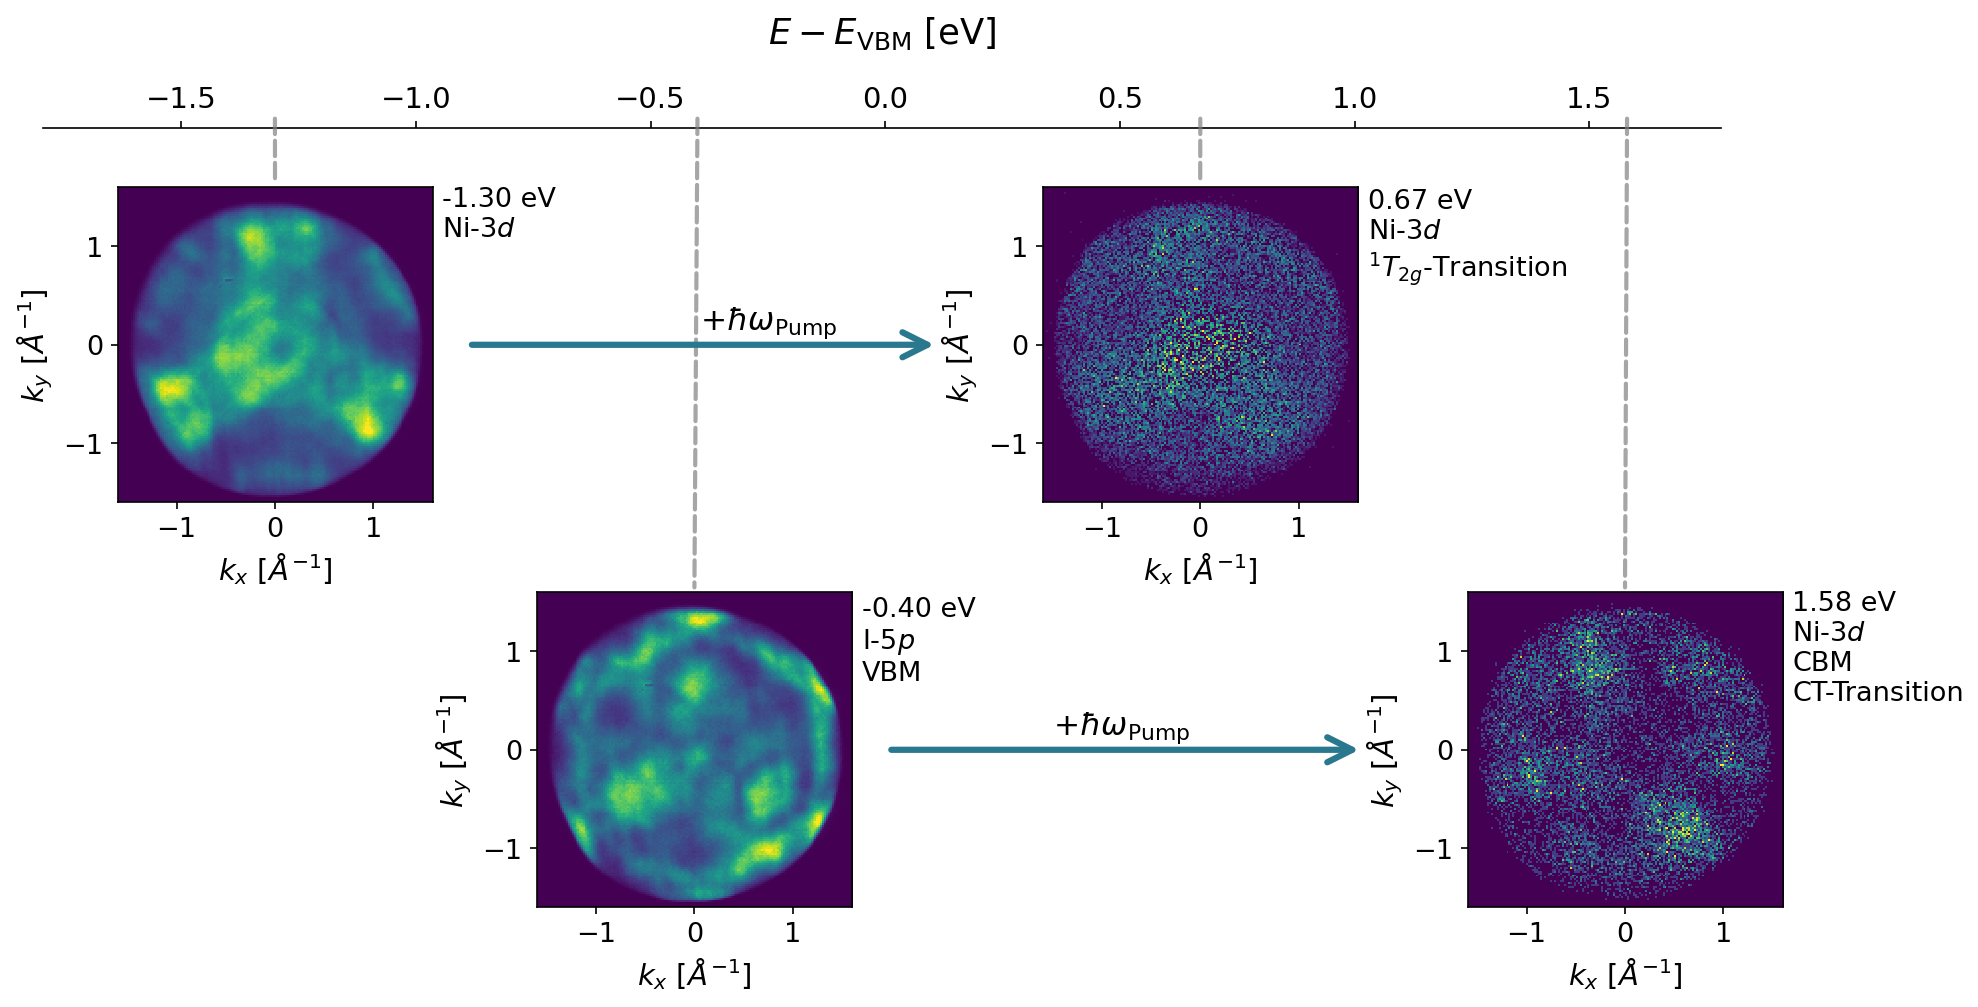

In [ ]:
from matplotlib import patches
fig, axs = plt.subplot_mosaic([
    ['E_ax','E_ax','E_ax','E_ax'],
    ['-1.3', '.', '0.75', '.'],
    ['.', '-0.4', '.', '1.58']
])
fig.set_size_inches(12,6)
fontsize = 15
colormap = mpl.colormaps['viridis']

# Plot Momentum Maps with colorscale adjusted for optimal visual contrast
mpes.plot_momentum_maps(I_res[2], E=-1.3, E_int=0.1, delays=0, delay_int=2000, fig=fig, ax=axs['-1.3'], scale=[0,0.95])
mpes.plot_momentum_maps(I_res[2], E=-0.4, E_int=0.1, delays=0, delay_int=2000, fig=fig, ax=axs['-0.4'], scale=[0,0.95])
mpes.plot_momentum_maps(I_diff[2], E=0.75, E_int=0.3, delays=0, delay_int=2000, fig=fig, ax=axs['0.75'], scale=[0,0.8])
mpes.plot_momentum_maps(I_diff[2], E=1.58, E_int=0.3, delays=0, delay_int=2000, fig=fig, ax=axs['1.58'], scale=[0,0.8])

# MM Axis Formatting
for ax in [axs['-1.3'], axs['-0.4'], axs['0.75'], axs['1.58']]:
    ax.set_title('')
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)

# Formatting of Energy Axis
axs['E_ax'].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, left=False, labelleft=False, labelsize=14)
axs['E_ax'].spines['bottom'].set_visible(False)
axs['E_ax'].spines['left'].set_visible(False)
axs['E_ax'].spines['right'].set_visible(False)
axs['E_ax'].set_xlim(-1.793,1.78)
axs['E_ax'].xaxis.set_label_position('top')
axs['E_ax'].set_xlabel(fr'$E-E_{{\mathrm{{VBM}}}}$ [eV]', fontsize=17, labelpad=20)

# Positioning of Momentum Maps in Figure Coordinates
axs['-1.3'].set_position((0,0.55,0.35,0.35))
axs['0.75'].set_position((0.514,0.55,0.35,0.35))
axs['-0.4'].set_position((0.233,0.1,0.35,0.35))
axs['1.58'].set_position((0.75,0.1,0.35,0.35))

# Lines Connecting MMs with Energy Axis
arrow_m13 = patches.ConnectionPatch([-1.3, 1.05], [0, 1.65], coordsA=axs['E_ax'].transData, coordsB=axs['-1.3'].transData, color='grey', arrowstyle='-', linestyle='dashed', linewidth=2, alpha=0.7)
arrow_m04 = patches.ConnectionPatch([-0.4, 1.05], [0, 1.65], coordsA=axs['E_ax'].transData, coordsB=axs['-0.4'].transData, color='grey', arrowstyle='-', linestyle='dashed', linewidth=2, alpha=0.7)
arrow_p07 = patches.ConnectionPatch([0.671, 1.05], [0, 1.65], coordsA=axs['E_ax'].transData, coordsB=axs['0.75'].transData, color='grey', arrowstyle='-', linestyle='dashed', linewidth=2, alpha=0.7)
arrow_p15 = patches.ConnectionPatch([1.58, 1.05], [0, 1.65], coordsA=axs['E_ax'].transData, coordsB=axs['1.58'].transData, color='grey', arrowstyle='-', linestyle='dashed', linewidth=2, alpha=0.7)
fig.patches.append(arrow_m13)
fig.patches.append(arrow_m04)
fig.patches.append(arrow_p07)
fig.patches.append(arrow_p15)

# MM Annotations
axs['-1.3'].annotate(fr'-1.30 eV{'\n'}Ni-3$d$', xy=(1.7, 1.1), annotation_clip=False, color='black', fontsize=fontsize-2)
axs['-0.4'].annotate(fr'-0.40 eV{'\n'}I-5$p${'\n'}VBM', xy=(1.7, 0.7), annotation_clip=False, color='black', fontsize=fontsize-2)
axs['0.75'].annotate(fr'0.67 eV{'\n'}Ni-3$d${'\n'}$^{{1}}T_{{2g}}$-Transition', xy=(1.7, 0.7), annotation_clip=False, color='black', fontsize=fontsize-2)
axs['1.58'].annotate(fr'1.58 eV{'\n'}Ni-3$d${'\n'}CBM{'\n'}CT-Transition', xy=(1.7, 0.5), annotation_clip=False, color='black', fontsize=fontsize-2)

# Arrows between VB and excited-state MMs
arrow_dd = patches.ConnectionPatch([2,0], [-2.7,0], coordsA=axs['-1.3'].transData, coordsB=axs['0.75'].transData, color=colormap(0.4), arrowstyle='->', linewidth=3, mutation_scale=30)
fig.patches.append(arrow_dd)
arrow_CT = patches.ConnectionPatch([2,0], [-2.7,0], coordsA=axs['-0.4'].transData, coordsB=axs['1.58'].transData, color=colormap(0.4), arrowstyle='->', linewidth=3, mutation_scale=30)
fig.patches.append(arrow_CT)
axs['-1.3'].annotate(fr'$+\hbar\omega_{{\mathrm{{Pump}}}}$', xycoords=arrow_dd, xy=(0.5,1.1), fontsize=15)
axs['-0.4'].annotate(fr'$+\hbar\omega_{{\mathrm{{Pump}}}}$', xycoords=arrow_CT, xy=(0.35,1.1), fontsize=15)

#fig.savefig('./Figures/Thesis/Transition_Scheme.pdf', bbox_inches='tight')

Text(0.5, 1.0, '')

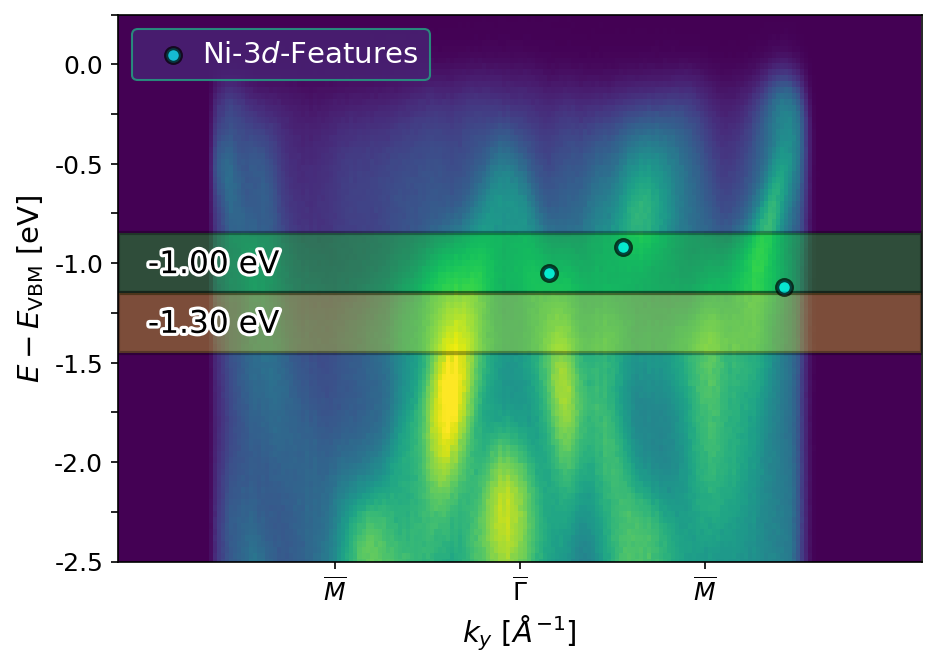

In [ ]:
fig, ax = plt.subplots()

mpes.plot_ky_frame(I_res[2], kx=0, kx_int=0.2, delays=0, delay_int=2000, fig=fig, ax=ax, energy_limits=(-2.5,0.25), E_enhance=-4, scale=[0,0.9])
ax.set_xticks([-M_dist, 0, M_dist], labels=[fr'$\overline{{M}}$', fr'$\overline{{\Gamma}}$', fr'$\overline{{M}}$'])

E_HeII = [-1.12, -1.05, -0.92]
k_HeII = [(2-0.57)*M_dist, 0.16*M_dist, 0.56*M_dist]

# Energy integration ranges used in later figure
mpes.add_rect(0,4, -1, 0.3, ax=ax, edgecolor='black', facecolor='lime', linewidth=2, alpha=0.3)
mpes.add_rect(0,4, -1.3, 0.3, ax=ax, edgecolor='black', facecolor='yellow', linewidth=2, alpha=0.3)

# Ni-3d-Features reported by 1986 ARPES study of NiI2
ax.scatter(k_HeII, E_HeII, edgecolors='black', c='cyan', alpha=0.7, lw=2, s=50, label=fr'Ni-$3d$-Features')

ax.text(x=-1.85, y=-1.05, s=fr'-1.00 eV', color='black',
        path_effects=[pe.Stroke(linewidth=3, foreground='white', alpha=1), pe.Normal()], size=15)
ax.text(x=-1.85, y=-1.35, s=fr'-1.30 eV', color='black',
        path_effects=[pe.Stroke(linewidth=3, foreground='white', alpha=1), pe.Normal()], size=15)
ax.legend(labelcolor='white', edgecolor=colormap(0.6), facecolor=colormap(0.1), loc='upper left', fontsize=14, handletextpad=0)
ax.set_title('')

#fig.savefig('./Figures/Thesis/kyFrame-Ni3d.pdf', bbox_inches='tight')

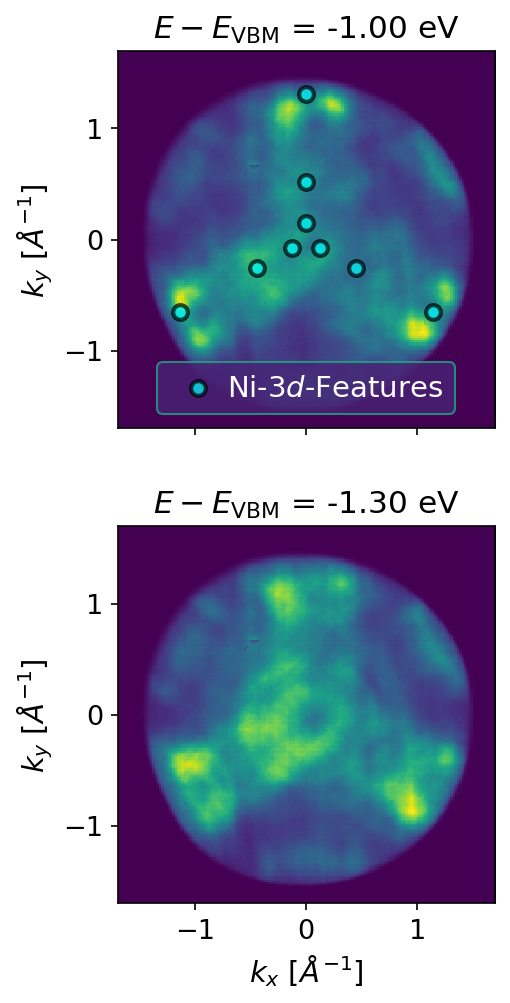

In [ ]:
fig, axs = plt.subplots(2,1, sharex=True)
fig.set_size_inches(3.5,7)
mpes.plot_momentum_maps(I_res[2], E=-1, E_int=0.3, fig=fig, ax=axs[0])
#mpes.overlay_bz('hexagonal', a=3.95, b=3.95, ax=axs[0], color='white', rotation_deg=30, repeat=1)
mpes.plot_momentum_maps(I_res[2], E=-1.3, E_int=0.3, fig=fig, ax=axs[1])

# Plot Features that get enhanced with He-II Line
points_kx = []
points_ky = []
for i in range(3):
    point = np.array([np.cos(i*(2*np.pi/3) + (np.pi/2)), np.sin(i*(2*np.pi/3) + (np.pi/2))])
    Off_Gamma = point * 0.16 * M_dist
    GammaM_1BZ = point * 0.56 * M_dist
    GammaM_2BZ = point * (2-0.57) * M_dist
    for test_point in [Off_Gamma, GammaM_1BZ, GammaM_2BZ]:
        points_kx.append(test_point[0])
        points_ky.append(test_point[1])


axs[0].scatter(points_kx, points_ky, edgecolors='black', c='cyan', alpha=0.7, lw=2, s=50, label=fr'Ni-$3d$-Features')
axs[0].set_xlabel('')

for ax in axs:
    ax.set_xlim(-1.7,1.7)
    ax.set_ylim(-1.7,1.7)

axs[0].set_title(fr'$E-E_{{\mathrm{{VBM}}}}$ = -1.00 eV', fontsize=15)
axs[1].set_title(fr'$E-E_{{\mathrm{{VBM}}}}$ = -1.30 eV', fontsize=15)

colormap = mpl.colormaps['viridis']
axs[0].legend(labelcolor='white', edgecolor=colormap(0.6), facecolor=colormap(0.1), loc='lower center', fontsize=14, handletextpad=0)
fig.tight_layout()

#fig.savefig('./Figures/Thesis/MM-Ni3d.pdf', bbox_inches='tight')

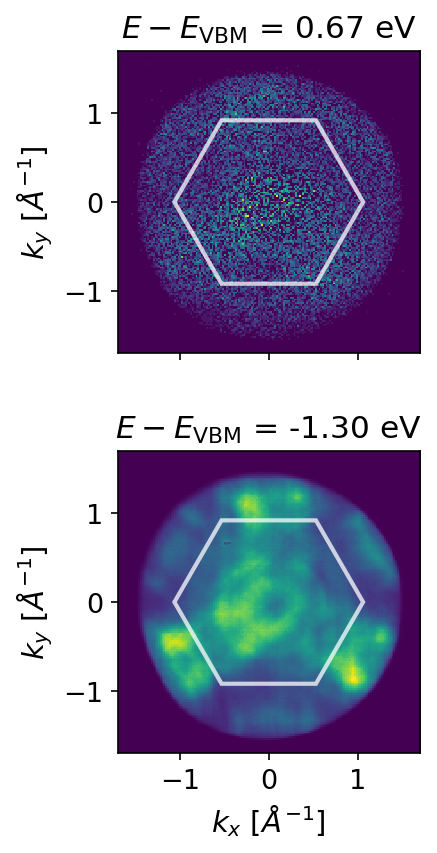

In [ ]:
fig, axs = plt.subplots(2,1, sharex=True)
fig.set_size_inches(3,6)
mpes.plot_momentum_maps(I_diff[2], E=0.75, E_int=0.3, fig=fig, ax=axs[0])
mpes.overlay_bz('hexagonal', a=3.95, b=3.95, ax=axs[0], color='white', rotation_deg=30)
mpes.plot_momentum_maps(I_res[2], E=-1.3, E_int=0.3, fig=fig, ax=axs[1])
mpes.overlay_bz('hexagonal', a=3.95, b=3.95, ax=axs[1], color='white', rotation_deg=30)

axs[0].set_xlabel('')

for ax in axs:
    ax.set_xlim(-1.7,1.7)
    ax.set_ylim(-1.7,1.7)

axs[0].set_title(fr'$E-E_{{\mathrm{{VBM}}}}$ = 0.67 eV', fontsize=15)
axs[1].set_title(fr'$E-E_{{\mathrm{{VBM}}}}$ = -1.30 eV', fontsize=15)

colormap = mpl.colormaps['viridis']
fig.tight_layout()

#fig.savefig('./Figures/Thesis/MM-ddTrans-Upright.pdf', bbox_inches='tight')

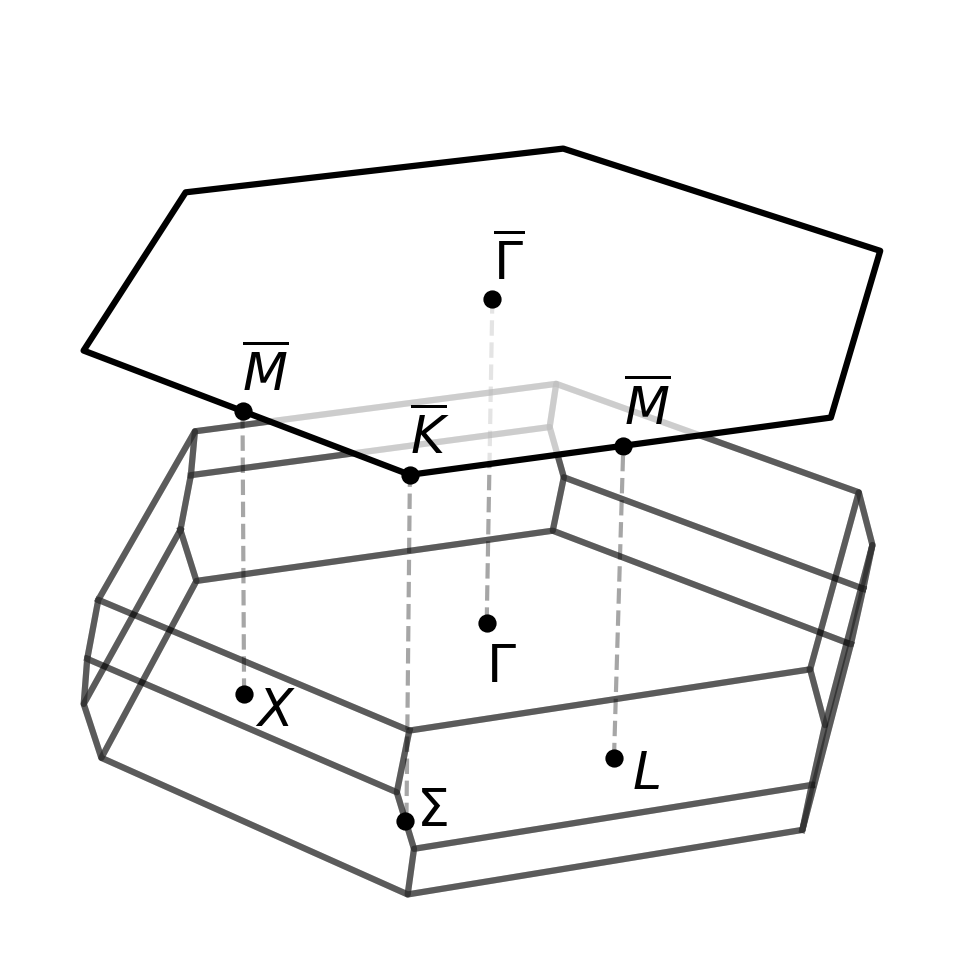

In [7]:
# Plotting 3D BZ via Voronoi Decomposition
# Code for Voronoi Decomposition by Prof. Dr. Qijing Zheng
# https://qijingzheng.github.io/posts/howto-plot-brillouin-zone/

def get_bz(cell):
    cell = np.asarray(cell, dtype=float)
    assert cell.shape == (3,3)

    px, py, pz = np.tensordot(cell, np.mgrid[-1:2, -1:2, -1:2], axes=[0, 0])
    points = np.c_[px.ravel(), py.ravel(), pz.ravel()]

    from scipy.spatial import Voronoi
    vor = Voronoi(points)

    bz_facets = []
    bz_ridges = []
    bz_vertices = []

    for pid, rid in zip(vor.ridge_points, vor.ridge_vertices):
        if (pid[0] == 13 or pid[1] == 13):
            bz_ridges.append(vor.vertices[np.r_[rid, rid[0]]])
            bz_facets.append(vor.vertices[rid])
            bz_vertices += rid
    
    bz_vertices = list(set(bz_vertices))

    return vor.vertices[bz_vertices], bz_ridges, bz_facets

# Lattice Parameters of NiI2 in conventional (hexagonal) unit cell
a = 21
c = 3.95
# Primitive (rhombohedral) unit cell of NiI2
cell_nii2 = np.array([[a/2, -a*np.sqrt(3)/6, c/3],
                      [0, a/np.sqrt(3), c/3],
                      [-a/2, -a*np.sqrt(3)/6, c/3]])

inv_cell = np.linalg.inv(cell_nii2).T
b1, b2, b3 = np.linalg.norm(inv_cell, axis=1)

v, e, f = get_bz(cell_nii2)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='3d', computed_zorder=False)
colormap = mpl.colormaps['viridis']

for xx in e:
    ax.plot(xx[:, 0], xx[:, 1], xx[:, 2]-4, color='black', alpha=0.4, lw=3, zorder=1)

markersize = 60
# Plot L and X Points (= M-Points pre-projection)
# Indices: 4=Rectangle in front bottom ; 8=Sixpointed Face in front top ; 9=Hexagon top ; 12=Rectangle in front top
indices = [8, 12]
for index in indices:
    N = len(f[index])
    x = 0
    y = 0
    z = 0
    for j in range(N):
        x += f[index][j][0]
        y += f[index][j][1]
        z += f[index][j][2]
    x = x/N
    y = y/N
    z = z/N
    ax.scatter(x, y, z-4, color='black', s=markersize, zorder=2)
    
    if index == 8:
        x_1, y_1, z_1 = x, y, z # Save coordinates to draw 2D hexagon later
        ax.text(x,y+0.5, z-5, fr'$L$', size=25)
    if index == 12:
        ax.text(x,y+0.25, z-4.9, fr'$X$', size=25)

#K-Point pre-projection
test_index = 8
x_K = (f[test_index][4][0] + f[test_index][5][0]) / 2
y_K = (f[test_index][4][1] + f[test_index][5][1]) / 2
z_K = (f[test_index][4][2] + f[test_index][5][2]) / 2
ax.scatter(x_K, y_K, z_K-4, color='black', s=markersize, zorder=2)
ax.text(x_K,y_K+0.25,z_K-4.25, fr'$\Sigma$', size=25)

#Gamma Point in center of BZ
ax.scatter(0, 0, -4, color='black', s=markersize, zorder=2)
ax.text(0,0,-5.5, fr'$\Gamma$', size=25)

# Get Points for Hexagon, plot projection lines, and label high-symmetry points
hexagon_x = []
hexagon_y = []
hexagon_z = []
for i in range(7):
    angle = (i*np.pi / 3) - (np.pi/6)
    x = (2/np.sqrt(3)) * (x_1 * np.cos(angle) - y_1 * np.sin(angle))
    y = (2/np.sqrt(3)) * (x_1 * np.sin(angle) + y_1 * np.cos(angle))
    hexagon_x.append(x)
    hexagon_y.append(y)
    hexagon_z.append(4)
    if i == 0:
        # K Point
        ax.plot([x, x], [y, y], [z_K-4, 4], ls='dashed', color='grey', lw=2, alpha=0.7, zorder=0)
        ax.scatter(x, y, 4, s=markersize, color='black', zorder=3)
        ax.text(x,y,4.5, fr'$\overline{{K}}$', size=25)
        # M Point 1 (Projection of L)
        M_x = (x_1 * np.cos(angle+(np.pi/6)) - y_1 * np.sin(angle+(np.pi/6)))
        M_y = (x_1 * np.sin(angle+(np.pi/6)) + y_1 * np.cos(angle+(np.pi/6)))
        ax.plot([M_x, M_x], [M_y, M_y], [-3.342, 4], ls='dashed', color='grey', lw=2, alpha=0.7, zorder=0)
        ax.scatter(M_x, M_y, 4, s=markersize, color='black', zorder=3)
        ax.text(M_x, M_y,4.5, fr'$\overline{{M}}$', size=25)
        # M Point 2 (Projection of X)
        M_x = (x_1 * np.cos(angle-(np.pi/6)) - y_1 * np.sin(angle-(np.pi/6)))
        M_y = (x_1 * np.sin(angle-(np.pi/6)) + y_1 * np.cos(angle-(np.pi/6)))
        ax.plot([M_x, M_x], [M_y, M_y], [-2.683, 4], ls='dashed', color='grey', lw=2, alpha=0.7, zorder=0)
        ax.scatter(M_x, M_y, 4, s=markersize, color='black', zorder=3)
        ax.text(M_x, M_y,4.5, fr'$\overline{{M}}$', size=25)

# Plot Hexagon
ax.plot(hexagon_x, hexagon_y, hexagon_z, color='black', alpha=1, lw=3, zorder=3)

# Plot Projected Gamma Point
ax.plot([0, 0], [0, 0], [-4, 4], ls='dashed', color='grey', lw=2, alpha=0.7, zorder=0)
ax.scatter(0, 0, 4, s=markersize, color='black', zorder=3)
ax.text(0, 0, 4.5, fr'$\overline{{\Gamma}}$', size=25)


# Add white patch to the hexagon for shading
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
verts = [list(zip(hexagon_x, hexagon_y, hexagon_z))]
hex_polygon = Poly3DCollection(verts, linewidth=0, alpha=0.7, color='white', edgecolor=None, zorder=2)
ax.add_collection3d(hex_polygon)

# Formatting
lim = 5
ax.set_xlim(-lim,lim)
ax.set_ylim(-lim,lim)
ax.set_zlim(-lim,lim)
ax.axis('off')
ax.view_init(roll=-1, azim=-50, elev=25)

#fig.savefig('./Figures/Thesis/BZ-projection_v2.pdf', bbox_inches='tight')

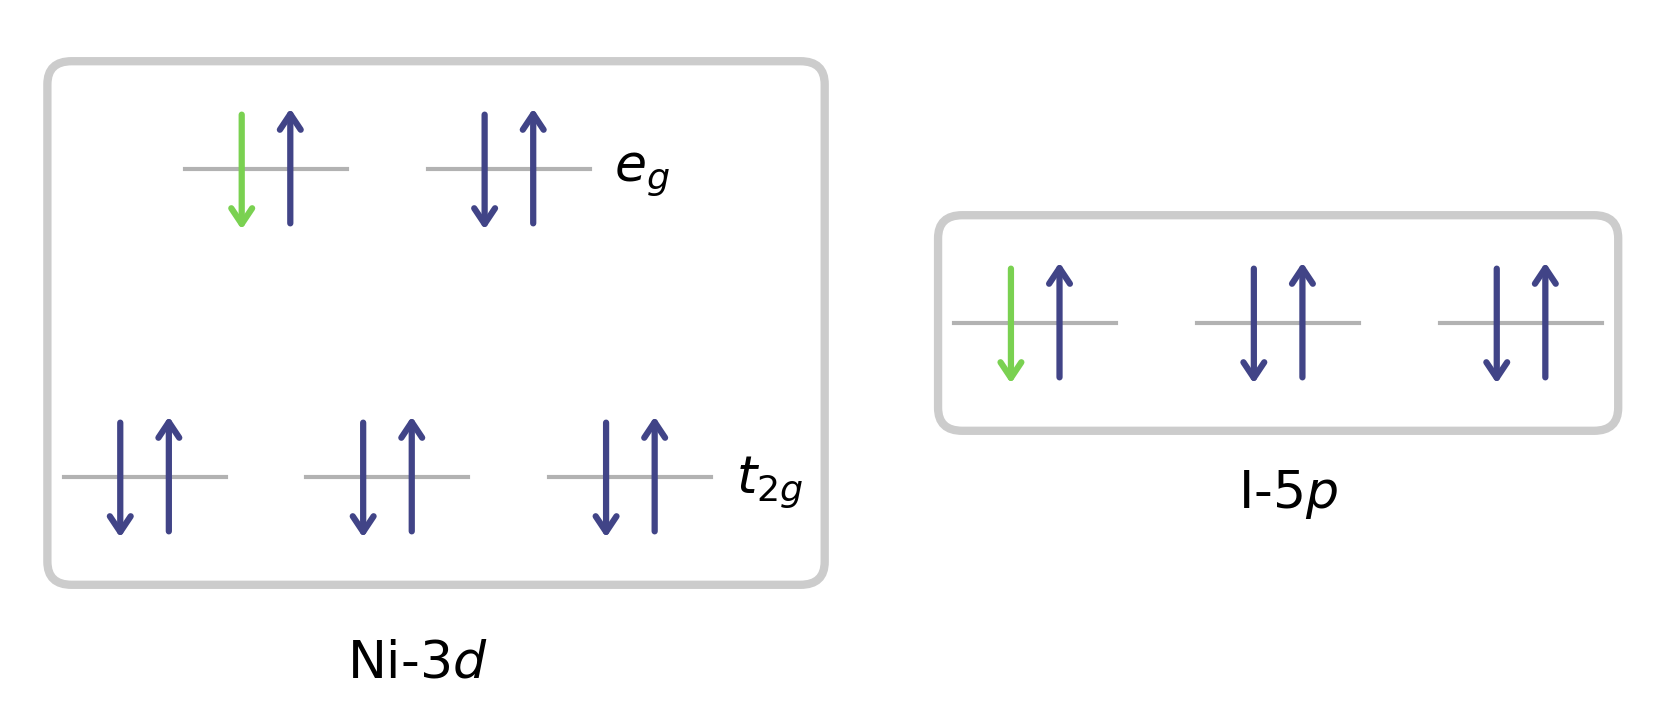

In [ ]:
from matplotlib.patches import ConnectionStyle, FancyBboxPatch

fig, ax = plt.subplots()
fig.set_size_inches(14,6)

colormap = mpl.colormaps['viridis']
colors = colormap(np.linspace(0.2,0.8,2))

# Grey lines for energy levels
levels_x = [np.linspace(-40,-20,2), np.linspace(-10,10,2), np.linspace(20,40,2), np.linspace(-25,-5,2), np.linspace(5,25,2)]
levels_y = [np.linspace(0,0,2), np.linspace(0,0,2), np.linspace(0,0,2), np.linspace(2,2,2), np.linspace(2,2,2)]

levels_I_x = [np.linspace(70,90,2), np.linspace(100,120,2), np.linspace(130,150,2)]
levels_I_y = np.linspace(1,1,2)

# Define functions that draw electrons onto energy levels
def AddArrow(level, spin, color, alpha, lw, ls):
    if spin == 'Up':
        x = (levels_x[level][0]+levels_x[level][1])/2 + 3
        y_pos = levels_y[level][0] + 0.42
        y_neg = levels_y[level][0] - 0.38
        ax.annotate('', xy=(x, y_pos), xytext=(x, y_neg), arrowprops=dict(arrowstyle=('->, head_length=0.75, head_width=0.5'), color=color, alpha=alpha, linewidth=lw, linestyle=ls))
    elif spin == 'Down':
        x = (levels_x[level][0]+levels_x[level][1])/2 - 3
        y_pos = levels_y[level][0] + 0.38
        y_neg = levels_y[level][0] - 0.42
        ax.annotate('', xy=(x, y_pos), xytext=(x, y_neg), arrowprops=dict(arrowstyle='<-, head_length=0.75, head_width=0.5', color=color, alpha=alpha, linewidth=lw, linestyle=ls))

def AddArrow_I(level, spin, color, alpha, lw, ls):
    if spin == 'Up':
        x = (levels_I_x[level][0]+levels_I_x[level][1])/2 + 3
        y_pos = levels_I_y[0] + 0.42
        y_neg = levels_I_y[0] - 0.38
        ax.annotate('', xy=(x, y_pos), xytext=(x, y_neg), arrowprops=dict(arrowstyle=('->, head_length=0.75, head_width=0.5'), color=color, alpha=alpha, linewidth=lw, linestyle=ls))
    if spin == 'Down':
        x = (levels_I_x[level][0]+levels_I_x[level][1])/2 - 3
        y_pos = levels_I_y[0] + 0.38
        y_neg = levels_I_y[0] - 0.42
        ax.annotate('', xy=(x, y_pos), xytext=(x, y_neg), arrowprops=dict(arrowstyle='<-, head_length=0.75, head_width=0.5', color=color, alpha=alpha, linewidth=lw, linestyle=ls))

# Draw energy levels
for x, y in zip(levels_x, levels_y):
    ax.plot(x,y, color='black', lw=2, alpha=0.3)

for x in levels_I_x:
    ax.plot(x, levels_I_y, color='black', lw=2, alpha=0.3)

# Formatting
ax.set_ylim(-1.5,3)
ax.set_xlim(-46, 155)
ax.axis('off')

ax.annotate(fr'$t_{{2g}}$', (43, -0.1), fontsize=25)
ax.annotate(fr'$e_{{g}}$', (28, 1.925), fontsize=25)

# Various Electron configurations
Ground_d8 = [(0, 'Down', 1, 'solid', colors[0]),
             (0, 'Up', 1, 'solid', colors[0]),
             (1, 'Down', 1, 'solid', colors[0]),
             (1, 'Up', 1, 'solid', colors[0]),
             (2, 'Down', 1, 'solid', colors[0]),
             (2, 'Up', 1, 'solid', colors[0]),
             (3, 'Down', 1, 'solid', colors[1]),
             (3, 'Up', 1, 'solid', colors[0]),
             (4, 'Down', 1, 'solid', colors[1]),
             (4, 'Up', 1, 'solid', colors[0])]

Ground_d9L = [(0, 'Down', 1, 'solid', colors[0]),
              (0, 'Up', 1, 'solid', colors[0]),
              (1, 'Down', 1, 'solid', colors[0]),
              (1, 'Up', 1, 'solid', colors[0]),
              (2, 'Down', 1, 'solid', colors[0]),
              (2, 'Up', 1, 'solid', colors[0]),
              (3, 'Down', 1, 'solid', colors[1]),
              (3, 'Up', 1, 'solid', colors[0]),
              (4, 'Down', 1, 'solid', colors[0]),
              (4, 'Up', 1, 'solid', colors[0])]

Excited_1T2g = [(0, 'Down', 1, 'solid', colors[0]),
                (0, 'Up', 1, 'solid', colors[1]),
                (1, 'Down', 1, 'solid', colors[0]),
                (1, 'Up', 1, 'solid', colors[0]),
                (2, 'Down', 1, 'solid', colors[0]),
                (2, 'Up', 1, 'solid', colors[0]),
                (3, 'Down', 1, 'solid', colors[0]),
                (3, 'Up', 1, 'solid', colors[0]),
                (4, 'Down', 1, 'solid', colors[1]),
                (4, 'Up', 1, 'solid', colors[0])]

Excited_3T1g = [(0, 'Down', 1, 'solid', colors[1]),
                (0, 'Up', 1, 'solid', colors[0]),
                (1, 'Down', 1, 'solid', colors[0]),
                (1, 'Up', 1, 'solid', colors[0]),
                (2, 'Down', 1, 'solid', colors[0]),
                (2, 'Up', 1, 'solid', colors[0]),
                (3, 'Down', 1, 'solid', colors[0]),
                (3, 'Up', 1, 'solid', colors[0]),
                (4, 'Down', 1, 'solid', colors[1]),
                (4, 'Up', 1, 'solid', colors[0])]

A1g_d9L = [(0, 'Down', 1, 'solid', colors[0]),
              (0, 'Up', 1, 'solid', colors[0]),
              (1, 'Down', 1, 'solid', colors[0]),
              (1, 'Up', 1, 'solid', colors[0]),
              (2, 'Down', 1, 'solid', colors[0]),
              (2, 'Up', 1, 'solid', colors[0]),
              (3, 'Down', 1, 'solid', colors[0]),
              (3, 'Up', 1, 'solid', colors[1]),
              (4, 'Down', 1, 'solid', colors[0]),
              (4, 'Up', 1, 'solid', colors[0])]

A1g_d8 = [(0, 'Down', 1, 'solid', colors[0]),
          (0, 'Up', 1, 'solid', colors[0]),
          (1, 'Down', 1, 'solid', colors[0]),
          (1, 'Up', 1, 'solid', colors[0]),
          (2, 'Down', 1, 'solid', colors[0]),
          (2, 'Up', 1, 'solid', colors[0]),
          (3, 'Down', 1, 'solid', colors[0]),
          (3, 'Up', 1, 'solid', colors[1]),
          (4, 'Down', 1, 'solid', colors[1]),
          (4, 'Up', 1, 'solid', colors[0])]

d_Full = [(0, 'Down', 1, 'solid', colors[0]),
              (0, 'Up', 1, 'solid', colors[0]),
              (1, 'Down', 1, 'solid', colors[0]),
              (1, 'Up', 1, 'solid', colors[0]),
              (2, 'Down', 1, 'solid', colors[0]),
              (2, 'Up', 1, 'solid', colors[0]),
              (3, 'Down', 1, 'solid', colors[0]),
              (3, 'Up', 1, 'solid', colors[0]),
              (4, 'Down', 1, 'solid', colors[0]),
              (4, 'Up', 1, 'solid', colors[0])]



Iodine_full =[(0, 'Down', 1, 'solid', colors[0]),
              (0, 'Up', 1, 'solid', colors[0]),
              (1, 'Down', 1, 'solid', colors[0]),
              (1, 'Up', 1, 'solid', colors[0]),
              (2, 'Down', 1, 'solid', colors[0]),
              (2, 'Up', 1, 'solid', colors[0])]

Iodine_d9L =[(0, 'Down', 1, 'solid', colors[1]),
             (0, 'Up', 1, 'solid', colors[0]),
             (1, 'Down', 1, 'solid', colors[0]),
             (1, 'Up', 1, 'solid', colors[0]),
             (2, 'Down', 1, 'solid', colors[0]),
             (2, 'Up', 1, 'solid', colors[0])]

Iodine_CT =[(0, 'Down', 1, 'solid', colors[1]),
             (0, 'Up', 1, 'solid', colors[1]),
             (1, 'Down', 1, 'solid', colors[0]),
             (1, 'Up', 1, 'solid', colors[0]),
             (2, 'Down', 1, 'solid', colors[0]),
             (2, 'Up', 1, 'solid', colors[0])]

Iodine_ZRS = [(0, 'Down', 1, 'solid', colors[0]),
              (0, 'Up', 1, 'solid', colors[1]),
              (1, 'Down', 1, 'solid', colors[0]),
              (1, 'Up', 1, 'solid', colors[0]),
              (2, 'Down', 1, 'solid', colors[0]),
              (2, 'Up', 1, 'solid', colors[0])]

# Progression from ZRT to ZRS via 1A1g transition (mostly not used in thesis)
ZRT_ZRS = [[Ground_d9L, Iodine_d9L],
           [A1g_d9L, Iodine_d9L],
           [d_Full, Iodine_CT],
           [Ground_d9L, Iodine_ZRS]]

stage = 0

# Draw electron arrows
for arrow in ZRT_ZRS[stage][0]:
    AddArrow(arrow[0], spin=arrow[1], color=arrow[4], alpha=arrow[2], lw=3, ls=arrow[3])
    
for arrow in ZRT_ZRS[stage][1]:
    AddArrow_I(arrow[0], spin=arrow[1], color=arrow[4], alpha=arrow[2], lw=3, ls=arrow[3])

# Draw Boxes around arrow diagrams
Ni_Box = FancyBboxPatch((-2,-0.6), width=4.6, height=3.2, boxstyle='round, pad=0.1, rounding_size=0.15', edgecolor='black', fill=False, alpha=0.2, linewidth=4,
                        transform=mpl.transforms.Affine2D().scale(sx=20, sy=1)+ax.transData)
ax.add_patch(Ni_Box)
I_Box = FancyBboxPatch((3.5,0.4), width=4, height=1.2, boxstyle='round, pad=0.1, rounding_size=0.15', edgecolor='black', fill=False, alpha=0.2, linewidth=4,
                        transform=mpl.transforms.Affine2D().scale(sx=20, sy=1)+ax.transData)
ax.add_patch(I_Box)
ax.annotate(fr'Ni-3$d$', xy=(-5,-1.3), fontsize=25)
ax.annotate(fr'I-5$p$', xy=(105,-0.2), fontsize=25)

# Arrows showing electron transitions for ZRT-ZRS transition (not used in thesis)
ZRT_ZTS_arrows = [[(-12, 1.55), (-18, 1.6), dict(arrowstyle='<|-', connectionstyle=ConnectionStyle('angle3', angleA=-60, angleB=60), linewidth=1.5, color='black')],
                  [(83, 0.55), (-12, 1.6), dict(arrowstyle='<|-', connectionstyle=ConnectionStyle('angle3', angleA=-35, angleB=15), linewidth=1.5, color='black')],
                  [(77, 0.6), (-18, 1.55), dict(arrowstyle='-|>', connectionstyle=ConnectionStyle('angle3', angleA=-25, angleB=25), linewidth=1.5, color='black')]]

if stage > 0:
    index = stage - 1
    ax.annotate('', ZRT_ZTS_arrows[index][0], ZRT_ZTS_arrows[index][1], arrowprops=ZRT_ZTS_arrows[index][2])


#ax.annotate('', (-34, 0.4), (-20, 1.65), arrowprops=dict(arrowstyle='<|-', connectionstyle=ConnectionStyle('angle3', angleA=20, angleB=-60), linewidth=1.5, color='black'))
#fig.savefig('./Figures/Thesis/Electron Configurations/3A2g-d9L.pdf', bbox_inches='tight')

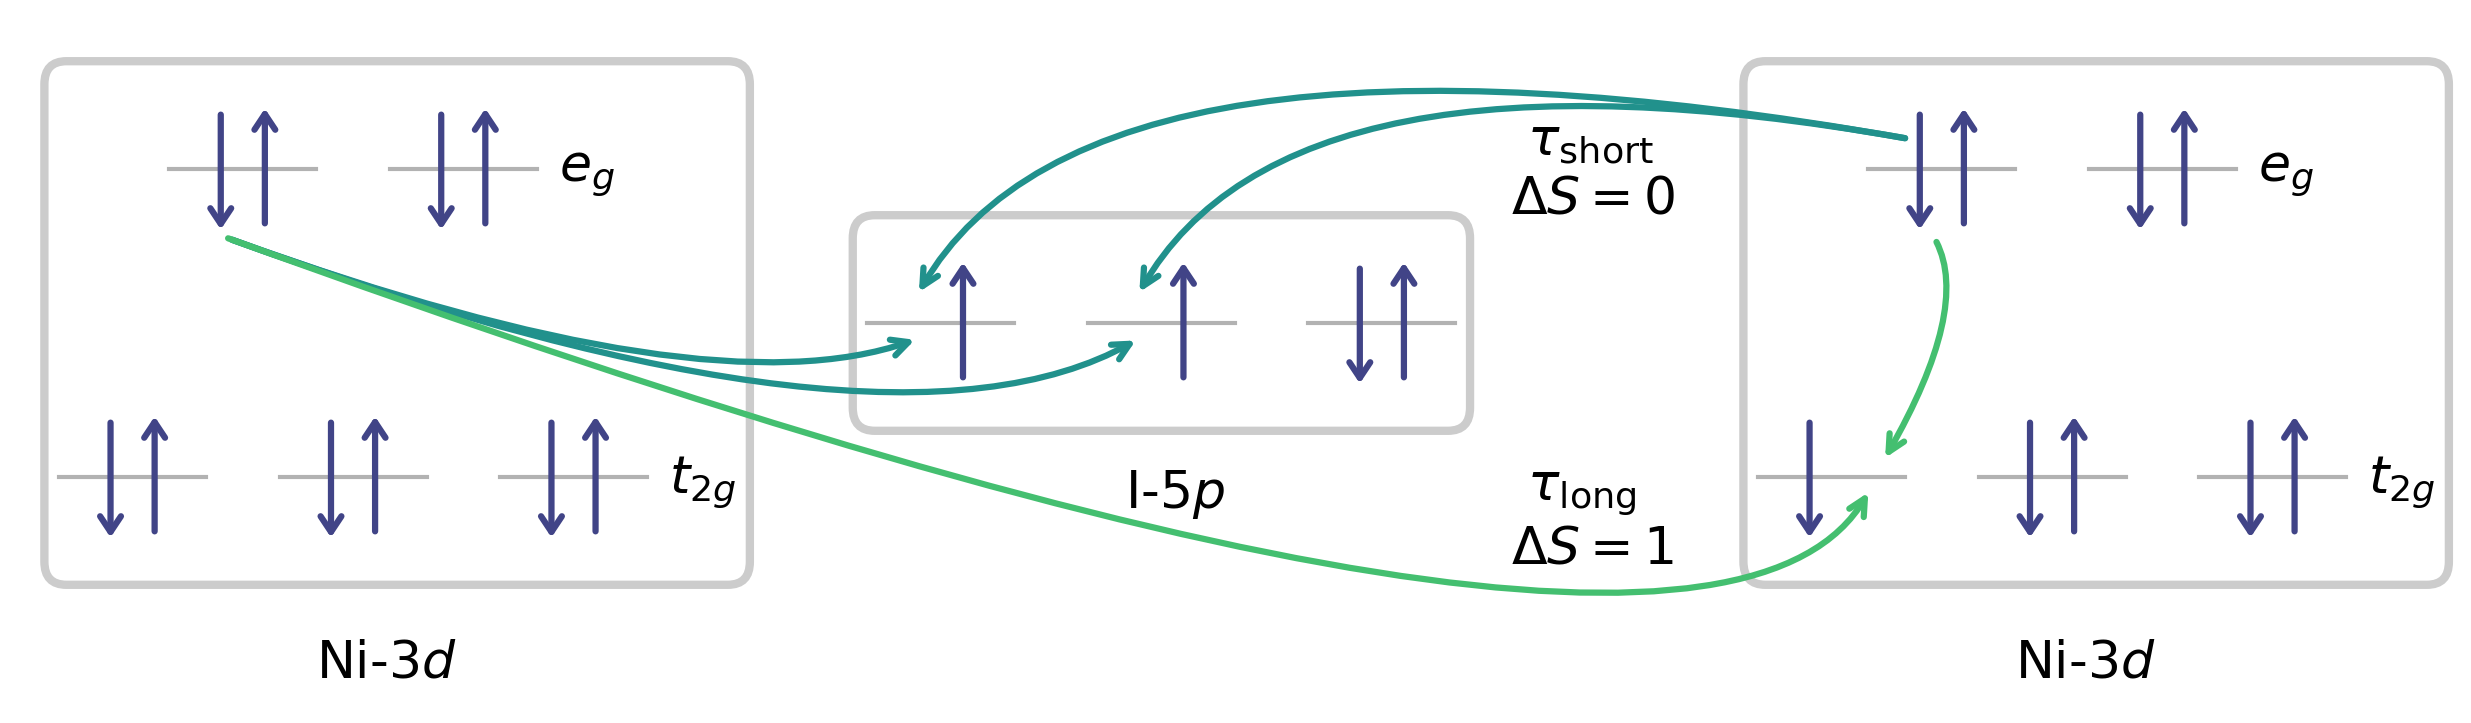

In [ ]:
from matplotlib.patches import ConnectionStyle, FancyBboxPatch, ConnectionPatch

fig, axs = plt.subplots(1,2, width_ratios=[1, (101/201)])
fig.set_size_inches(21,6)

colormap = mpl.colormaps['viridis']
colors = colormap(np.linspace(0.2,0.8,2))

# Energy Levels
levels_x = [np.linspace(-40,-20,2), np.linspace(-10,10,2), np.linspace(20,40,2), np.linspace(-25,-5,2), np.linspace(5,25,2)]
levels_y = [np.linspace(0,0,2), np.linspace(0,0,2), np.linspace(0,0,2), np.linspace(2,2,2), np.linspace(2,2,2)]

levels_I_x = [np.linspace(70,90,2), np.linspace(100,120,2), np.linspace(130,150,2)]
levels_I_y = np.linspace(1,1,2)

# Draw Functions
def AddArrow(level, spin, color, alpha, lw, ls, ax):
    if spin == 'Up':
        x = (levels_x[level][0]+levels_x[level][1])/2 + 3
        y_pos = levels_y[level][0] + 0.42
        y_neg = levels_y[level][0] - 0.38
        ax.annotate('', xy=(x, y_pos), xytext=(x, y_neg), arrowprops=dict(arrowstyle=('->, head_length=0.75, head_width=0.5'), color=color, alpha=alpha, linewidth=lw, linestyle=ls))
    elif spin == 'Down':
        x = (levels_x[level][0]+levels_x[level][1])/2 - 3
        y_pos = levels_y[level][0] + 0.38
        y_neg = levels_y[level][0] - 0.42
        ax.annotate('', xy=(x, y_pos), xytext=(x, y_neg), arrowprops=dict(arrowstyle='<-, head_length=0.75, head_width=0.5', color=color, alpha=alpha, linewidth=lw, linestyle=ls))

def AddArrow_I(level, spin, color, alpha, lw, ls, ax):
    if spin == 'Up':
        x = (levels_I_x[level][0]+levels_I_x[level][1])/2 + 3
        y_pos = levels_I_y[0] + 0.42
        y_neg = levels_I_y[0] - 0.38
        ax.annotate('', xy=(x, y_pos), xytext=(x, y_neg), arrowprops=dict(arrowstyle=('->, head_length=0.75, head_width=0.5'), color=color, alpha=alpha, linewidth=lw, linestyle=ls))
    if spin == 'Down':
        x = (levels_I_x[level][0]+levels_I_x[level][1])/2 - 3
        y_pos = levels_I_y[0] + 0.38
        y_neg = levels_I_y[0] - 0.42
        ax.annotate('', xy=(x, y_pos), xytext=(x, y_neg), arrowprops=dict(arrowstyle='<-, head_length=0.75, head_width=0.5', color=color, alpha=alpha, linewidth=lw, linestyle=ls))

# Formatting
for ax in axs:
    for x, y in zip(levels_x, levels_y):
        ax.plot(x,y, color='black', lw=2, alpha=0.3)
    ax.set_ylim(-1.5,3)
    ax.axis('off')

    ax.annotate(fr'$t_{{2g}}$', (43, -0.1), fontsize=25)
    ax.annotate(fr'$e_{{g}}$', (28, 1.925), fontsize=25)

axs[0].set_xlim(-46, 155)
axs[1].set_xlim(-46, 55)

for x in levels_I_x:
    axs[0].plot(x, levels_I_y, color='black', lw=2, alpha=0.3)
    
    
# Electron Configurations
Ground_d8 = [(0, 'Down', 1, 'solid', colors[0]),
             (0, 'Up', 1, 'solid', colors[0]),
             (1, 'Down', 1, 'solid', colors[0]),
             (1, 'Up', 1, 'solid', colors[0]),
             (2, 'Down', 1, 'solid', colors[0]),
             (2, 'Up', 1, 'solid', colors[0]),
             (3, 'Up', 1, 'solid', colors[0]),
             (4, 'Up', 1, 'solid', colors[0])]


Excited_CT = [(0, 'Down', 1, 'solid', colors[0]),
              (0, 'Up', 1, 'solid', colors[0]),
              (1, 'Down', 1, 'solid', colors[0]),
              (1, 'Up', 1, 'solid', colors[0]),
              (2, 'Down', 1, 'solid', colors[0]),
              (2, 'Up', 1, 'solid', colors[0]),
              (3, 'Down', 1, 'solid', colors[0]),
              (3, 'Up', 1, 'solid', colors[0]),
              (4, 'Up', 1, 'solid', colors[0])]

Excited_d10 = [(0, 'Down', 1, 'solid', colors[0]),
               (0, 'Up', 1, 'solid', colors[0]),
               (1, 'Down', 1, 'solid', colors[0]),
               (1, 'Up', 1, 'solid', colors[0]),
               (2, 'Down', 1, 'solid', colors[0]),
               (2, 'Up', 1, 'solid', colors[0]),
               (3, 'Down', 1, 'solid', colors[0]),
               (3, 'Up', 1, 'solid', colors[0]),
               (4, 'Up', 1, 'solid', colors[0]),
               (4, 'Down', 1, 'solid', colors[0])]

Excited_1T2g = [(0, 'Down', 1, 'solid', colors[0]),
                (1, 'Down', 1, 'solid', colors[0]),
                (1, 'Up', 1, 'solid', colors[0]),
                (2, 'Down', 1, 'solid', colors[0]),
                (2, 'Up', 1, 'solid', colors[0]),
                (3, 'Down', 1, 'solid', colors[0]),
                (3, 'Up', 1, 'solid', colors[0]),
                (4, 'Up', 1, 'solid', colors[0])]

Excited_1T2g_ZR = [(0, 'Down', 1, 'solid', colors[0]),
                (1, 'Down', 1, 'solid', colors[0]),
                (1, 'Up', 1, 'solid', colors[0]),
                (2, 'Down', 1, 'solid', colors[0]),
                (2, 'Up', 1, 'solid', colors[0]),
                (3, 'Down', 1, 'solid', colors[0]),
                (3, 'Up', 1, 'solid', colors[0]),
                (4, 'Up', 1, 'solid', colors[0]),
                (4, 'Down', 1, 'solid', colors[0])]

Iodine_full =[(0, 'Down', 1, 'solid', colors[0]),
              (0, 'Up', 1, 'solid', colors[0]),
              (1, 'Down', 1, 'solid', colors[0]),
              (1, 'Up', 1, 'solid', colors[0]),
              (2, 'Down', 1, 'solid', colors[0]),
              (2, 'Up', 1, 'solid', colors[0])]

Iodine_CT =[(0, 'Up', 1, 'solid', colors[0]),
            (1, 'Down', 1, 'solid', colors[0]),
            (1, 'Up', 1, 'solid', colors[0]),
            (2, 'Down', 1, 'solid', colors[0]),
            (2, 'Up', 1, 'solid', colors[0])]

Iodine_L2 =[(0, 'Up', 1, 'solid', colors[0]),
            (1, 'Up', 1, 'solid', colors[0]),
            (2, 'Down', 1, 'solid', colors[0]),
            (2, 'Up', 1, 'solid', colors[0])]

# Stages of the CT and 1T2g excitation and decay scheme
stage = 3
Ni_Progression= [[Ground_d8, Ground_d8],
                 [Excited_CT, Excited_1T2g],
                 [Excited_CT, Excited_1T2g],
                 [Excited_d10, Excited_1T2g_ZR]]

I_Progression = [Iodine_full,
                 Iodine_CT,
                 Iodine_CT,
                 Iodine_L2]

# Draw Electron arrows onto Ni- and I-sites for the selected stage of the excitation scheme
for arrow in Ni_Progression[stage][0]:
    AddArrow(arrow[0], spin=arrow[1], color=arrow[4], alpha=arrow[2], lw=3, ls=arrow[3], ax=axs[0])

for arrow in I_Progression[stage]:
    AddArrow_I(arrow[0], spin=arrow[1], color=arrow[4], alpha=arrow[2], lw=3, ls=arrow[3], ax=axs[0])

for arrow in Ni_Progression[stage][1]:
    AddArrow(arrow[0], spin=arrow[1], color=arrow[4], alpha=arrow[2], lw=3, ls=arrow[3], ax=axs[1])

# Draw Boxes around Ni- and I-diagrams
for ax in axs:
    Ni_Box = FancyBboxPatch((-2,-0.6), width=4.6, height=3.2, boxstyle='round, pad=0.1, rounding_size=0.15', edgecolor='black', fill=False, alpha=0.2, linewidth=4,
                        transform=mpl.transforms.Affine2D().scale(sx=20, sy=1)+ax.transData)
    ax.add_patch(Ni_Box)
    ax.annotate(fr'Ni-3$d$', xy=(-5,-1.3), fontsize=25)

I_Box = FancyBboxPatch((3.5,0.4), width=4, height=1.2, boxstyle='round, pad=0.1, rounding_size=0.15', edgecolor='black', fill=False, alpha=0.2, linewidth=4,
                        transform=mpl.transforms.Affine2D().scale(sx=20, sy=1)+axs[0].transData)
axs[0].add_patch(I_Box)
axs[0].annotate(fr'I-5$p$', xy=(105,-0.2), fontsize=25)

# Arrows showing electron transitions / decay channels
if stage == 1:
    axs[0].annotate('', xy=(77, 0.9), xytext=(-18, 1.55), arrowprops=dict(arrowstyle='<-',
                    connectionstyle=ConnectionStyle('angle3', angleA=-30, angleB=10), linewidth=3, color=colormap(0.5), mutation_scale=20))
    axs[0].annotate(fr'   CT{'\n'}$\Delta S=0$', xy=(35, 0.9), fontsize=20)
    axs[1].annotate('', xy=(-23, 0.1), xytext=(-17, 1.55), arrowprops=dict(arrowstyle='<-',
                    connectionstyle=ConnectionStyle('angle3', angleA=-70, angleB=40), linewidth=3, color=colormap(0.7), mutation_scale=20))
    axs[1].annotate(fr' $^{{1}}T_{{2g}}${'\n'}$\Delta S=1$', xy=(-35, 0.7), fontsize=20)

if stage >= 2:
    axs[0].annotate('', xy=(77, 0.9), xytext=(-17, 1.55), arrowprops=dict(arrowstyle='->', mutation_scale=20, zorder=2,
                    connectionstyle=ConnectionStyle('angle3', angleA=-20, angleB=20), linewidth=3, color=colormap(0.5)))
    arrow_CT_long = ConnectionPatch([-17, 1.55], [-25, -0.1], coordsA=axs[0].transData, coordsB=axs[1].transData,
                                    color=colormap(0.7), arrowstyle='->', linestyle='solid', linewidth=3, mutation_scale=20,
                                    connectionstyle=ConnectionStyle('angle3', angleA=-20, angleB=60))
    fig.patches.append(arrow_CT_long)
    axs[1].annotate('', xy=(-23, 0.1), xytext=(-16, 1.55), arrowprops=dict(arrowstyle='->', mutation_scale=20,
                    connectionstyle=ConnectionStyle('angle3', angleA=-60, angleB=60), linewidth=3, color=colormap(0.7)))
    
    arrow_dd_long = ConnectionPatch([77, 1.2], [-20, 2.2], coordsA=axs[0].transData, coordsB=axs[1].transData,
                                    color=colormap(0.5), arrowstyle='<-', linestyle='solid', linewidth=3, mutation_scale=20,
                                    connectionstyle=ConnectionStyle('angle3', angleA=60, angleB=-10))
    fig.patches.append(arrow_dd_long)
    fig.text(x=0.6, y=0.66, s=fr' $\tau_{{\mathrm{{short}}}}${'\n'}$\Delta S=0$', color='black', size=25)
    fig.text(x=0.6, y=0.27, s=fr' $\tau_{{\mathrm{{long}}}}${'\n'}$\Delta S=1$', color='black', size=25)


if stage == 3:
    axs[0].annotate('', xy=(107, 0.9), xytext=(-17, 1.55), arrowprops=dict(arrowstyle='->', mutation_scale=20, zorder=2,
                    connectionstyle=ConnectionStyle('angle3', angleA=-20, angleB=30), linewidth=3, color=colormap(0.5)))
    arrow_dd_long2 = ConnectionPatch([107, 1.2], [-20, 2.2], coordsA=axs[0].transData, coordsB=axs[1].transData,
                                    color=colormap(0.5), arrowstyle='<-', linestyle='solid', linewidth=3, mutation_scale=20,
                                    connectionstyle=ConnectionStyle('angle3', angleA=60, angleB=-10))
    fig.patches.append(arrow_dd_long2)

#fig.savefig(fr'./Figures/Thesis/Electron Configurations/Excitation-Scheme-Stage{stage}.pdf', bbox_inches='tight')

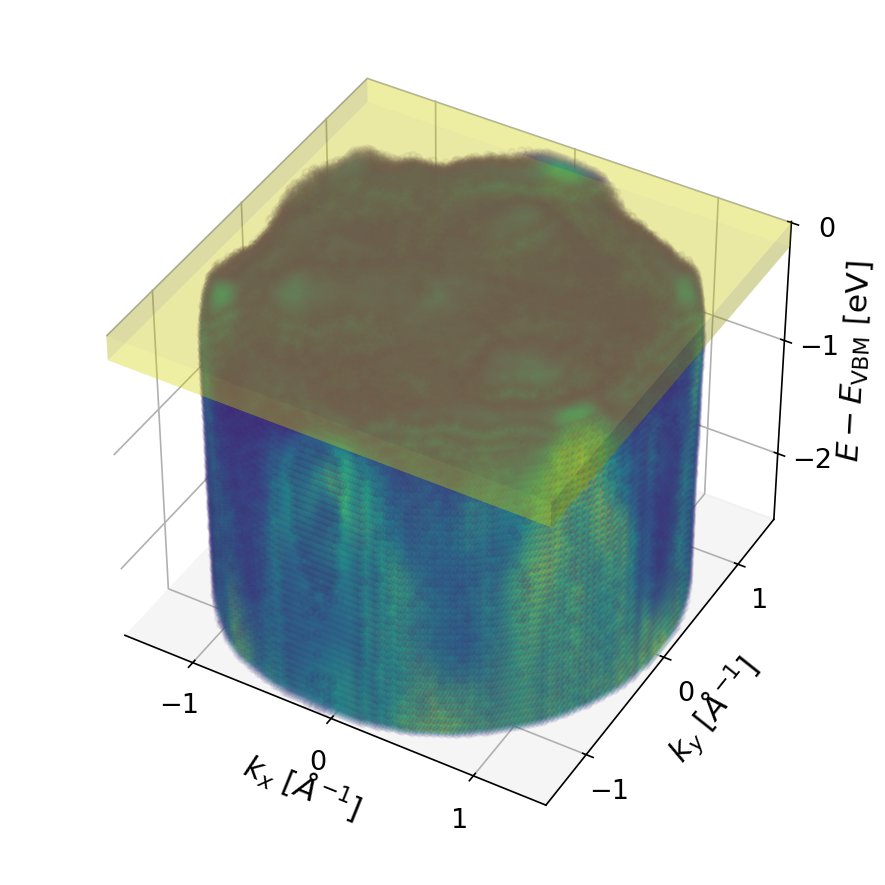

In [29]:
fig = plt.figure()
fig.set_size_inches(8, 6)
ax = fig.add_subplot(projection='3d')
fontsize = 15

E_step = 0.06
E_array = np.arange(-2.5, 0, step = E_step)
n_E = len(E_array)
kx_range = (-2, 2)
ky_range = (-2, 2)
zlims = (E_array[0]-0.1, E_array[-1]+0.05)
#xlims = (kx_range[0]-0.1, kx_range[1]+0.1)
#ylims = (ky_range[0]-0.1, ky_range[1]+0.1)
xlims = (-1.5, 1.5)
ylims = (-1.5, 1.5)
MomentumMaps = []
colormap = mpl.colormaps['viridis']
#colormap = cmap_LTL

delay_range = (-300, 1000)

# Lookup Table to linearize colormap
lookup = dict()
for i in range(256):
    temp = colormap(i/255)[0] + colormap(i/255)[1] + colormap(i/255)[2]
    lookup[temp] = i/255

def alpharule(r,g,b):
    value = lookup.get(r+g+b, 0)
    if value > 25/255:
        alpha = (np.exp((-(value-1)**2) / (0.2))) * 0.4 + 0.1
    else:
        alpha = 0
    return alpha

cmap_alpha = col.ListedColormap([(r, g, b, (alpharule(r,g,b))) for r, g, b, _ in colormap(np.arange(colormap.N))])

delay_center = (delay_range[0] + delay_range[1]) / 2
delay_int = (delay_range[1] - delay_range[0]) / 2

# At one point I tried showing excited states as well by boosing intensity for high energies
# Ended up only plotting to E=0 eV, so this doesn't do anything at this point
maps_hi = []
E_enhance = 0.5
for i in range(n_E):
    map = mpes.get_momentum_map(I_res[2], E=E_array[i], E_int = E_step, delay=delay_center, delay_int=delay_int)
    #map = map**2
    #MomentumMaps.append(map)
    if E_array[i] > E_enhance:
        #map = map**(1.75)
        maps_hi.append(map)
    else:
        map = map
    MomentumMaps.append(map)

Max_Intensity = np.max(MomentumMaps)

for i in range(n_E):
    if E_array[i] > E_enhance:
        max_hi = np.max(maps_hi)
        MomentumMaps[i] = MomentumMaps[i] / (7*max_hi)
        if E_array[i] < 1.4:
            MomentumMaps[i] = MomentumMaps[i] / 2.75
    else:
        MomentumMaps[i] = MomentumMaps[i] / Max_Intensity

kx, ky, E = np.meshgrid(MomentumMaps[0].sel(kx=slice(kx_range[0], kx_range[1])).kx.values, MomentumMaps[0].sel(ky=slice(ky_range[0], ky_range[1])).ky.values, E_array)
intensity = np.zeros_like(kx)

# Write intensity into separate array to use for coloring
for i in range(n_E):
    intensity[:,:,i] = MomentumMaps[i].sel(kx=slice(kx_range[0], kx_range[1]), ky=slice(ky_range[0], ky_range[1])).to_numpy()

# Deleting Points which would have alpha=0 anyways
# Saves a lot of computation time by not needlessly passing these to the ax.scatter() function
mask = np.where(intensity > 3/255, 0, 1)
mask_indices = np.argwhere(np.ravel(mask))

kx = np.delete(np.ravel(kx), mask_indices)
ky = np.delete(np.ravel(ky), mask_indices)
E = np.delete(np.ravel(E), mask_indices)
intensity = np.delete(np.ravel(intensity), mask_indices)


def Box3d(x, y, z, fig, ax, color, alpha):
    fig = fig
    ax = ax

    u = np.linspace(x[0], x[1], num = 2)
    v = np.linspace(y[0], y[1], num = 2)
    w = np.linspace(z[0], z[1], num = 2)    

    def const(x,y,c):
        return 0*x*y + c    

    surface = []
    #xy
    xy_base_1 , xy_base_2 = np.meshgrid(u, v)
    xy_func_1 = np.array(const(np.ravel(xy_base_1), np.ravel(xy_base_2), w[0])).reshape(xy_base_1.shape)
    surface.append([xy_base_1, xy_base_2, xy_func_1])
    xy_func_2 = np.array(const(np.ravel(xy_base_1), np.ravel(xy_base_2), w[-1])).reshape(xy_base_1.shape)
    surface.append([xy_base_1, xy_base_2, xy_func_2])   

    #xz
    xz_base_1, xz_base_2 = np.meshgrid(u, w)
    xz_func_1 = np.array(const(np.ravel(xz_base_1), np.ravel(xz_base_2), v[0])).reshape(xz_base_1.shape)
    surface.append([xz_base_1, xz_func_1, xz_base_2])
    xz_func_2 = np.array(const(np.ravel(xz_base_1), np.ravel(xz_base_2), v[-1])).reshape(xz_base_1.shape)
    surface.append([xz_base_1, xz_func_2, xz_base_2])   

    #yz
    yz_base_1, yz_base_2 = np.meshgrid(v, w)
    yz_func_1 = np.array(const(np.ravel(yz_base_1), np.ravel(yz_base_2), u[0])).reshape(yz_base_1.shape)
    surface.append([yz_func_1, yz_base_1, yz_base_2])
    yz_func_2 = np.array(const(np.ravel(yz_base_1), np.ravel(yz_base_2), u[-1])).reshape(yz_base_1.shape)
    surface.append([yz_func_2, yz_base_1, yz_base_2])   

    

    for i in range(len(surface)):
        ax.plot_surface(surface[i][0], surface[i][1], surface[i][2], color=color, alpha=alpha)

# Plot pointcloud
plot = ax.scatter(xs=kx, ys=ky, zs=E, c=intensity, cmap=cmap_alpha, depthshade=True, s=15, vmin=0, vmax=0.2)

# Plot integration boxes
#Box3d((xlims[0], xlims[1]), (-0.1, 0.1), (zlims[0], zlims[1]), fig, ax, 'lime', alpha=0.2) # k-Frame
Box3d((xlims[0], xlims[1]), (ylims[0], ylims[1]), (-0.2, 0), fig, ax, 'yellow', alpha=0.2) # Momentum Map

# Axis Formatting
ax.xaxis.set_pane_color('white', alpha=0)
ax.yaxis.set_pane_color('white', alpha=0)
ax.grid(visible=True)
#for i in np.arange(start=-2, stop=2+0.5, step=0.5):
#    ax.plot3D(i, np.linspace(ylims[0], ylims[1], 2), zlims[0], color='lightgrey',lw=1)
#for i in np.arange(start=-2, stop=2+0.5, step=0.5):
#    ax.plot3D(np.linspace(xlims[0], xlims[1], 2), i, zlims[0], color='lightgrey',lw=1)

ax.set_xlim(xlims[0], xlims[1])
ax.set_xticks([-1, 0, 1])
ax.set_ylim(ylims[0], ylims[1])
ax.set_yticks([-1, 0, 1])
ax.set_zlim(zlims[0], zlims[1])
ax.set_zticks([-2, -1, 0])
ax.tick_params(labelsize=fontsize-2)
ax.set_xlabel(fr'$k_x$ [$\AA^{{-1}}$]', fontsize=fontsize)
ax.set_ylabel(fr'$k_y$ [$\AA^{{-1}}$]', fontsize=fontsize)
ax.set_zlabel(fr'$E-E_{{\mathrm{{VBM}}}}$ [eV]', fontsize=fontsize)
ax.zaxis.labelpad=3.5
#ax.axis('off')
ax.set_box_aspect((1,1,0.8), zoom=0.9)
ax.view_init(roll=0, azim=-60, elev=40)
fig.tight_layout()
#fig.colorbar(plot, ax=ax)
#fig.savefig('./Figures/Thesis/Cylinder.png', bbox_inches='tight')

<unknown>:1057: SyntaxWarning: invalid escape sequence '\m'
<unknown>:1057: SyntaxWarning: invalid escape sequence '\m'


(-1.7, 1.7)

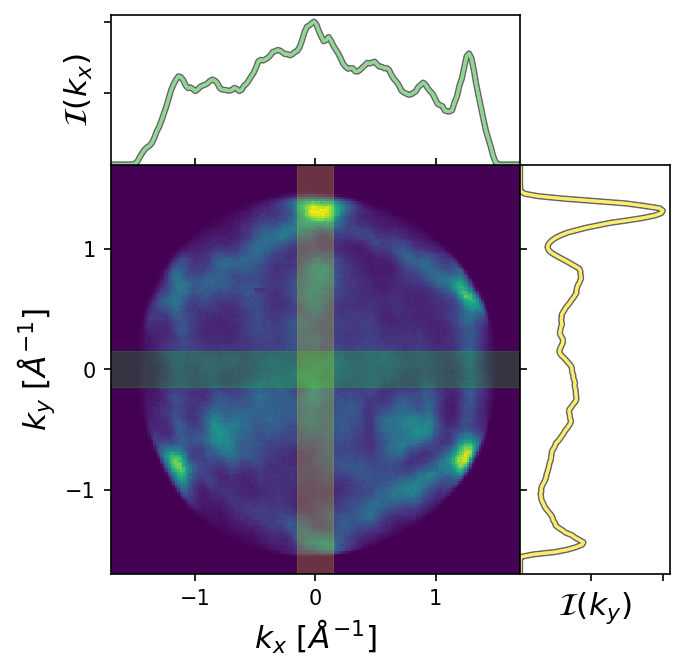

In [37]:
fig, ax = plt.subplots()
map = mpes.get_momentum_map(I_res[2], E=-0.1, E_int=0.2, delay=0, delay_int=2000)
ax_mdc_x, mdc_x, ax_mdc_y, mdc_y = mpes.plot_mdcs(map, fig=fig, ax=ax)

ax_mdc_x.set_ylabel(fr'$\mathcal{{I}}(k_{{x}})$', fontsize=15)
ax_mdc_y.set_xlabel(fr'$\mathcal{{I}}(k_{{y}})$', fontsize=15)
ax_mdc_x.set_title('')
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)
#fig.savefig('./Figures/Thesis/MM-MDC-Intro.pdf', bbox_inches='tight')

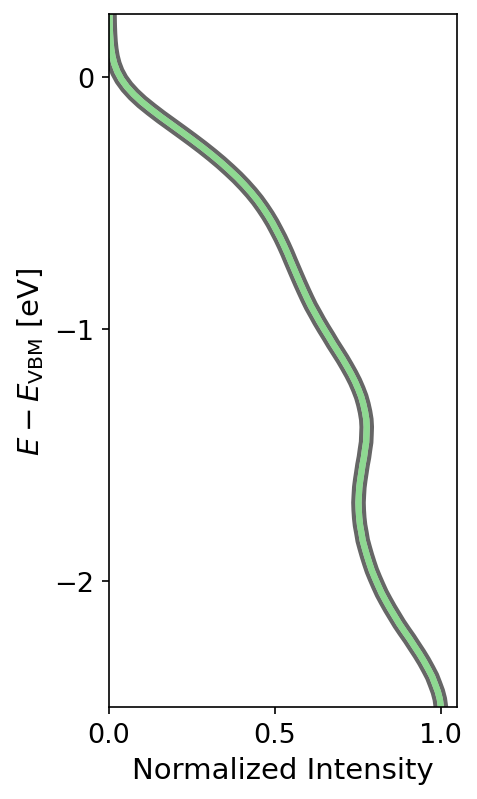

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(3,6)
fontsize = 15
colormap = mpl.colormaps['viridis']

edc = mpes.get_edc(I_res[2].loc[{'E':slice(-2.5, 0.5)}], kx=0, ky=0, kx_int=4, ky_int=4, delay=0, delay_int=2000)
edc = edc / np.max(edc)

ax.plot(edc.values, edc.E.values, color=colormap(0.75), alpha=0.7, lw=3, path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=0.6),
                                                                            pe.Stroke(foreground='white', alpha=1), pe.Normal()])
ax.set_xlabel(fr'Normalized Intensity', fontsize=fontsize-1)
ax.set_xticks([0, 0.5, 1])
ax.set_xlim(0, 1.05)
ax.set_ylabel(fr'$E-E_{{\mathrm{{VBM}}}}$ [eV]', fontsize=fontsize-1)
ax.set_yticks([-2, -1, 0])
ax.set_ylim(-2.5, 0.25)
ax.tick_params(labelsize=fontsize-2)
#fig.savefig('./Figures/Thesis/EDC-Intro.pdf', bbox_inches='tight')

Text(-2, 0, '$\\mathcal{I}(k_{x},k_{y},\\Delta t)$')

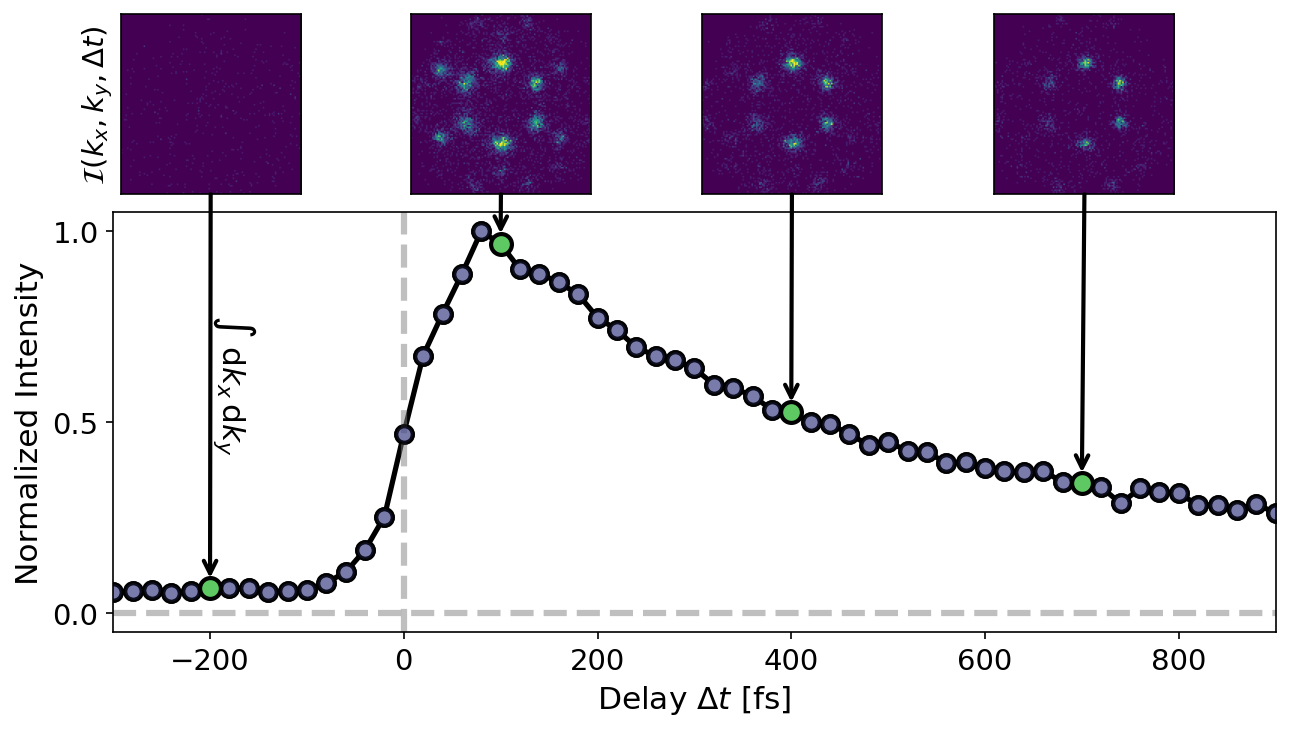

In [ ]:
from matplotlib import patches
fig, axs = plt.subplot_mosaic([
    ['Map0','Map1','Map2', 'Map3'],
    ['TT', 'TT', 'TT', 'TT']
])

fig.set_size_inches(10, 8)
fontsize = 15
colormap = mpl.colormaps['viridis']

# Seawoo's WSe2 data is binned in fs, but I originially binned my NiI2 data in ps and then convert to fs in the background
# as kind of a hacky workaround because at the time this was faster than re-binning my data in fs.
# This means the delay coordinates are off by a factor of 1000 and so I rescale the WSe2 delay axis to match the data structure I use for the NiI2 data
WSe_rescaled = xr.DataArray(I_res[3], dims=('kx', 'ky', 'E', 'delay'), coords={'kx':I_res[3].kx.values, 'ky':I_res[3].ky.values, 'E':I_res[3].E.values, 'delay': I_res[3].delay.values / 1000})

Energy = 1.55
E_int =0.3
# Get Delay Curve and Momentum maps at a few representative delays
trace = mpes.get_time_trace(WSe_rescaled, E=Energy, E_int=E_int, k=(0,0), k_int=(4,4), norm_trace=True, subtract_neg=False, neg_delays=(-250, -100))
map0 = mpes.get_momentum_map(WSe_rescaled, E=Energy, E_int=E_int, delay=-200, delay_int=50)
map1 = mpes.get_momentum_map(WSe_rescaled, E=Energy, E_int=E_int, delay=100, delay_int=50)
map2 = mpes.get_momentum_map(WSe_rescaled, E=Energy, E_int=E_int, delay=400, delay_int=50)
map3 = mpes.get_momentum_map(WSe_rescaled, E=Energy, E_int=E_int, delay=700, delay_int=50)

# Normalize all MMs to the same intensity to retain intensity drop in plots
norm = np.max(map1)
map0 = map0 / norm
map1 = map1 / norm
map2 = map2 / norm
map3 = map3 / norm
maps = [map0, map1, map2, map3]

# x- and y-coordinates of points in the delay curve I want to highlight
dot0 = trace.loc[{'delay':slice(-210, -190)}]
dot1 = trace.loc[{'delay':slice(90, 110)}]
dot2 = trace.loc[{'delay':slice(390, 410)}]
dot3 = trace.loc[{'delay':slice(690, 710)}]

x = [dot0.delay.values[0], dot1.delay.values[0], dot2.delay.values[0], dot3.delay.values[0]]
y = [dot0.values[0], dot1.values[0], dot2.values[0], dot3.values[0]]

#axs['TT'].plot(trace.delay.values, trace.values, zorder=2, color=colormap(0.2), alpha=0.7, lw=3, path_effects=[pe.Stroke(linewidth=7, foreground='black', alpha=0.7),
#                                                                            pe.Stroke(foreground='white', alpha=1), pe.Normal()])
# Plot delay curve
axs['TT'].plot(trace.delay.values, trace.values, zorder=1, mfc='white', mec='black', ms=8, alpha=1, mew=2, color='black', marker='o', lw=2.5)
axs['TT'].plot(trace.delay.values, trace.values, zorder=2, mfc=colormap(0.2), mec='black', ms=8, alpha=0.7, mew=2, color='black', marker='o', lw=0)
axs['TT'].scatter(x, y, edgecolors='black', zorder=3, color=colormap(0.75), s=100, lw=2, ls='solid')
axs['TT'].axvline(0, lw=3, color='grey', alpha=0.5, linestyle='dashed', zorder=1)
axs['TT'].axhline(0, lw=3, color='grey', alpha=0.5, linestyle='dashed', zorder=1)
axs['TT'].set_xlim(-300, 900)
axs['TT'].set_yticks([0, 0.5, 1])

# MM positions and sizes in figure coordinates
map_positions = [(0.115, 0.475, 0.15, 0.15),
                 (0.3085, 0.475, 0.15, 0.15),
                 (0.5025, 0.475, 0.15, 0.15),
                 (0.6975, 0.475, 0.15, 0.15)]

# Plot MMs
for i, ax in enumerate([axs['Map0'], axs['Map1'], axs['Map2'], axs['Map3']]):
    ax.imshow(maps[i], cmap=colormap, aspect=1, extent=(-2,2,-2,2), vmin=0, vmax=0.7)
    ax.set_position(map_positions[i])
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    ax.set_xticks([])
    ax.set_yticks([])

# Lines between MMs and Green Points
arrows = []
for i, ax in enumerate([axs['Map0'], axs['Map1'], axs['Map2'], axs['Map3']]):
    arrow = patches.ConnectionPatch([0, -1.6], [x[i], y[i]+0.0275], coordsA=ax.transData, coordsB=axs['TT'].transData,
                                    color='black', arrowstyle='->', linestyle='solid', linewidth=2, mutation_scale=15)
    arrows.append(arrow)

for arrow in arrows:
    fig.patches.append(arrow)

axs['TT'].set_xlabel(fr'Delay $\Delta t$ [fs]', fontsize=fontsize)
axs['TT'].set_ylabel(fr'Normalized Intensity', fontsize=fontsize)
axs['TT'].tick_params(axis='both', labelsize=fontsize-1)
axs['TT'].text(x=-175, y=0.6, s=fr'$\int\;\mathrm{{d}}k_{{x}}\,\mathrm{{d}}k_{{y}}$', size=fontsize, ha='center', va='center', rotation=-90)
axs['Map0'].text(x=-2, y=0, s=fr'$\mathcal{{I}}(k_{{x}},k_{{y}},\Delta t)$', size=fontsize-1, ha='center', va='center', rotation=90)
#fig.savefig('./Figures/Thesis/TT-Intro-WSe2.pdf', bbox_inches='tight')

(-8.0, 8.0)

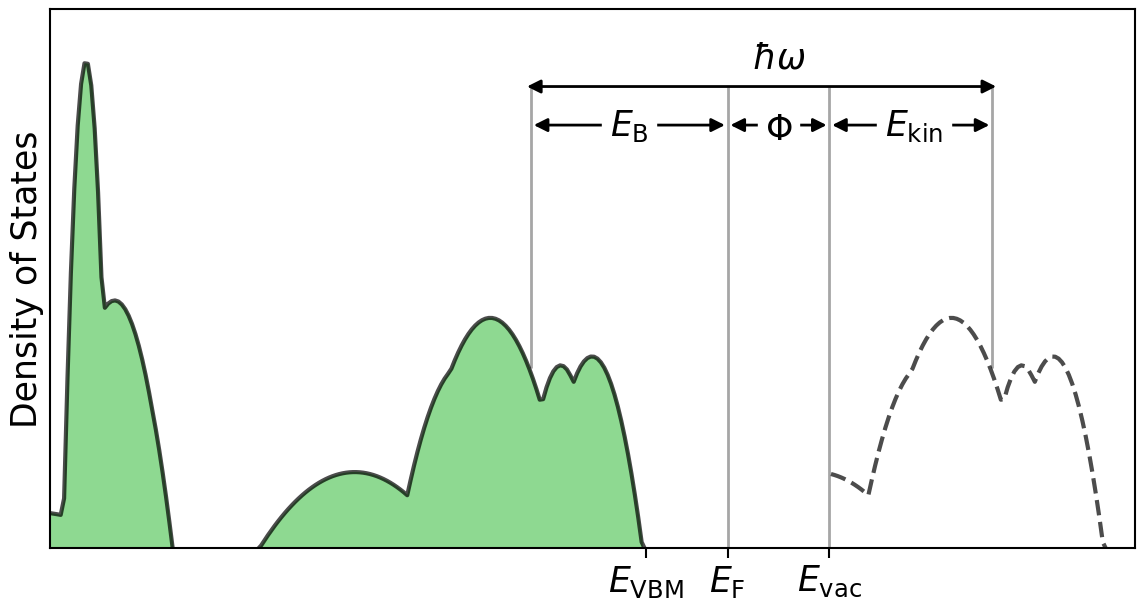

In [ ]:
# Sketch of energy conservation in photoemission for introduction
x = np.linspace(-15, 10, num=500)

# Define some parabolas to sketch a cartoon density of states
parabola_1 = -(3*x)**2 + 5
parabola_2 = -(2*(x+1.5))**2 + 6
parabola_3 = -(x+3.5)**2 + 2
parabola_4 = -(3*(x+7))**2 + 6
parabola_5 = -(10*(x+7.5))**2 + 8
parabola_6 = -(0.5*(x+8.5))**2 + 1
parabola_7 = -(2*(x-5))**2 + 4
parabola_8 = -(5*(x-5.5))**2 + 7

dos = np.zeros_like(x)

# Add parabolas to total DOS
for parabola in [parabola_1, parabola_2, parabola_3, parabola_4, parabola_5, parabola_6]:
    temp = np.where(parabola > 0, parabola, 0)
    dos = dos + temp

fig, ax = plt.subplots()
fig.set_size_inches(14,7)
fontsize = 25
colormap = mpl.colormaps['viridis']

# Plot DOS and partial shifted version for photoelectron distribution
ax.plot(x, dos, color='black', lw=3, alpha=0.7, zorder=2)
shift = 6.8
x_shift = np.extract(x>-shift+3.5, x)
dos_shift = np.extract(x>-shift+3.5, dos)
ax.plot(x_shift+shift, dos_shift, color='black', lw=3, alpha=0.7, zorder=2, ls='dashed')
ax.fill_between(x, np.zeros_like(x), dos, where=x<0.75, color=colormap(0.75), alpha=0.7, zorder=0)

# Draw arrows and annotations for E_kin = hw - E_B - Phi
ax.annotate('', xy=(-1, 12), xytext=(6,12), arrowprops=dict(arrowstyle='<|-|>', color='black', linewidth=2, mutation_aspect=1, mutation_scale=20))
ax.vlines(-0.9, ymin=4.7, ymax=12, color='grey', ls='solid', alpha=0.7, lw=2, zorder=1)

text_y = 11

ax.annotate(fr'$E_{{\mathrm{{B}}}}$', xy=(0.55, text_y), fontsize=fontsize, ha='center', va='center', zorder=4)
ax.annotate('', xy=(-0.9, text_y), xytext=(2,text_y), arrowprops=dict(arrowstyle='<|-|>', color='black', linewidth=2, mutation_aspect=1, mutation_scale=20))
rect1 = Rectangle(xy=(0.15, 10.8), width=0.8, height=1, color='white', zorder=3)
ax.add_patch(rect1)

ax.annotate(fr'$\Phi$', xy=(2.75, text_y-0.1), fontsize=fontsize, ha='center', va='center', zorder=4)
ax.annotate('', xy=(2, text_y), xytext=(3.5,text_y), arrowprops=dict(arrowstyle='<|-|>', color='black', linewidth=2, mutation_aspect=1, mutation_scale=20))
rect2 = Rectangle(xy=(2.45, 10.8), width=0.6, height=1, color='white', zorder=3)
ax.add_patch(rect2)

ax.annotate(fr'$E_{{\mathrm{{kin}}}}$', xy=(4.75, text_y), fontsize=fontsize, ha='center', va='center', zorder=4)
ax.annotate('', xy=(3.5, text_y), xytext=(5.9,text_y), arrowprops=dict(arrowstyle='<|-|>', color='black', linewidth=2, mutation_aspect=1, mutation_scale=20))
rect3 = Rectangle(xy=(4.2, 10.8), width=1.1, height=1, color='white', zorder=3)
ax.add_patch(rect3)

ax.annotate(fr'$\hbar\omega$', xy=(2.75, 12.75), fontsize=fontsize, ha='center', va='center')
#ax.vlines(0.8, ymin=0, ymax=11, color='grey', ls='dashed', alpha=0.7, lw=2)
ax.vlines(2, ymin=0, ymax=12, color='grey', ls='solid', alpha=0.7, lw=2, zorder=1)
ax.vlines(3.5, ymin=0, ymax=12, color='grey', ls='solid', alpha=0.7, lw=2, zorder=1)
ax.vlines(5.9, ymin=4.7, ymax=12, color='grey', ls='solid', alpha=0.7, lw=2, zorder=1)

# Formatting
for dir in ['top', 'bottom', 'left', 'right']:
    ax.spines[dir].set_linewidth(1.5)

ax.set_xticks([0.8, 2, 3.5], labels=[fr'$E_{{\mathrm{{VBM}}}}$', fr'$E_{{\mathrm{{F}}}}$', fr'$E_{{\mathrm{{vac}}}}$'])
ax.set_yticks([])
ax.tick_params(axis='both', labelsize=fontsize , width=1.5, length=7)
ax.set_ylabel(fr'Density of States', fontsize=fontsize)
ax.set_ylim(0.02, 14)
ax.set_xlim(-8,8)
#fig.savefig('./Figures/Thesis/EnergyConservation-Photoemission.pdf', bbox_inches='tight')

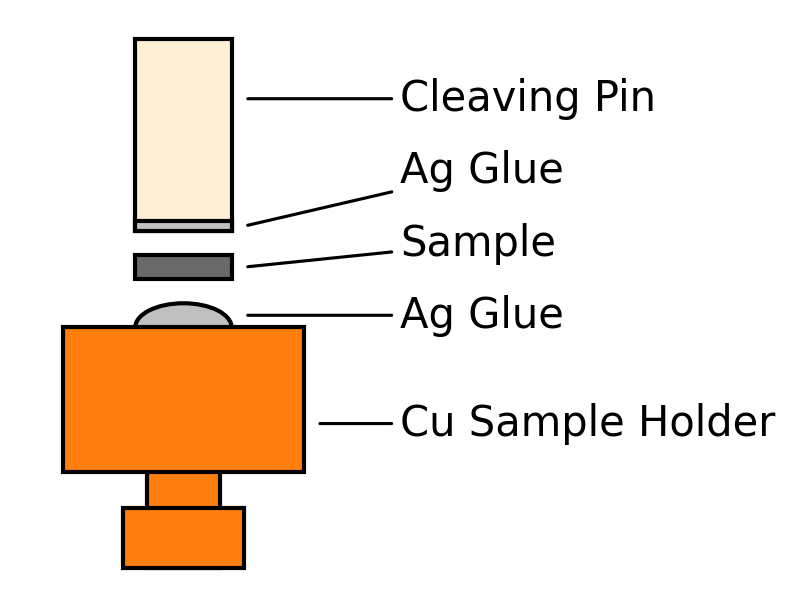

In [ ]:
from matplotlib.patches import Ellipse
fig, ax = plt.subplots()
fig.set_size_inches(7,5)
fontsize = 20

stage = 0 # Stage Variable (0, 1, or 2) determines which of the three subfigures gets plotted
# Sample holder
rect1 = Rectangle(xy=(0,1), width=5, height=3, linewidth=2, facecolor='tab:orange', edgecolor='black', zorder=1)
rect2 = Rectangle(xy=(3.5/2,-1), width=1.5, height=3, linewidth=2, facecolor='tab:orange', edgecolor='black', zorder=0)
rect3 = Rectangle(xy=(1.25,-1), width=2.5, height=1.25, linewidth=2, facecolor='tab:orange', edgecolor='black', zorder=1)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)

# Glue
if stage == 0:
    glue = Ellipse(xy=(2.5,4), width=2, height=1, zorder=0, facecolor='silver', edgecolor='black', linewidth=2)
elif stage == 1:
    glue = Rectangle(xy=(1.5,4), width=2, height=0.25, linewidth=2, facecolor='silver', edgecolor='black', zorder=1)
elif stage == 2:
    glue = Rectangle(xy=(1.5,4), width=2, height=0.25, linewidth=2, facecolor='silver', edgecolor='black', zorder=1)

ax.add_patch(glue)

# Sample
if stage == 0:
    sample = Rectangle(xy=(1.5,5), width=2, height=0.5, facecolor='dimgrey', edgecolor='black', linewidth=2)
elif stage == 1:
    sample = Rectangle(xy=(1.5,4.25), width=2, height=0.5, facecolor='dimgrey', edgecolor='black', linewidth=2)
elif stage == 2:
    sample = Rectangle(xy=(1.5,4.25), width=2, height=0.25, facecolor='dimgrey', edgecolor='black', linewidth=2)
ax.add_patch(sample)

# Cleaving Post
if stage == 0:
    post = Rectangle(xy=(1.5,6), width=2, height=4, facecolor='papayawhip', edgecolor='black', linewidth=2)
elif stage == 1:
    post = Rectangle(xy=(1.5,4.75), width=2, height=4, facecolor='papayawhip', edgecolor='black', linewidth=2)
elif stage == 2:
    post = Rectangle(xy=(1.25,5), width=2, height=4, facecolor='papayawhip', edgecolor='black', linewidth=2,
                     transform=mpl.transforms.Affine2D().rotate_deg_around(1.5, 4.75, 25) + ax.transData)
    sample_rest = Rectangle(xy=(1.25,4.75), width=2, height=0.25, facecolor='dimgrey', edgecolor='black', linewidth=2,
                     transform=mpl.transforms.Affine2D().rotate_deg_around(1.5, 4.75, 25) + ax.transData)
    ax.add_patch(sample_rest)
    wobblestick = Rectangle(xy=(2,9), width=12, height=0.5, linewidth=2, facecolor='silver', edgecolor='black')
    ax.add_patch(wobblestick)
ax.add_patch(post)

# Cleaving Post Glue
if stage == 0:
    post_glue = Rectangle(xy=(1.5,6), width=2, height=0.2, facecolor='silver', edgecolor='black', linewidth=2)
elif stage == 1:
    post_glue = Rectangle(xy=(1.5,4.75), width=2, height=0.2, facecolor='silver', edgecolor='black', linewidth=2)
elif stage == 2:
    post_glue = Rectangle(xy=(1.25,5), width=2, height=0.2, facecolor='silver', edgecolor='black', linewidth=2,
                     transform=mpl.transforms.Affine2D().rotate_deg_around(1.5, 4.75, 25) + ax.transData)


ax.add_patch(post_glue)

# Annotations
if stage == 0:
    ax.annotate(fr'Cu Sample Holder', xy=(5.25,2), xytext=(7,2), arrowprops=dict(arrowstyle='-', lw=1.5), va='center', fontsize=fontsize)
    ax.annotate(fr'Ag Glue', xy=(3.75,4.25), xytext=(7,4.25), arrowprops=dict(arrowstyle='-', lw=1.5), va='center', fontsize=fontsize)
    ax.annotate(fr'Sample', xy=(3.75,5.25), xytext=(7,5.75), arrowprops=dict(arrowstyle='-', lw=1.5), va='center', fontsize=fontsize)
    ax.annotate(fr'Ag Glue', xy=(3.75,6.1), xytext=(7,7.25), arrowprops=dict(arrowstyle='-', lw=1.5), va='center', fontsize=fontsize)
    ax.annotate(fr'Cleaving Pin', xy=(3.75,8.75), xytext=(7,8.75), arrowprops=dict(arrowstyle='-', lw=1.5), va='center', fontsize=fontsize)
elif stage == 1:
    ax.annotate('', xy=(4,4.5), xytext=(4,8.5), arrowprops=dict(arrowstyle='->', lw=1.5, mutation_aspect=1.5))
elif stage == 2:
    ax.annotate(fr'Cleaved Sample', xy=(3.75,4.35), xytext=(6,4.35), arrowprops=dict(arrowstyle='-', lw=1.5), va='center', fontsize=fontsize)
    ax.annotate(fr'Wobble Stick', xy=(8.8,8.75), xytext=(6,6), arrowprops=dict(arrowstyle='-', lw=1.5), va='center', fontsize=fontsize)
    ax.annotate('', xy=(2,10), xytext=(8,10), arrowprops=dict(arrowstyle='->', lw=1.5, mutation_aspect=1.5))

ax.set_aspect(1)
if stage == 1:
    ax.set_xlim(-1,6)
else:
    ax.set_xlim(-1,12.5)
ax.set_ylim(-1.5,10.5)
ax.axis('off')
#fig.savefig(fr'./Figures/Thesis/Cleaving_{stage}.pdf', bbox_inches='tight')

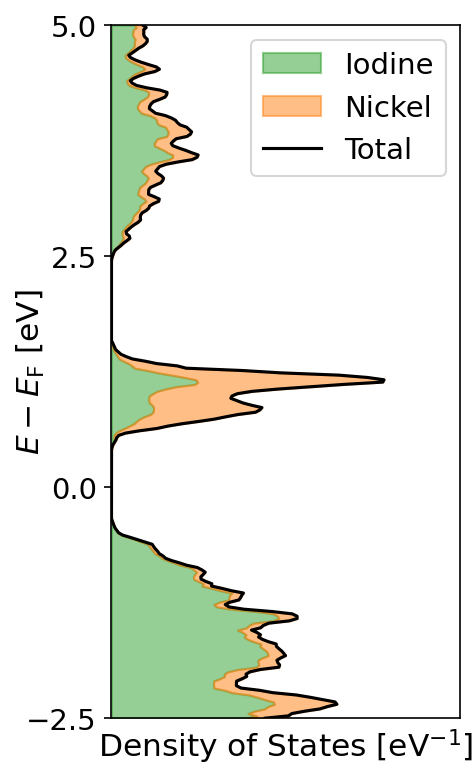

In [9]:
# Element-resolved DOS taken from
#
# An, Y. et al. Spin transport properties and nanodevice simulations of NiI2 monolayer.
# Physica E: Low-dimensional Systems and Nanostructures 142, 115262. issn: 1386-9477. https://www.sciencedirect.com/science/article/pii/S1386947722001151 (2022).

strings_Ni = ['./DFT/DOS Ni1 VB.csv', './DFT/DOS Ni2 VB.csv', './DFT/DOS Ni1 CB.csv', './DFT/DOS Ni1 High.csv', './DFT/DOS Ni2 High.csv']
strings_I = ['./DFT/DOS I1 VB.csv', './DFT/DOS I2 VB.csv', './DFT/DOS I1 CB.csv', './DFT/DOS I1 High.csv', './DFT/DOS I2 High.csv']
data_Ni = []
data_I = []

# Load .csv files
for str_Ni, str_I in zip(strings_Ni, strings_I):
    data_Ni.append(np.genfromtxt(str_Ni, delimiter=',', skip_header=1))
    data_I.append(np.genfromtxt(str_I, delimiter=',', skip_header=1))

# Append zeros to beginning and end of arrays to ensure DOS stays zero between Bands
for i, (dat_Ni, dat_I) in enumerate(zip(data_Ni, data_I)):
    Ni_zero = [[0, dat_Ni[0,1]-0.1]]
    Ni_PlusOne = [[0, dat_Ni[-1,1]+0.1]]
    data_Ni[i] = np.concatenate((Ni_zero, dat_Ni, Ni_PlusOne), axis=0)

    I_zero = [[0, dat_I[0,1]-0.1]]
    I_PlusOne = [[0, dat_I[-1,1]+0.1]]
    data_I[i] = np.concatenate((I_zero, dat_I, I_PlusOne), axis=0)

# Interpolate all DOS-curves onto the same energy axis so they can be added together in the next step
E = np.linspace(-2.5, 5, num=300)
data_Ni_interpolated = []
data_I_interpolated = []
for dat_Ni, dat_I in zip(data_Ni, data_I):
    data_Ni_interpolated.append(np.interp(E, dat_Ni[:,1], dat_Ni[:,0]))
    data_I_interpolated.append(np.interp(E, dat_I[:,1], dat_I[:,0]))

# Get total Ni and I DOS by summing together all spin up/down densities for all Bands
DOS_Ni = 0
DOS_I = 0
for dat_Ni, dat_I in zip(data_Ni_interpolated, data_I_interpolated):
    DOS_Ni += dat_Ni
    DOS_I += dat_I

# Plotting
fig, ax = plt.subplots()
fig.set_size_inches(3,6)
fontsize = 15
colormap = mpl.colormaps['viridis']

ax.fill_betweenx(E, x1=np.zeros_like(DOS_I), x2=DOS_I, color='tab:green', alpha=0.5, label='Iodine')
ax.fill_betweenx(E, x1=DOS_I, x2=DOS_Ni+DOS_I, color='tab:orange', alpha=0.5, label='Nickel')
ax.plot(DOS_Ni + DOS_I, E, color='black', label='Total')
ax.legend(fontsize=fontsize-1)
ax.set_ylim(-2.5,5)
ax.set_xlim(0,1)
ax.set_ylabel(fr'$E-E_{{\mathrm{{F}}}}$ [eV]', fontsize=fontsize, labelpad=-10)
ax.set_yticks([-2.5, 0, 2.5, 5])
ax.set_xlabel(fr'Density of States [eV$^{{-1}}$]', fontsize=fontsize)
ax.set_xticks([])
ax.tick_params(labelsize=fontsize-1)
#fig.savefig(fr'./Figures/Thesis/NiI2_DOS.pdf', bbox_inches='tight')

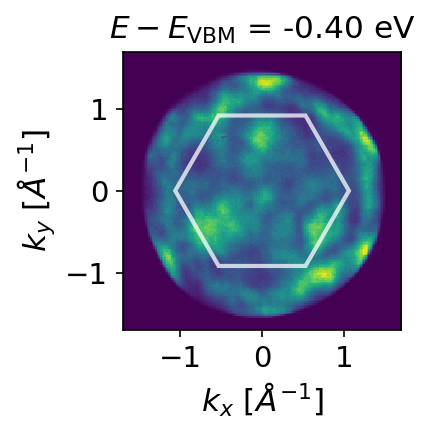

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(3,3)
fontsize = 15

mpes.plot_momentum_maps(I_res[2], E=-0.4, E_int=0.1, delays=0, delay_int=2000, fig=fig, ax=ax, fontsize=fontsize)
mpes.overlay_bz('hexagonal', a=3.95, b=3.95, ax=ax, color='white', rotation_deg=30)
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)
ax.set_title(fr'$E-E_{{\mathrm{{VBM}}}}$ = -0.40 eV', fontsize=fontsize)
#fig.savefig(fr'./Figures/Thesis/VBM_MomentumMap.pdf', bbox_inches='tight')